<a href="https://colab.research.google.com/github/SpencerLimSzeSing/mds-fyp/blob/main/notebooks/rainfall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('/content/weatherAUS.csv')

In [ ]:
import numpy as np # linear algebra
import matplotlib.pyplot as plt
import seaborn as sns
import folium #map

%matplotlib inline #ensure all plots inside the notebook cell output instead of opening a new window

import warnings
warnings.filterwarnings('ignore')

from google.colab import files #uploading/downloading files between your local computer and Google Colab

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import mutual_info_classif

UsageError: unrecognized arguments: #ensure all plots inside the notebook cell output instead of opening a new window


## Data Understanding

In [ ]:
df.shape

(145460, 23)

*  There are 23 attributes and 145460 rows of data.




In [ ]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
col_names = df.columns
col_names

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

* Here are the list of attributes in the dataset.

In [ ]:
df.info() #summary of dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

*   Categorical variables have data type object.
*   Numerical variables have data type float64.
*   There are missing values in each attribute



In [ ]:
categorical = [var for var in df.columns if df[var].dtype=='O']
numerical = [var for var in df.columns if df[var].dtype!='O']

print('Categorical variables:', categorical)
print('Numerical variables:', numerical)

Categorical variables: ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
Numerical variables: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [ ]:
df.describe() #descriptive statistics of dataset

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [ ]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}") #check for duplicate

Number of duplicate rows: 0


*   There are no duplicate data in the dataset




# EDA: Categorical Variables

In [ ]:
categorical = [var for var in df.columns if df[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :', categorical)

There are 7 categorical variables

The categorical variables are : ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [ ]:
df[categorical].head()

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,W,W,WNW,No,No
1,2008-12-02,Albury,WNW,NNW,WSW,No,No
2,2008-12-03,Albury,WSW,W,WSW,No,No
3,2008-12-04,Albury,NE,SE,E,No,No
4,2008-12-05,Albury,W,ENE,NW,No,No


*   There is a date variable, denoted by Date column.
*   There are other 6 categorical variables: Location, WindGustDir, WindDir9am, WindDir3pm, RainToday and RainTomorrow.
*   There are 2 Binary Categorical Variables:  RainToday and RainTomorrow.


In [ ]:
df[categorical].isnull().sum() # check missing values

,0
Date,0
Location,0
WindGustDir,10326
WindDir9am,10566
WindDir3pm,4228
RainToday,3261
RainTomorrow,3267


*   5 Variable with missing data: WindGustDir, WindDir9am, WindDir3pm, RainToday and RainTomorrow




HISTOGRAM

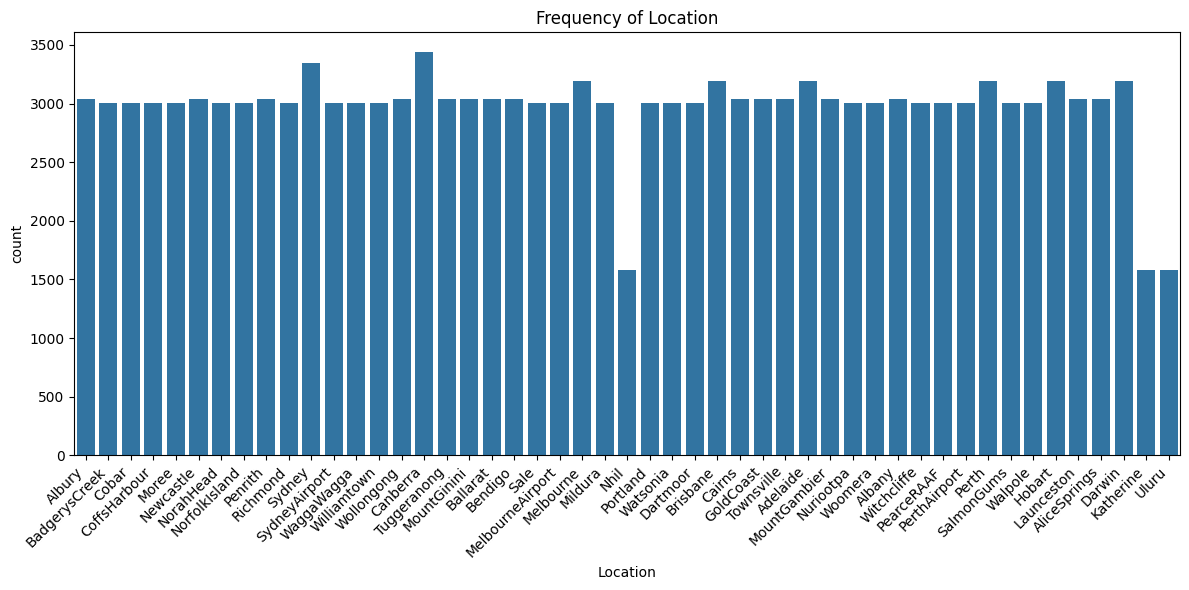

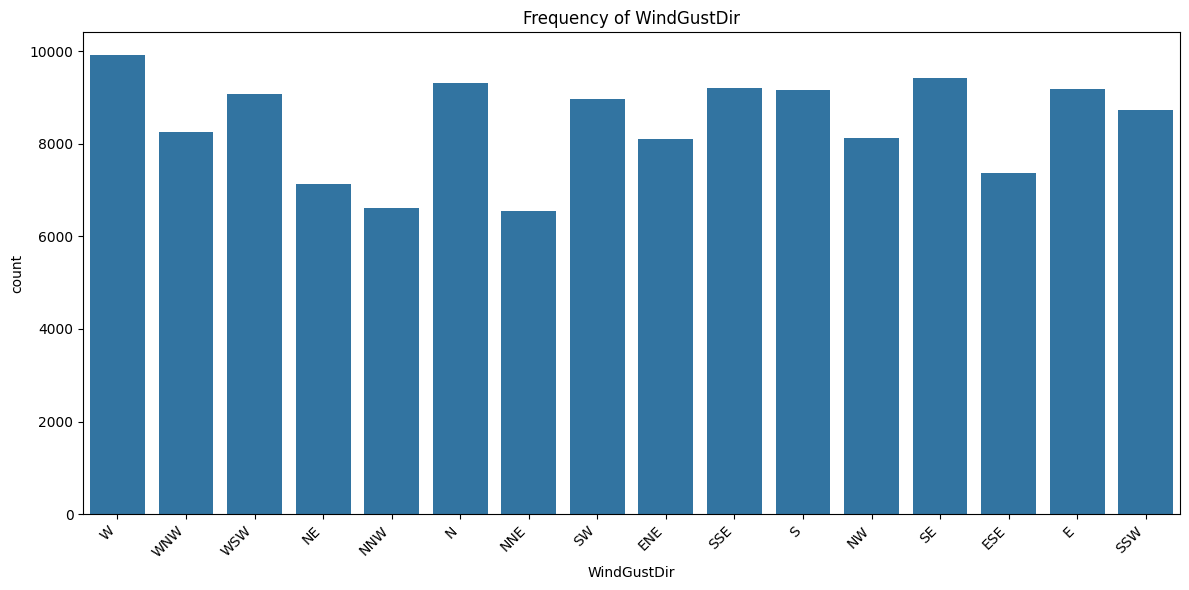

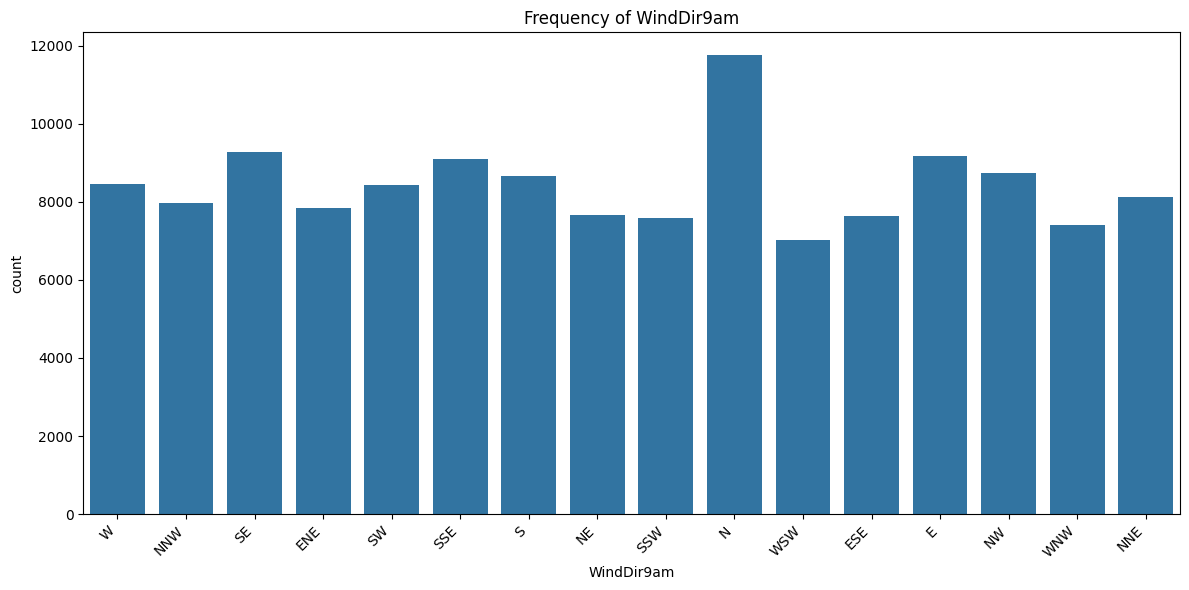

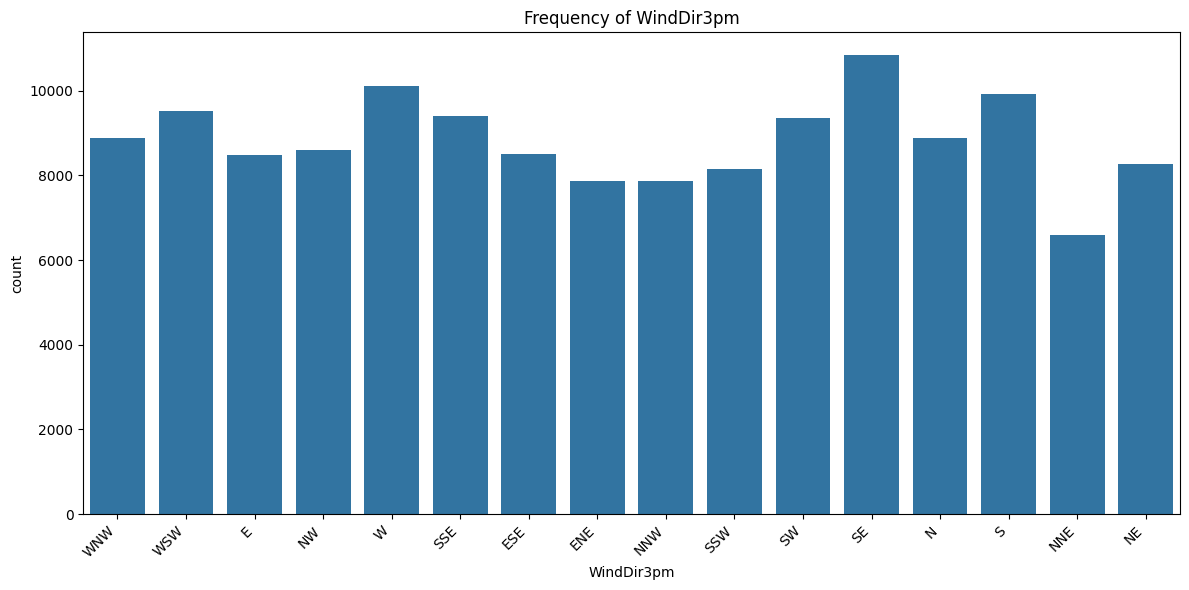

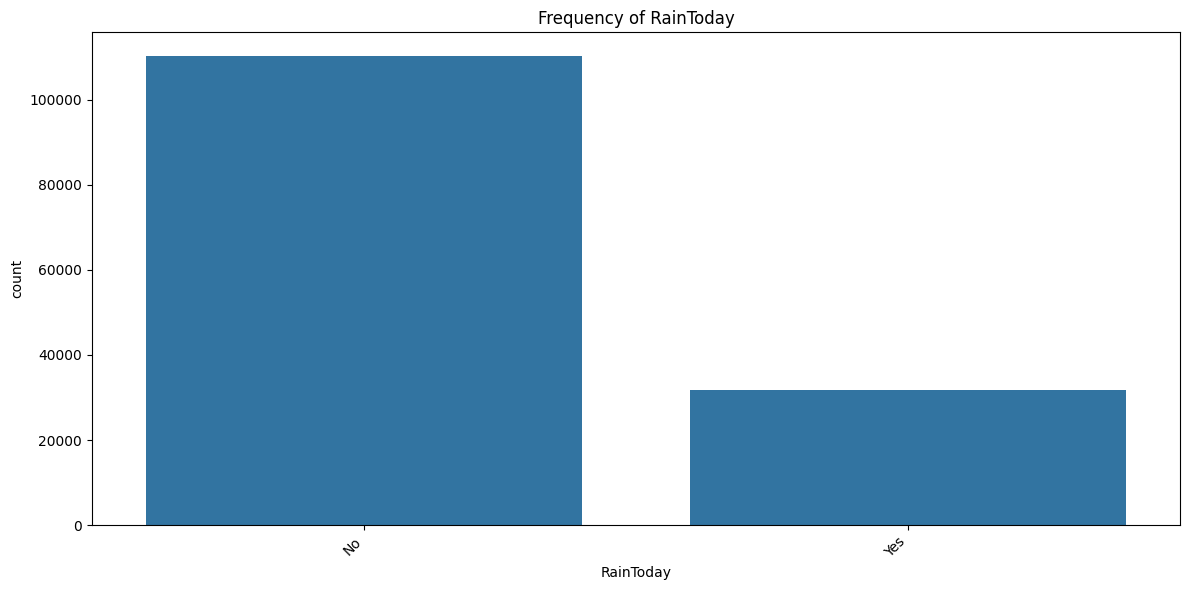

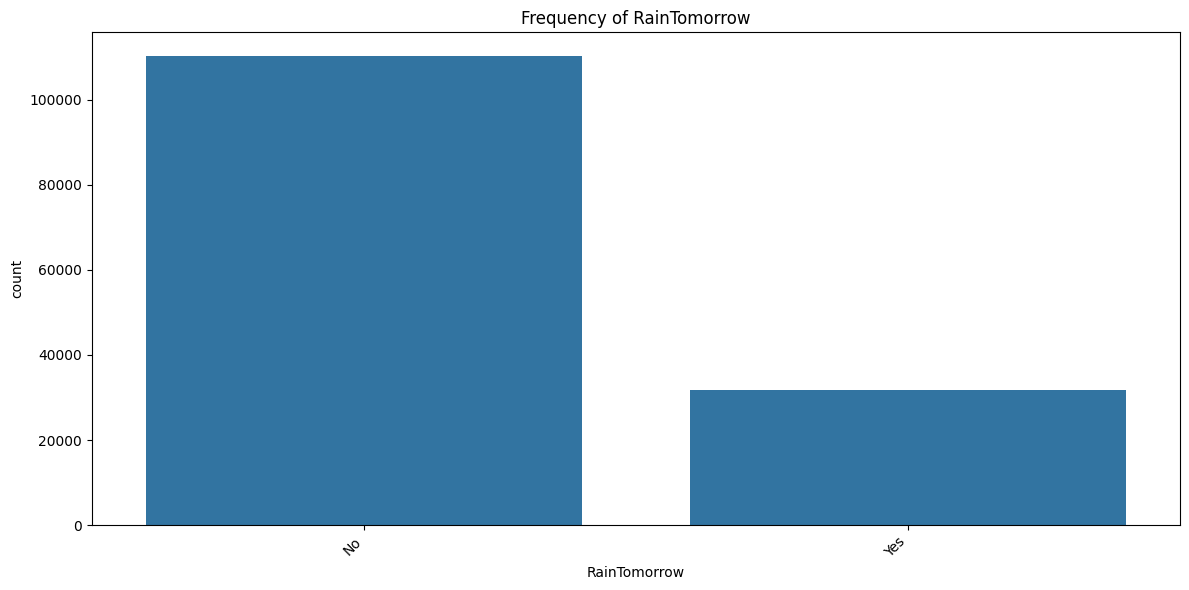

In [ ]:
# view frequency of categorical variables
# Exclude 'Date' attribute from categorical variables
categorical_no_date = [var for var in categorical if var != 'Date']

# Plot bar charts for each categorical variable except 'Date'
for var in categorical_no_date:
    plt.figure(figsize=(12, 6))  # Increase width for horizontal space
    sns.countplot(x=var, data=df)
    plt.title(f'Frequency of {var}')

    # Adjust the subplot to ensure there is space for all categories
    plt.xticks(rotation=45, ha='right')
    plt.subplots_adjust(bottom=0.2)

    # Show horizontal scroll by using a tight layout
    plt.tight_layout()
    plt.show()

In [ ]:
# view frequency of categorical variables
for var in categorical:
    print(df[var].value_counts())

Date
2013-11-12    49
2014-09-01    49
2014-08-23    49
2014-08-24    49
2014-08-25    49
              ..
2007-11-29     1
2007-11-28     1
2007-11-27     1
2007-11-26     1
2008-01-31     1
Name: count, Length: 3436, dtype: int64
Location
Canberra            3436
Sydney              3344
Darwin              3193
Melbourne           3193
Brisbane            3193
Adelaide            3193
Perth               3193
Hobart              3193
Albany              3040
MountGambier        3040
Ballarat            3040
Townsville          3040
GoldCoast           3040
Cairns              3040
Launceston          3040
AliceSprings        3040
Bendigo             3040
Albury              3040
MountGinini         3040
Wollongong          3040
Newcastle           3039
Tuggeranong         3039
Penrith             3039
Woomera             3009
Nuriootpa           3009
Cobar               3009
CoffsHarbour        3009
Moree               3009
Sale                3009
PerthAirport        3009
PearceRAA

In [ ]:
# view frequency distribution of categorical variables
for var in categorical:
    print(df[var].value_counts() / float(len(df)))

Date
2013-11-12    0.000337
2014-09-01    0.000337
2014-08-23    0.000337
2014-08-24    0.000337
2014-08-25    0.000337
                ...   
2007-11-29    0.000007
2007-11-28    0.000007
2007-11-27    0.000007
2007-11-26    0.000007
2008-01-31    0.000007
Name: count, Length: 3436, dtype: float64
Location
Canberra            0.023622
Sydney              0.022989
Darwin              0.021951
Melbourne           0.021951
Brisbane            0.021951
Adelaide            0.021951
Perth               0.021951
Hobart              0.021951
Albany              0.020899
MountGambier        0.020899
Ballarat            0.020899
Townsville          0.020899
GoldCoast           0.020899
Cairns              0.020899
Launceston          0.020899
AliceSprings        0.020899
Bendigo             0.020899
Albury              0.020899
MountGinini         0.020899
Wollongong          0.020899
Newcastle           0.020892
Tuggeranong         0.020892
Penrith             0.020892
Woomera             0.02

In [ ]:
# check for labels in categorical variables

for var in categorical:

    print(var, ' contains ', len(df[var].unique()), ' labels')

Date  contains  3436  labels
Location  contains  49  labels
WindGustDir  contains  17  labels
WindDir9am  contains  17  labels
WindDir3pm  contains  17  labels
RainToday  contains  3  labels
RainTomorrow  contains  3  labels


## Date


In [ ]:
# Convert 'Date' to datetime if not already done
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

# Find the minimum and maximum dates
start_date = df['Date'].min()
end_date = df['Date'].max()

print(f"Data starts from: {start_date}")
print(f"Data ends at: {end_date}")

# Generate the full range of dates between the start and end dates
full_date_range = pd.date_range(start=start_date, end=end_date)

# Find the missing dates by comparing with the actual dates in the dataset
missing_dates = full_date_range.difference(df['Date'])

# Display the missing dates
if len(missing_dates) > 0:
    print("Missing dates found:")
    print(missing_dates)
else:
    print("No missing dates in the range.")


Data starts from: 2007-11-01 00:00:00
Data ends at: 2017-06-25 00:00:00
Missing dates found:
DatetimeIndex(['2011-04-01', '2011-04-02', '2011-04-03', '2011-04-04',
               '2011-04-05', '2011-04-06', '2011-04-07', '2011-04-08',
               '2011-04-09', '2011-04-10', '2011-04-11', '2011-04-12',
               '2011-04-13', '2011-04-14', '2011-04-15', '2011-04-16',
               '2011-04-17', '2011-04-18', '2011-04-19', '2011-04-20',
               '2011-04-21', '2011-04-22', '2011-04-23', '2011-04-24',
               '2011-04-25', '2011-04-26', '2011-04-27', '2011-04-28',
               '2011-04-29', '2011-04-30', '2012-12-01', '2012-12-02',
               '2012-12-03', '2012-12-04', '2012-12-05', '2012-12-06',
               '2012-12-07', '2012-12-08', '2012-12-09', '2012-12-10',
               '2012-12-11', '2012-12-12', '2012-12-13', '2012-12-14',
               '2012-12-15', '2012-12-16', '2012-12-17', '2012-12-18',
               '2012-12-19', '2012-12-20', '2012-12-21'


*   'Date' of the dataset start from 2007-11-01 until 2017-06-25
*   Missing dates in the range are April 2011, December 2012, February 2013



In [ ]:
# check if date is in the correct format yyyy-mm-dd
def check_date_format(date_str):
    try:
        pd.to_datetime(date_str, format='%Y-%m-%d', errors='raise')
        return True
    except ValueError:
        return False

# Apply the function to each row in the 'Date' column and find rows with invalid formats
df['is_valid_date'] = df['Date'].apply(check_date_format)

# Filter rows with invalid dates
invalid_dates = df[~df['is_valid_date']]

# Output invalid dates
print("Invalid Dates:")
print(invalid_dates)

Invalid Dates:
Empty DataFrame
Columns: [Date, Location, MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustDir, WindGustSpeed, WindDir9am, WindDir3pm, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, RainToday, RainTomorrow, is_valid_date]
Index: []

[0 rows x 24 columns]



*   There are no invalid dates in the dataset

In [ ]:
# Group by 'Location' and check the date range (min and max dates)
date_range_by_location = df.groupby('Location')['Date'].agg(['min', 'max']).reset_index()

# Print the date range for each location
print(date_range_by_location)


            Location        min        max
0           Adelaide 2008-07-01 2017-06-25
1             Albany 2008-12-01 2017-06-25
2             Albury 2008-12-01 2017-06-25
3       AliceSprings 2008-12-01 2017-06-25
4      BadgerysCreek 2009-01-01 2017-06-25
5           Ballarat 2008-12-01 2017-06-25
6            Bendigo 2008-12-01 2017-06-25
7           Brisbane 2008-07-01 2017-06-25
8             Cairns 2008-12-01 2017-06-25
9           Canberra 2007-11-01 2017-06-25
10             Cobar 2009-01-01 2017-06-25
11      CoffsHarbour 2009-01-01 2017-06-25
12          Dartmoor 2009-01-01 2017-06-25
13            Darwin 2008-07-01 2017-06-25
14         GoldCoast 2008-12-01 2017-06-25
15            Hobart 2008-07-01 2017-06-25
16         Katherine 2013-03-01 2017-06-25
17        Launceston 2008-12-01 2017-06-25
18         Melbourne 2008-07-01 2017-06-25
19  MelbourneAirport 2009-01-01 2017-06-25
20           Mildura 2009-01-01 2017-06-25
21             Moree 2009-01-01 2017-06-25
22      Mou


*   There are ony 3 location (Katherine, Nhil, Uluru) with relatively short period of data (4years)

**Separate Date column into 3 column: Year, Month , Day**

In [ ]:
# parse the dates, currently coded as strings, into datetime format

df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# extract year from date

df['Year'] = df['Date'].dt.year

df['Year'].head()

,Year
0,2008
1,2008
2,2008
3,2008
4,2008


In [ ]:
# extract month from date

df['Month'] = df['Date'].dt.month

df['Month'].head()

,Month
0,12
1,12
2,12
3,12
4,12


In [ ]:
# extract day from date

df['Day'] = df['Date'].dt.day

df['Day'].head()

,Day
0,1
1,2
2,3
3,4
4,5


In [ ]:
# the summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  object        
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   Evaporation    82670 non-null   float64       
 6   Sunshine       75625 non-null   float64       
 7   WindGustDir    135134 non-null  object        
 8   WindGustSpeed  135197 non-null  float64       
 9   WindDir9am     134894 non-null  object        
 10  WindDir3pm     141232 non-null  object        
 11  WindSpeed9am   143693 non-null  float64       
 12  WindSpeed3pm   142398 non-null  float64       
 13  Humidity9am    142806 non-null  float64       
 14  Humidity3pm    140953 non-null  float64       
 15  

In [ ]:
# Check for any rows where 'is_valid_date' is False
invalid_dates = df[df['is_valid_date'] == False]
# Display the rows with invalid dates
print(invalid_dates)


Empty DataFrame
Columns: [Date, Location, MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustDir, WindGustSpeed, WindDir9am, WindDir3pm, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, RainToday, RainTomorrow, is_valid_date, Year, Month, Day]
Index: []

[0 rows x 27 columns]


In [ ]:
# Dropping 'is_valid_date' column from the dataframe
df.drop('is_valid_date', axis=1, inplace=True)

In [ ]:
# drop the original Date variable
df.drop('Date', axis=1, inplace = True)

In [ ]:
# preview the dataset
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,1007.1,8.0,NaN,16.9,21.8,No,No,2008,12,1
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,1007.8,NaN,NaN,17.2,24.3,No,No,2008,12,2
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,1008.7,NaN,2.0,21.0,23.2,No,No,2008,12,3
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,1012.8,NaN,NaN,18.1,26.5,No,No,2008,12,4
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12,5


## Location

In [ ]:
# print number of labels in Location variable
print('Location contains', len(df.Location.unique()), 'labels')

Location contains 49 labels


In [ ]:
# check labels in location variable
df.Location.unique()

array(['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree',
       'Newcastle', 'NorahHead', 'NorfolkIsland', 'Penrith', 'Richmond',
       'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown',
       'Wollongong', 'Canberra', 'Tuggeranong', 'MountGinini', 'Ballarat',
       'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura',
       'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane', 'Cairns',
       'GoldCoast', 'Townsville', 'Adelaide', 'MountGambier', 'Nuriootpa',
       'Woomera', 'Albany', 'Witchcliffe', 'PearceRAAF', 'PerthAirport',
       'Perth', 'SalmonGums', 'Walpole', 'Hobart', 'Launceston',
       'AliceSprings', 'Darwin', 'Katherine', 'Uluru'], dtype=object)

In [ ]:
# check frequency distribution of values in Location variable
df.Location.value_counts()

,count
Location,
Canberra,3436
Sydney,3344
Darwin,3193
Melbourne,3193
Brisbane,3193
Adelaide,3193
Perth,3193
Hobart,3193
Albany,3040


In [ ]:
# locations with their corresponding latitudes and longitudes.
location_coords = {
    'Albury': (-36.0737, 146.9135),
    'BadgerysCreek': (-33.9209, 150.7253),
    'Cobar': (-31.4980, 145.8383),
    'CoffsHarbour': (-30.2963, 153.1141),
    'Moree': (-29.4632, 149.8419),
    'Newcastle': (-32.9267, 151.7789),
    'NorahHead': (-33.2820, 151.5703),
    'NorfolkIsland': (-29.0333, 167.9500),
    'Penrith': (-33.7516, 150.6958),
    'Richmond': (-33.6000, 150.7500),
    'Sydney': (-33.8688, 151.2093),
    'SydneyAirport': (-33.9399, 151.1753),
    'WaggaWagga': (-35.1175, 147.3671),
    'Williamtown': (-32.7924, 151.8345),
    'Wollongong': (-34.4278, 150.8931),
    'Canberra': (-35.2809, 149.1300),
    'Tuggeranong': (-35.4245, 149.0664),
    'MountGinini': (-35.5292, 148.7750),
    'Ballarat': (-37.5622, 143.8503),
    'Bendigo': (-36.7587, 144.2802),
    'Sale': (-38.1067, 147.0680),
    'MelbourneAirport': (-37.6690, 144.8410),
    'Melbourne': (-37.8136, 144.9631),
    'Mildura': (-34.2049, 142.1376),
    'Nhil': (-36.3313, 141.6547),
    'Portland': (-38.3420, 141.6040),
    'Watsonia': (-37.7169, 145.0842),
    'Dartmoor': (-37.9181, 141.2836),
    'Brisbane': (-27.4698, 153.0251),
    'Cairns': (-16.9186, 145.7781),
    'GoldCoast': (-28.0167, 153.4000),
    'Townsville': (-19.2580, 146.8183),
    'Adelaide': (-34.9285, 138.6007),
    'MountGambier': (-37.8297, 140.7822),
    'Nuriootpa': (-34.4685, 138.9964),
    'Woomera': (-31.1501, 136.8255),
    'Albany': (-35.0270, 117.8847),
    'Witchcliffe': (-34.0185, 115.1013),
    'PearceRAAF': (-31.6674, 116.0148),
    'PerthAirport': (-31.9403, 115.9677),
    'Perth': (-31.9505, 115.8605),
    'SalmonGums': (-32.9833, 121.6333),
    'Walpole': (-34.9762, 116.7333),
    'Hobart': (-42.8821, 147.3272),
    'Launceston': (-41.4332, 147.1441),
    'AliceSprings': (-23.6980, 133.8807),
    'Darwin': (-12.4634, 130.8456),
    'Katherine': (-14.4611, 132.2648),
    'Uluru': (-25.3444, 131.0369)
}

# Create a map
m = folium.Map(location=[-25.2744, 133.7751], zoom_start=5)

# Add markers for each location
for location, coord in location_coords.items():
    folium.Marker(location=coord, popup=location).add_to(m)


In [ ]:
# Save the map to an HTML file
#m.save("locations_map.html")

# Download the map file
#files.download("locations_map.html")

In [ ]:
#  One Hot Encoding of Location variable
# get k-1 dummy variables after One Hot Encoding

#pd.get_dummies(df.Location, drop_first=True).head()

## WindGustDir

In [ ]:
# print number of labels in WindGustDir variable
print('WindGustDir contains', len(df['WindGustDir'].unique()), 'labels')

WindGustDir contains 17 labels


In [ ]:
# check labels in WindGustDir variable
df['WindGustDir'].unique()

array(['W', 'WNW', 'WSW', 'NE', 'NNW', 'N', 'NNE', 'SW', nan, 'ENE',
       'SSE', 'S', 'NW', 'SE', 'ESE', 'E', 'SSW'], dtype=object)

In [ ]:
# check frequency distribution of values in WindGustDir variable
df.WindGustDir.value_counts()

,count
WindGustDir,
W,9915
SE,9418
N,9313
SSE,9216
E,9181
S,9168
WSW,9069
SW,8967
SSW,8736


In [ ]:
#  One Hot Encoding of WindGustDir variable
# get k-1 dummy variables after One Hot Encoding
# add an additional dummy variable to indicate there was missing data
pd.get_dummies(df.WindGustDir, drop_first=True, dummy_na=True).head()

,ENE,ESE,N,NE,NNE,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW,NaN
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [ ]:
# sum the number of 1s per boolean variable over the rows of the dataset
#check how many observations for each category

pd.get_dummies(df.WindGustDir, drop_first=True, dummy_na=True).sum(axis=0)

,0
ENE,8104
ESE,7372
N,9313
NE,7133
NNE,6548
NNW,6620
NW,8122
S,9168
SE,9418
SSE,9216


## WindDir9am

In [ ]:
# print number of labels in WindDir9am variable
print('WindDir9am contains', len(df['WindDir9am'].unique()), 'labels')

WindDir9am contains 17 labels


In [ ]:
# check labels in WindDir9am variable

df['WindDir9am'].unique()

array(['W', 'NNW', 'SE', 'ENE', 'SW', 'SSE', 'S', 'NE', nan, 'SSW', 'N',
       'WSW', 'ESE', 'E', 'NW', 'WNW', 'NNE'], dtype=object)

In [ ]:
# check frequency distribution of values in WindDir9am variable

df['WindDir9am'].value_counts()

,count
WindDir9am,
N,11758
SE,9287
E,9176
SSE,9112
NW,8749
S,8659
W,8459
SW,8423
NNE,8129


In [ ]:
#  One Hot Encoding of WindDir9am variable
# get k-1 dummy variables after One Hot Encoding
# also add an additional dummy variable to indicate there was missing data
pd.get_dummies(df.WindDir9am, drop_first=True, dummy_na=True).head()

,ENE,ESE,N,NE,NNE,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW,NaN
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# sum the number of 1s per boolean variable over the rows of the dataset
# how many observations for each category

pd.get_dummies(df.WindDir9am, drop_first=True, dummy_na=True).sum(axis=0)

,0
ENE,7836
ESE,7630
N,11758
NE,7671
NNE,8129
NNW,7980
NW,8749
S,8659
SE,9287
SSE,9112


## WindDir3pm

In [ ]:
# print number of labels in WindDir3pm variable
print('WindDir3pm contains', len(df['WindDir3pm'].unique()), 'labels')

WindDir3pm contains 17 labels


In [ ]:
# check labels in WindDir3pm variable

df['WindDir3pm'].unique()

array(['WNW', 'WSW', 'E', 'NW', 'W', 'SSE', 'ESE', 'ENE', 'NNW', 'SSW',
       'SW', 'SE', 'N', 'S', 'NNE', nan, 'NE'], dtype=object)

In [ ]:
# check frequency distribution of values in WindDir3pm variable

df['WindDir3pm'].value_counts()

,count
WindDir3pm,
SE,10838
W,10110
S,9926
WSW,9518
SSE,9399
SW,9354
N,8890
WNW,8874
NW,8610


In [ ]:
#  One Hot Encoding of WindDir3pm variable
# get k-1 dummy variables after One Hot Encoding
# also add an additional dummy variable to indicate there was missing data
pd.get_dummies(df.WindDir3pm, drop_first=True, dummy_na=True).head()

,ENE,ESE,N,NE,NNE,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW,NaN
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [ ]:
# sum the number of 1s per boolean variable over the rows of the dataset
# it will tell us how many observations we have for each category

pd.get_dummies(df.WindDir3pm, drop_first=True, dummy_na=True).sum(axis=0)

,0
ENE,7857
ESE,8505
N,8890
NE,8263
NNE,6590
NNW,7870
NW,8610
S,9926
SE,10838
SSE,9399


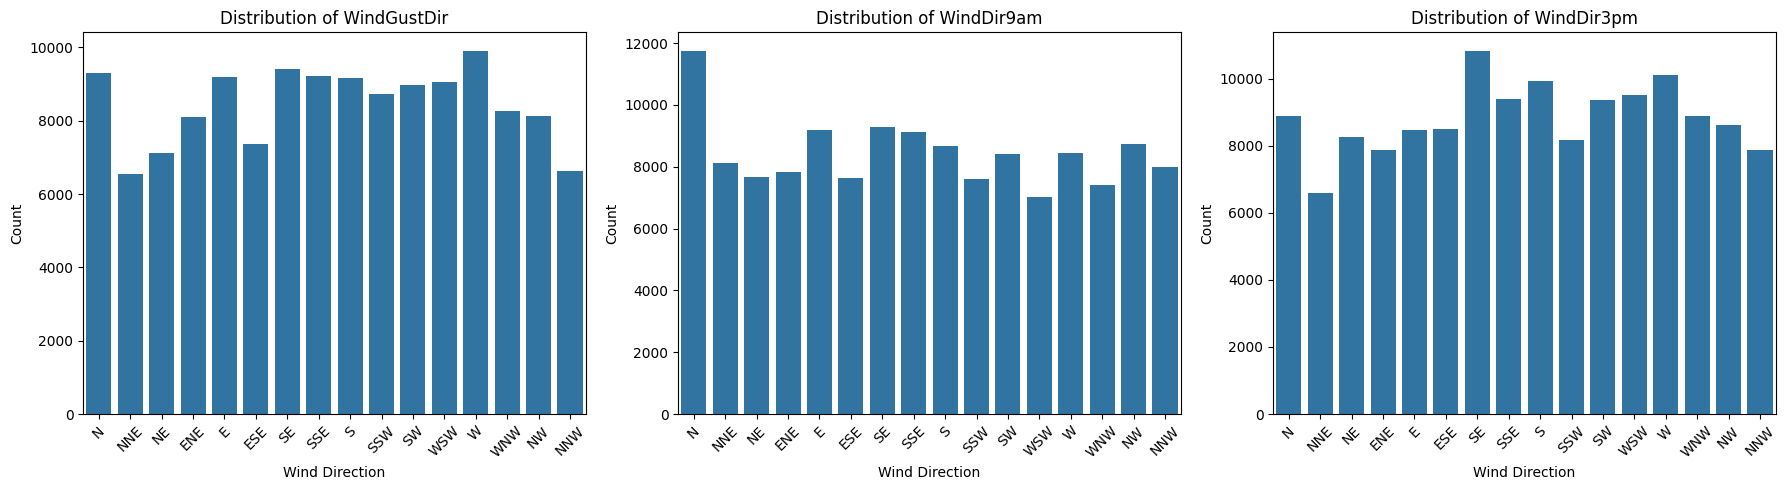

In [ ]:
# Define the custom order for wind directions
wind_order = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
              'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']

# Create a figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Count plot for WindGustDir
sns.countplot(data=df, x='WindGustDir', ax=axes[0], order=wind_order)
axes[0].set_title('Distribution of WindGustDir')
axes[0].set_xlabel('Wind Direction')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Count plot for WindDir9am
sns.countplot(data=df, x='WindDir9am', ax=axes[1], order=wind_order)
axes[1].set_title('Distribution of WindDir9am')
axes[1].set_xlabel('Wind Direction')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Count plot for WindDir3pm
sns.countplot(data=df, x='WindDir3pm', ax=axes[2], order=wind_order)
axes[2].set_title('Distribution of WindDir3pm')
axes[2].set_xlabel('Wind Direction')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


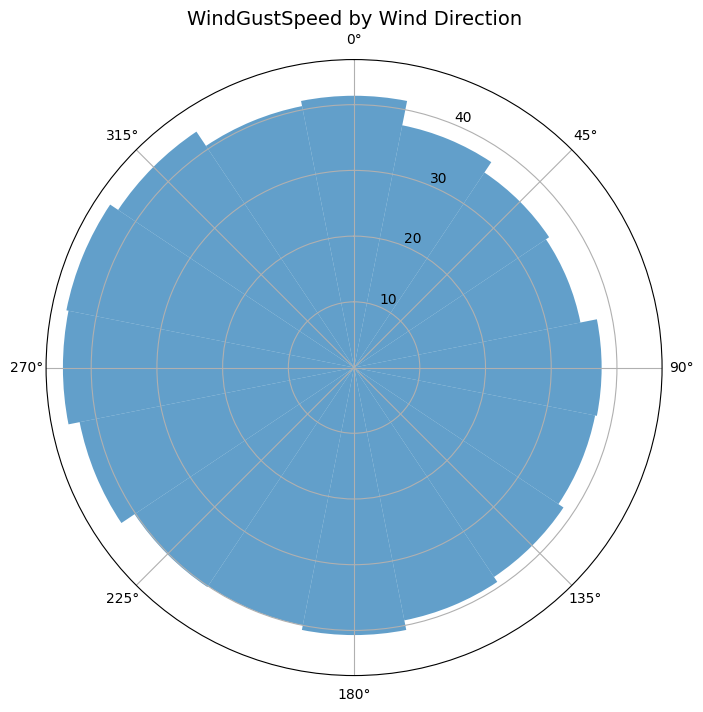

In [ ]:
# Define a function to map wind direction to angles
def wind_direction_to_angle(direction):
    mapping = {'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5,
               'SE': 135, 'SSE': 157.5, 'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
               'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5}
    return direction.map(mapping)

# Convert WindGustDir to angles
df['WindGustDir_Angle'] = wind_direction_to_angle(df['WindGustDir'])

# Create a polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Group by direction and average speed
wind_data = df.groupby('WindGustDir_Angle')['WindGustSpeed'].mean().dropna()

# Plot
bars = ax.bar(np.deg2rad(wind_data.index), wind_data.values, width=np.deg2rad(22.5), alpha=0.7)
plt.title('WindGustSpeed by Wind Direction', fontsize=14)
plt.show()


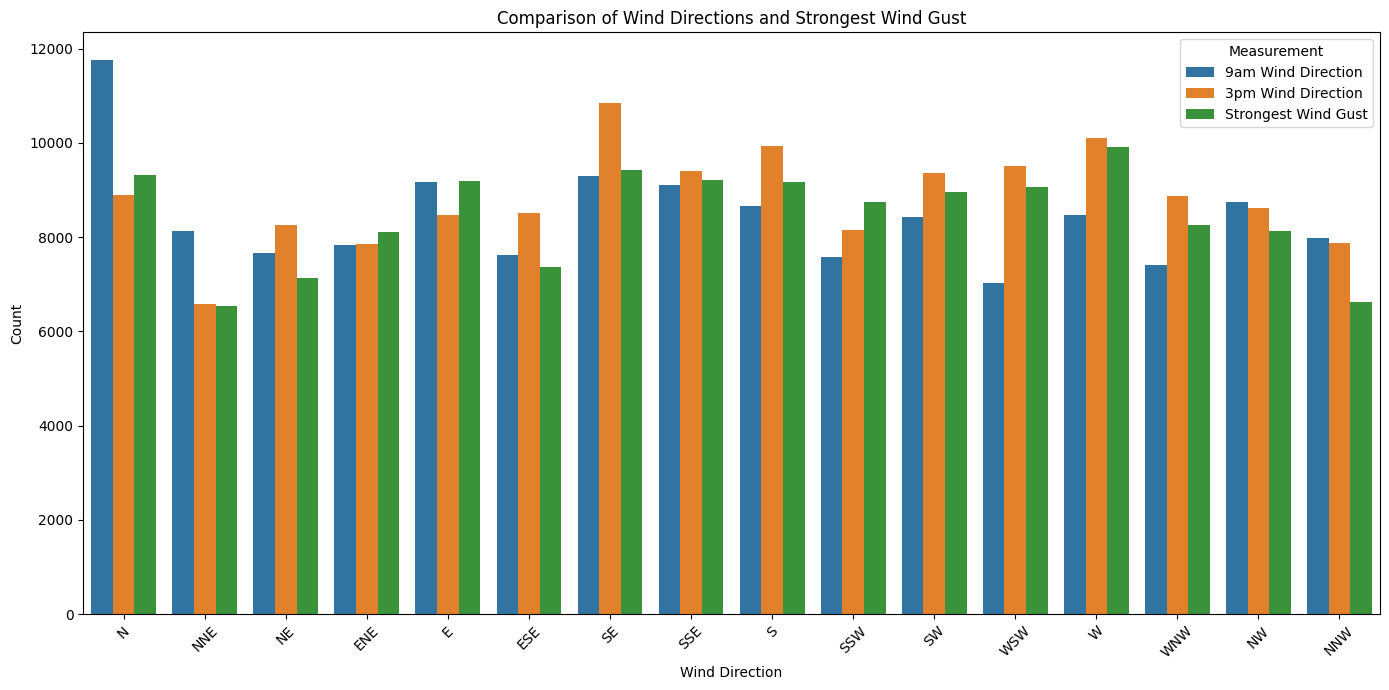

In [ ]:
wind_order = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
              'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']

# Combine into a single DataFrame
wind_dir_comparison = df[['WindDir9am', 'WindDir3pm', 'WindGustDir']].melt(
    var_name='Time', value_name='Direction')

wind_dir_comparison['Time'] = wind_dir_comparison['Time'].replace({
    'WindDir9am': '9am Wind Direction',
    'WindDir3pm': '3pm Wind Direction',
    'WindGustDir': 'Strongest Wind Gust'
})

plt.figure(figsize=(14, 7))
sns.countplot(data=wind_dir_comparison, x='Direction', hue='Time', order=wind_order)
plt.title('Comparison of Wind Directions and Strongest Wind Gust')
plt.xlabel('Wind Direction')
plt.ylabel('Count')
plt.legend(title='Measurement')
plt.xticks(rotation=45)  # Rotate x-axis labels
plt.tight_layout()
plt.show()


## RainToday

In [ ]:
# print number of labels in RainToday variable

print('RainToday contains', len(df['RainToday'].unique()), 'labels')

RainToday contains 3 labels


In [ ]:
# check labels in WindGustDir variable

df['RainToday'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
# check frequency distribution of values in WindGustDir variable

df.RainToday.value_counts()

,count
RainToday,
No,110319
Yes,31880


In [ ]:
# let's do One Hot Encoding of RainToday variable
# get k-1 dummy variables after One Hot Encoding
# also add an additional dummy variable to indicate there was missing data
pd.get_dummies(df.RainToday, drop_first=True, dummy_na=True).head()

,Yes,NaN
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False


In [ ]:
# sum the number of 1s per boolean variable over the rows of the dataset
# it will tell us how many observations we have for each category

pd.get_dummies(df.RainToday, drop_first=True, dummy_na=True).sum(axis=0)

,0
Yes,31880
NaN,3261


## RainTomorrow

In [ ]:
df['RainTomorrow'].isnull().sum() #check missing value

3267

In [ ]:
df['RainTomorrow'].nunique() #View number of unique values

2

In [ ]:
df['RainTomorrow'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
df['RainTomorrow'].value_counts()

,count
RainTomorrow,
No,110316
Yes,31877


In [ ]:
df['RainTomorrow'].value_counts()/len(df) #View percentage of frequency distribution of values

,count
RainTomorrow,
No,0.758394
Yes,0.219146


We can see that out of the total number of RainTomorrow values, No appears 77.58% times and Yes appears 22.42% times.

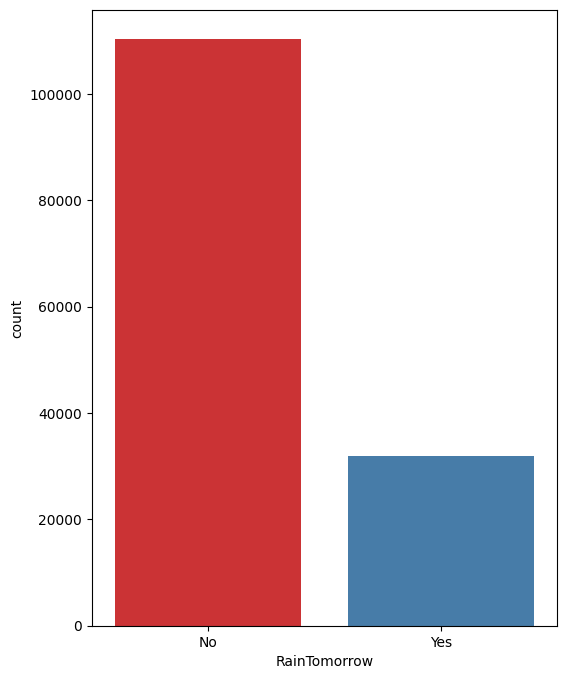

In [ ]:
f, ax = plt.subplots(figsize=(6, 8))
ax = sns.countplot(x="RainTomorrow", data=df, palette="Set1")
plt.show()

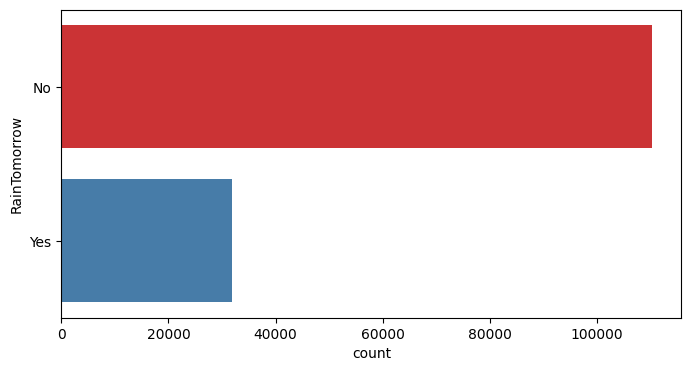

In [ ]:
f, ax = plt.subplots(figsize=(8, 4))
ax = sns.countplot(y="RainTomorrow", data=df, palette="Set1")
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Location           145460 non-null  object 
 1   MinTemp            143975 non-null  float64
 2   MaxTemp            144199 non-null  float64
 3   Rainfall           142199 non-null  float64
 4   Evaporation        82670 non-null   float64
 5   Sunshine           75625 non-null   float64
 6   WindGustDir        135134 non-null  object 
 7   WindGustSpeed      135197 non-null  float64
 8   WindDir9am         134894 non-null  object 
 9   WindDir3pm         141232 non-null  object 
 10  WindSpeed9am       143693 non-null  float64
 11  WindSpeed3pm       142398 non-null  float64
 12  Humidity9am        142806 non-null  float64
 13  Humidity3pm        140953 non-null  float64
 14  Pressure9am        130395 non-null  float64
 15  Pressure3pm        130432 non-null  float64
 16  Cl

# EDA: Numerical Variables

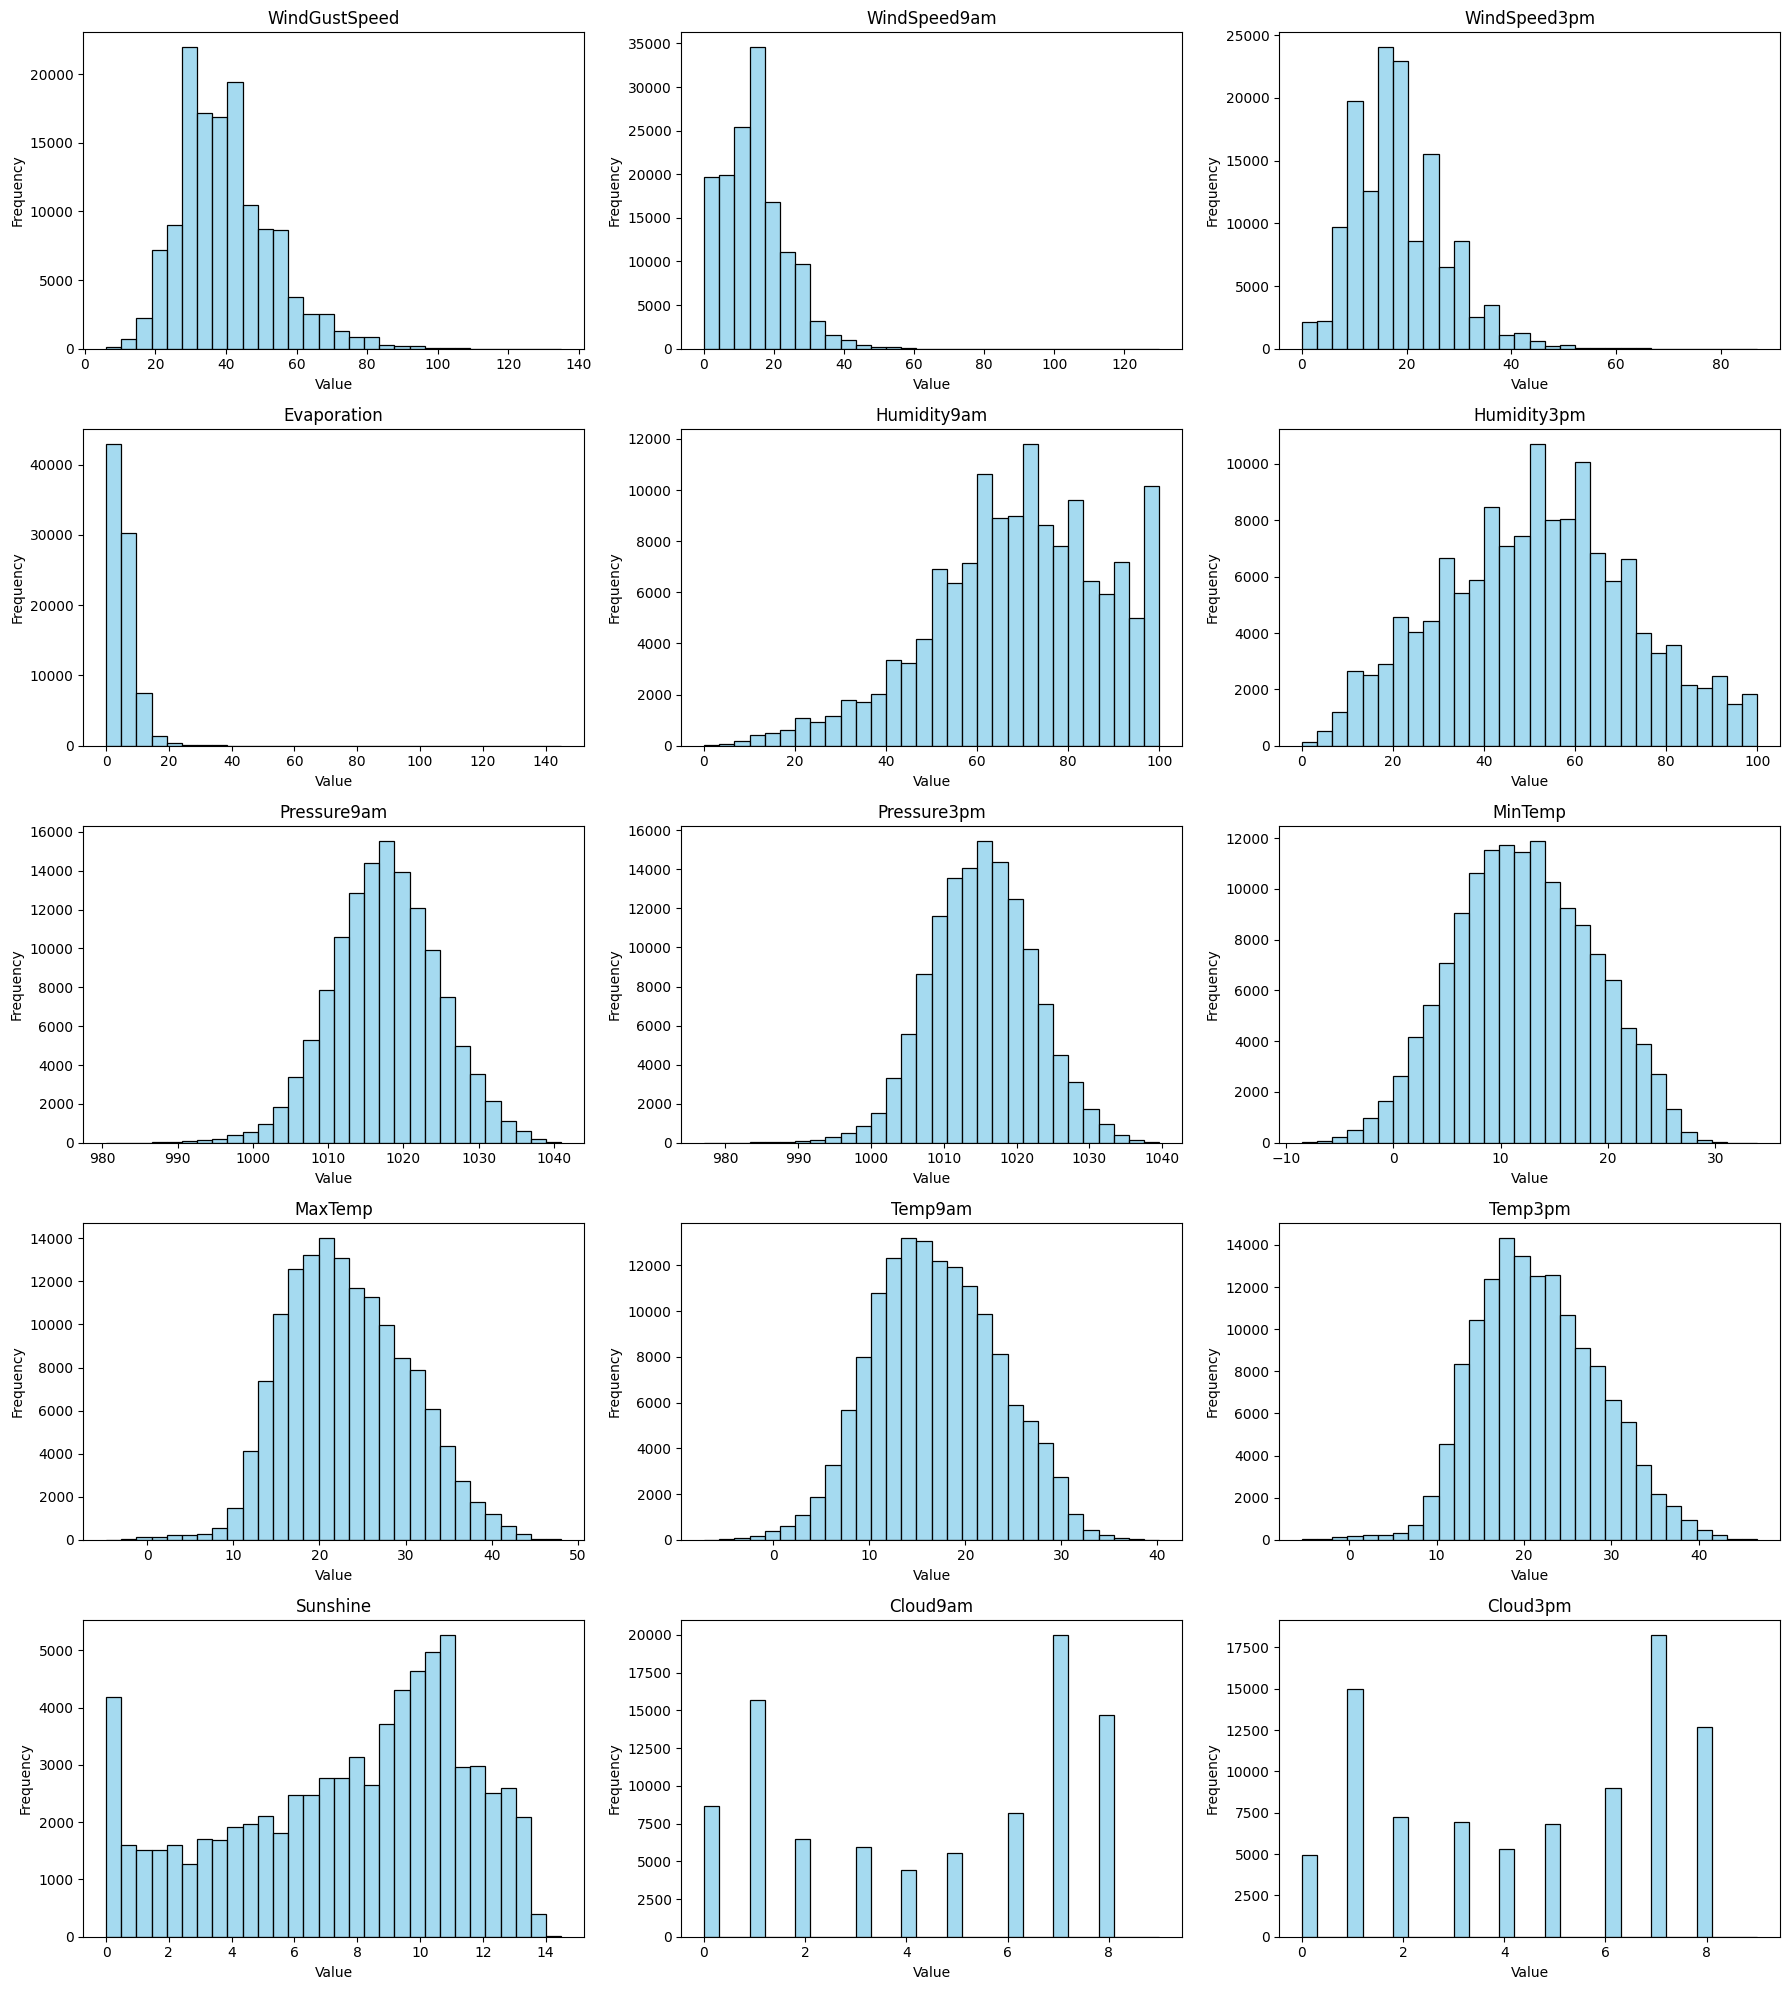

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of features to visualize
features = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Evaporation',
            'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
            'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 'Sunshine', 'Cloud9am', 'Cloud3pm']

# Set up the figure layout
fig, axes = plt.subplots(5, 3, figsize=(18, 20))  # Adjust rows for the new features
axes = axes.flatten()  # Flatten axes for easier indexing

# Plot histograms for each feature
for i, feature in enumerate(features):
    sns.histplot(data=df, x=feature, bins=30, kde=False, color="skyblue", ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Remove any empty subplots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
# find numerical variables

numerical = [var for var in df.columns if df[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)

There are 20 numerical variables

The numerical variables are : ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Year', 'Month', 'Day', 'WindGustDir_Angle']


In [ ]:
# view the numerical variables

df[numerical].head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Year,Month,Day,WindGustDir_Angle
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,2008,12,1,270.0
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,2008,12,2,292.5
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,2008,12,3,247.5
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,2008,12,4,45.0
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,2008,12,5,270.0


Summary of numerical variables
*   There are 16 numerical variables.
*    MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am and Temp3pm.
*   All of the numerical variables are of continuous type.


## Missing


In [ ]:
# check missing values in numerical variables

df[numerical].isnull().sum()

,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustSpeed,10263
WindSpeed9am,1767
WindSpeed3pm,3062
Humidity9am,2654
Humidity3pm,4507


In [ ]:

# Calculate the percentage of missing values for each numerical variable
missing_percentage_num = (df[numerical].isnull().sum() / len(df)) * 100

# Print the results
print(missing_percentage_num)

MinTemp               1.020899
MaxTemp               0.866905
Rainfall              2.241853
Evaporation          43.166506
Sunshine             48.009762
WindGustSpeed         7.055548
WindSpeed9am          1.214767
WindSpeed3pm          2.105046
Humidity9am           1.824557
Humidity3pm           3.098446
Pressure9am          10.356799
Pressure3pm          10.331363
Cloud9am             38.421559
Cloud3pm             40.807095
Temp9am               1.214767
Temp3pm               2.481094
Year                  0.000000
Month                 0.000000
Day                   0.000000
WindGustDir_Angle     7.098859
dtype: float64


*   Numerical Variable with >5% missing data
  1.   Evaporation
  2.   Sunshine
  3.   Cloud9am
  4.   Cloud3pm
  5.   Pressure9am
  6.   Pressure3pm

In [ ]:
# view summary statistics in numerical variables

print(round(df[numerical].describe()),2)

        MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
count  143975.0  144199.0  142199.0      82670.0   75625.0       135197.0   
mean       12.0      23.0       2.0          5.0       8.0           40.0   
std         6.0       7.0       8.0          4.0       4.0           14.0   
min        -8.0      -5.0       0.0          0.0       0.0            6.0   
25%         8.0      18.0       0.0          3.0       5.0           31.0   
50%        12.0      23.0       0.0          5.0       8.0           39.0   
75%        17.0      28.0       1.0          7.0      11.0           48.0   
max        34.0      48.0     371.0        145.0      14.0          135.0   

       WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  \
count      143693.0      142398.0     142806.0     140953.0     130395.0   
mean           14.0          19.0         69.0         52.0       1018.0   
std             9.0           9.0         19.0         21.0          7.0   
mi

## Outliers

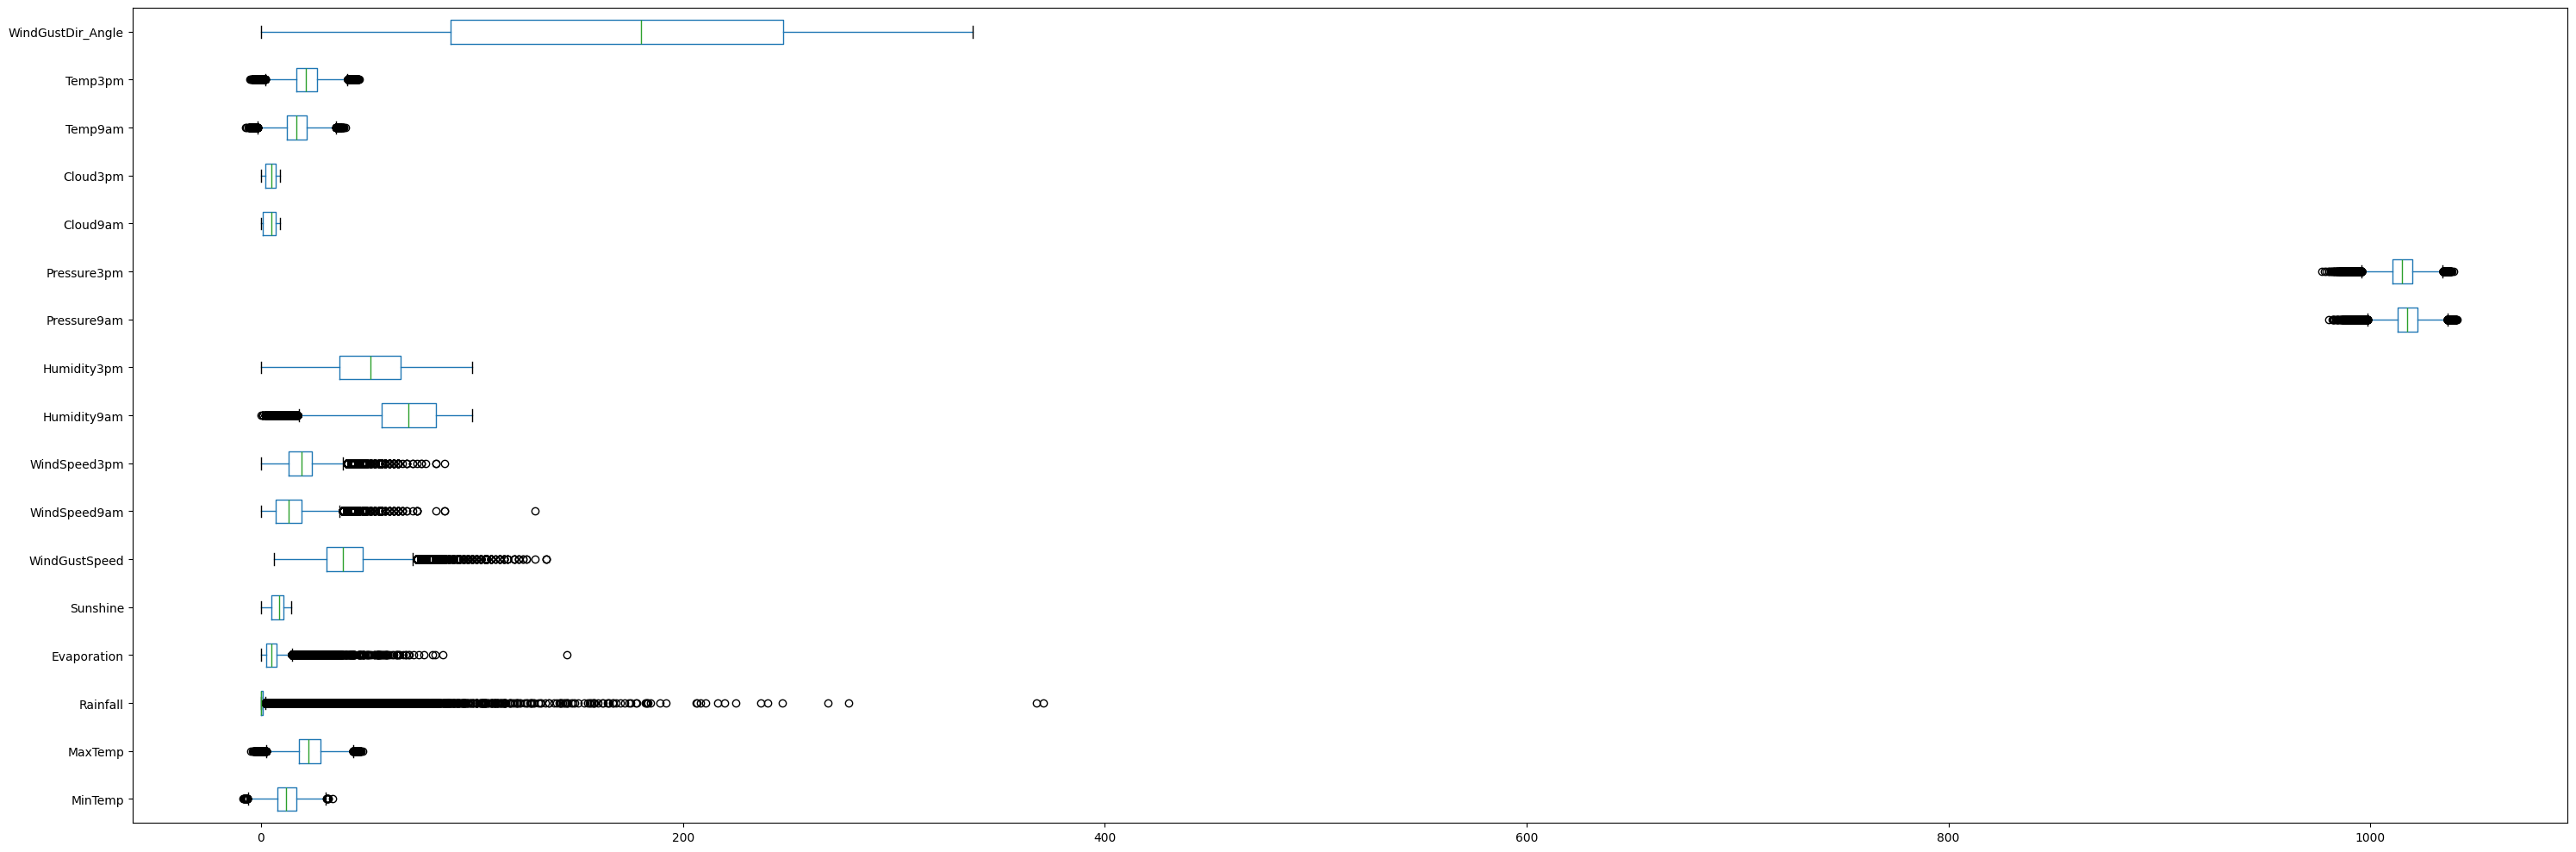

In [ ]:
import matplotlib.pyplot as plt

# Select only numerical columns
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Set up the figure size with enough width for horizontal scrolling
plt.figure(figsize=(30, 10))  # Adjust the figure size to fit all plots in one row

# Plot boxplots for all numerical columns in a single row
df.boxplot(column=numerical_columns, grid=False, vert=False)  # 'vert=False' makes horizontal boxplots

# Adjust the layout to avoid overlapping of labels
plt.tight_layout()

# Display the plot
plt.show()


the Rainfall, Evaporation, Humidity9am, WindGustSpeed, WindSpeed9am and WindSpeed3pm columns may contain outliers.

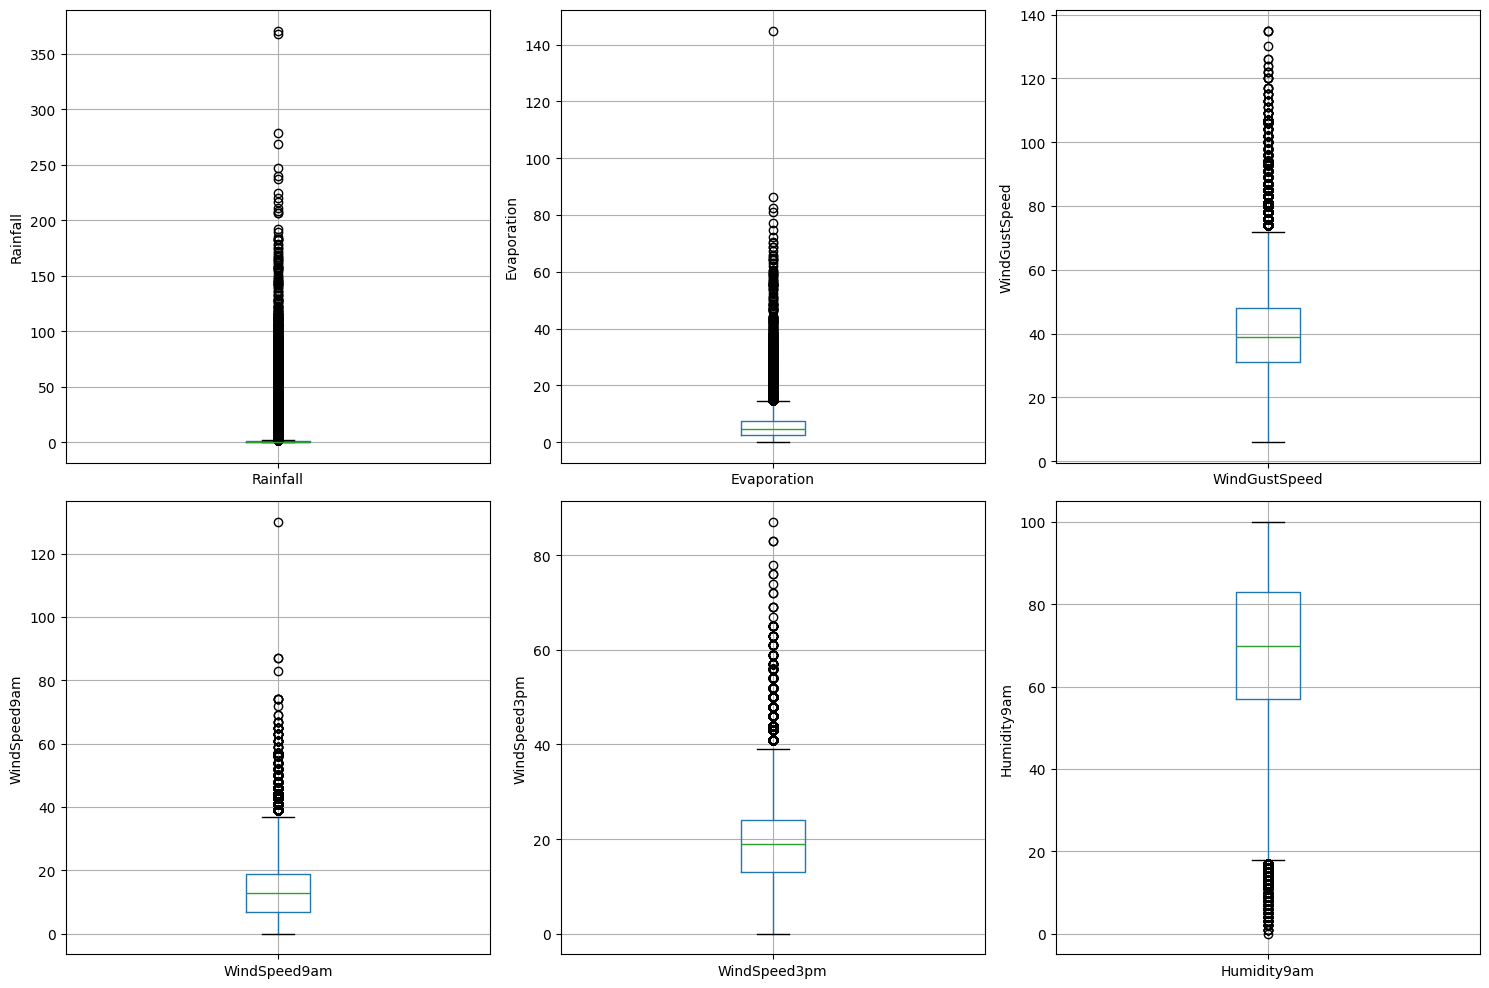

In [ ]:
plt.figure(figsize=(15,10))

# Plot for Rainfall
plt.subplot(2, 3, 1)  # Adjusted to a 2x3 grid for better spacing
fig = df.boxplot(column='Rainfall')
fig.set_title('')
fig.set_ylabel('Rainfall')

# Plot for Evaporation
plt.subplot(2, 3, 2)
fig = df.boxplot(column='Evaporation')
fig.set_title('')
fig.set_ylabel('Evaporation')

# Plot for WindGustSpeed
plt.subplot(2, 3, 3)
fig = df.boxplot(column='WindGustSpeed')
fig.set_title('')
fig.set_ylabel('WindGustSpeed')

# Plot for WindSpeed9am
plt.subplot(2, 3, 4)
fig = df.boxplot(column='WindSpeed9am')
fig.set_title('')
fig.set_ylabel('WindSpeed9am')

# Plot for WindSpeed3pm
plt.subplot(2, 3, 5)
fig = df.boxplot(column='WindSpeed3pm')
fig.set_title('')
fig.set_ylabel('WindSpeed3pm')

# Plot for Humidity9am
plt.subplot(2, 3, 6)
fig = df.boxplot(column='Humidity9am')
fig.set_title('')
fig.set_ylabel('Humidity9am')

# Adjust layout for spacing
plt.tight_layout()
plt.show()


	1. Rainfall:
		○ with many outliers
		○ Most rainfall values are concentrated near zero, with a few very high values.
	2. Evaporation:
		○ s a large number of outliers.
		○ The bulk of the data is in the lower range (between 0 and 20 mm), but there are a few values that exceed 100 mm.
	3. WindGustSpeed:
		○ The distribution shows a relatively symmetrical shape.
		○ There are several outliers, but most values are concentrated below 60 km/h.
	4. WindSpeed (9am and 3pm):
		○  more low values are observed with a few outliers (higher wind speeds).
		○ The values are generally less than 30 km/h, with outliers reaching 80 km/h.
	5. Humidity9am:
		○ The distribution is left-skewed, with most of the data concentrated between 60% and 100%.
		○ There are some lower values (outliers) below 20% humidity.


plot the histograms to check distributions to find out if they are normal or skewed.

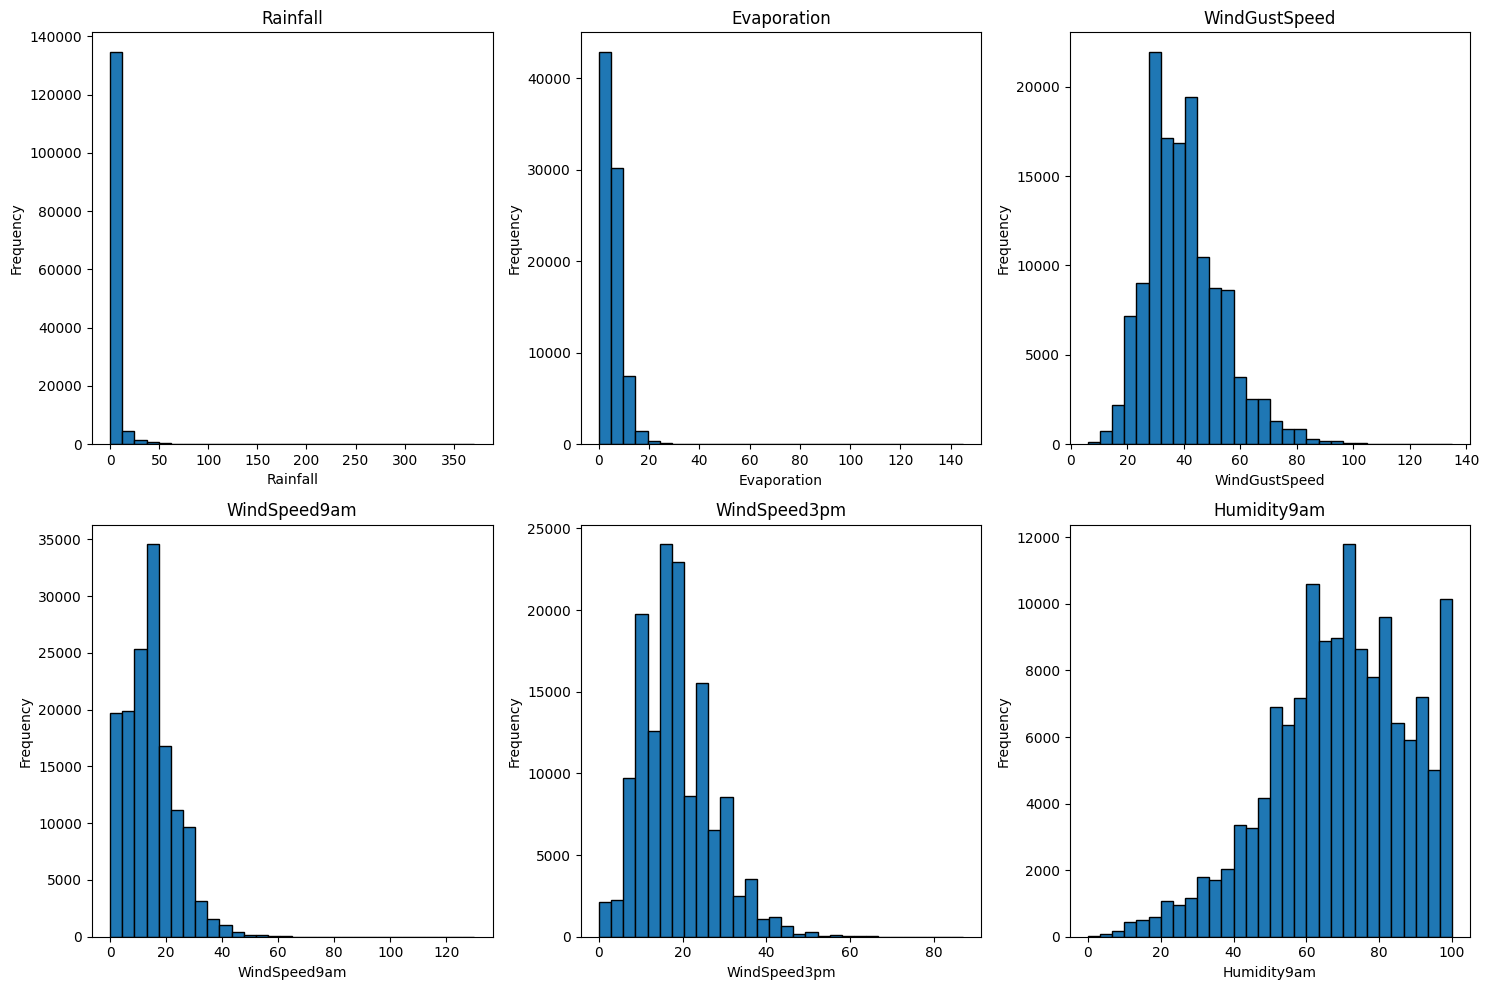

In [ ]:
plt.figure(figsize=(15,10))

# Plot for Rainfall
plt.subplot(2, 3, 1)  # Adjusted to a 2x3 grid for better spacing
plt.hist(df['Rainfall'].dropna(), bins=30, edgecolor='black')
plt.title('Rainfall')
plt.xlabel('Rainfall')
plt.ylabel('Frequency')

# Plot for Evaporation
plt.subplot(2, 3, 2)
plt.hist(df['Evaporation'].dropna(), bins=30, edgecolor='black')
plt.title('Evaporation')
plt.xlabel('Evaporation')
plt.ylabel('Frequency')

# Plot for WindGustSpeed
plt.subplot(2, 3, 3)
plt.hist(df['WindGustSpeed'].dropna(), bins=30, edgecolor='black')
plt.title('WindGustSpeed')
plt.xlabel('WindGustSpeed')
plt.ylabel('Frequency')

# Plot for WindSpeed9am
plt.subplot(2, 3, 4)
plt.hist(df['WindSpeed9am'].dropna(), bins=30, edgecolor='black')
plt.title('WindSpeed9am')
plt.xlabel('WindSpeed9am')
plt.ylabel('Frequency')

# Plot for WindSpeed3pm
plt.subplot(2, 3, 5)
plt.hist(df['WindSpeed3pm'].dropna(), bins=30, edgecolor='black')
plt.title('WindSpeed3pm')
plt.xlabel('WindSpeed3pm')
plt.ylabel('Frequency')

# Plot for Humidity9am
plt.subplot(2, 3, 6)
plt.hist(df['Humidity9am'].dropna(), bins=30, edgecolor='black')
plt.title('Humidity9am')
plt.xlabel('Humidity9am')
plt.ylabel('Frequency')

# Adjust layout for spacing
plt.tight_layout()
plt.show()


	1. Rainfall:
		○  highly skewed to the right, with most of the values clustered around zero.
		○  there are many days with no or little rainfall
		○  there are a few extreme outliers where the rainfall amount is significantly higher.
	2. Evaporation:
		○  skewed to the right, with most values below 20.

	3. WindGustSpeed:
		○  normal distribution, centered around 40 km/h, though slightly skewed to the right.
		○ Most of the gust speeds are between 20 km/h and 60 km/h
		○  there are some outliers with speeds exceeding 100 km/h.
	4. WindSpeed9am:
		○ right-skewed.
		○ The majority of values fall between 0 and 30 km/h, with relatively few days exceeding 50 km/h.
	5. WindSpeed3pm:
		○ right-skewed
		○ Most values are between 10 and 40 km/h, with a few higher wind speeds going above 50 km/h.
	6. Humidity9am:
		○  shows a left-skewed pattern, with many values clustered between 60% and 100%.
		○  Humidity rarely drops below 20%, indicating that the mornings tend to be humid.

Generate range of outliers

In [ ]:
variables = ['Rainfall', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am']

# Loop through each variable and calculate IQR, lower, and upper fences
for var in variables:
    IQR = df[var].quantile(0.75) - df[var].quantile(0.25)
    Lower_fence = df[var].quantile(0.25) - (IQR * 3)  # k = 3 for extreme outliers
    Upper_fence = df[var].quantile(0.75) + (IQR * 3)

    print(f'{var} outliers are values < {Lower_fence:.2f} or > {Upper_fence:.2f}')


Rainfall outliers are values < -2.40 or > 3.20
Evaporation outliers are values < -11.80 or > 21.80
WindGustSpeed outliers are values < -20.00 or > 99.00
WindSpeed9am outliers are values < -29.00 or > 55.00
WindSpeed3pm outliers are values < -20.00 or > 57.00
Humidity9am outliers are values < -21.00 or > 161.00


## Rainfall (target variable)


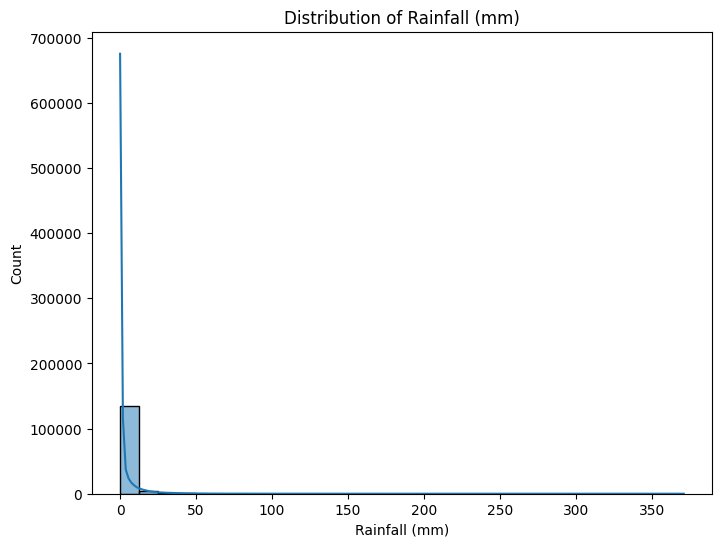

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram to visualize the distribution of rainfall values
plt.figure(figsize=(8,6))
sns.histplot(df['Rainfall'], bins=30, kde=True)
plt.title('Distribution of Rainfall (mm)')
plt.xlabel('Rainfall (mm)')
plt.show()


In [ ]:
  # Define updated bins and labels
  bins = [0, 5, 20, 50, df['Rainfall'].max()]
  labels = ['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']

  # Create binned categories without adding the column to the original df
  rainfall_categories = pd.cut(df['Rainfall'], bins=bins, labels=labels, right=False)

  # Check the distribution of each category
  rainfall_category_counts = rainfall_categories.value_counts()
  print("Rainfall Category Distribution:\n", rainfall_category_counts)



Rainfall Category Distribution:
 Rainfall
No Rain            125638
Moderate Rain       12478
Heavy Rain           3275
Very Heavy Rain       807
Name: count, dtype: int64


In [ ]:
# Calculate proportions of each category
rainfall_category_proportions = rainfall_categories.value_counts(normalize=True) * 100
print("Rainfall Category Proportions (%):\n", rainfall_category_proportions)

Rainfall Category Proportions (%):
 Rainfall
No Rain            88.354267
Moderate Rain       8.775088
Heavy Rain          2.303127
Very Heavy Rain     0.567519
Name: proportion, dtype: float64


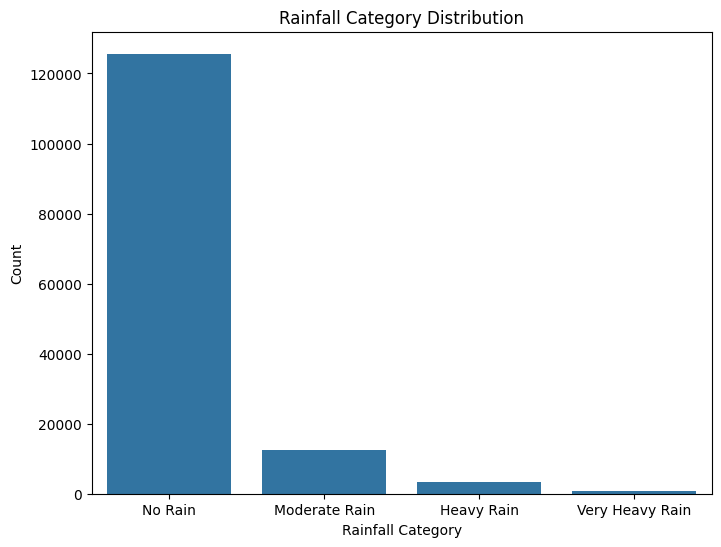

In [ ]:
# Bar plot to visualize the proportion of each rainfall category
plt.figure(figsize=(8,6))
sns.countplot(x=rainfall_categories)
plt.title('Rainfall Category Distribution')
plt.xlabel('Rainfall Category')
plt.ylabel('Count')
plt.show()

Distribution and Proportions:
*  0 No Rain:
  *  Count: 108,560
  *  Proportion: 76.34% of the days had no rainfall.
*  5 Light Rain:
  *  Count: 24,184
  *  Proportion: 17.01% of the days had light rain (between 1-10 mm).
*  10 Moderate Rain:
  *  Count: 7,303
  *  Proportion: 5.14% of the days had moderate rain (between 10-30 mm).
*  20 Heavy Rain:
  *  Count: 2,001
  *  Proportion: 1.41% of the days had heavy rain (between 30-100 mm).
*  50 Very Heavy Rain:
  *  Count: 150
  *  Proportion: 0.11% of the days had very heavy rain (more than 100 mm).


Key Observations:

Severe Imbalance: The majority of days (~76%) had no rainfall at all. A large portion of your data is concentrated in this category, leading to an imbalance.

Underrepresented Classes:
Very Heavy Rain, only 0.11% of the data (150 instances).
Heavy Rain , just 1.41% of the dataset.

Low Rainfall Dominance: The data is heavily skewed towards no rain and light rain days, with almost 93% of the data (76.34% + 17.01%) covering those two categories.

Implications:
This imbalance might affect the model's ability to accurately predict days with moderate to very heavy rainfall, as those events are underrepresented.
The model could be biased towards predicting no rain or light rain, as those cases dominate the dataset.

Potential Solutions:

Resampling:

Oversample the minority categories (e.g., moderate, heavy, and very heavy rain) to give them more weight in training.
Undersample the majority category (no rain) to reduce its dominance.
Use Weighted Loss Functions: In machine learning models, you can adjust the loss function to give more weight to the underrepresented categories.

Generate Synthetic Data: Techniques like SMOTE (Synthetic Minority Oversampling Technique) could be used to generate synthetic data points for the minority classes.

Rainfall greater than 200mm

Distribution of Rainfall > 200 mm:
 count     14.000000
mean     250.185714
std       55.226121
min      206.200000
25%      212.025000
50%      230.900000
75%      263.250000
max      371.000000
Name: Rainfall, dtype: float64


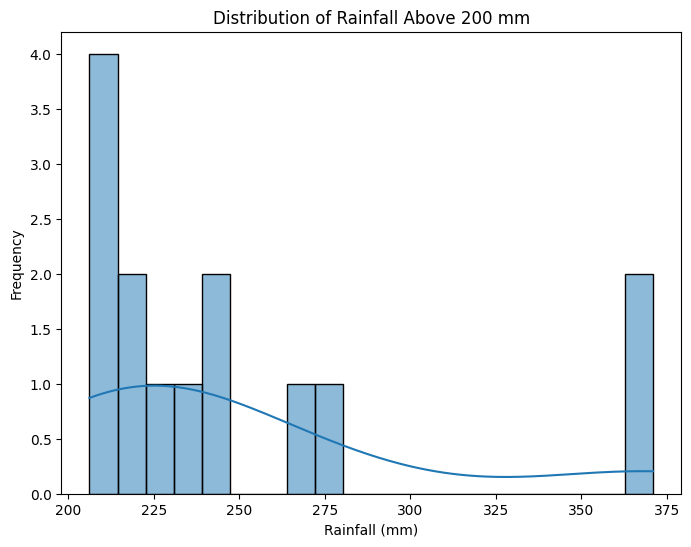

In [ ]:
# Filter for rainfall greater than 200mm
rainfall_above_200= df[df['Rainfall'] > 200]

# Check the distribution statistics for rainfall > 200mm
rainfall_above_200_distribution = rainfall_above_200['Rainfall'].describe()
print("Distribution of Rainfall > 200 mm:\n", rainfall_above_200_distribution)

# Plot histogram to visualize the distribution
plt.figure(figsize=(8,6))
sns.histplot(rainfall_above_200['Rainfall'], bins=20, kde=True)
plt.title('Distribution of Rainfall Above 200 mm')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()


In [ ]:
from IPython.display import display, HTML

display(HTML(rainfall_above_200.to_html()))

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day,WindGustDir_Angle
9368,CoffsHarbour,17.4,23.1,371.0,NaN,3.5,NaN,NaN,SW,S,13.0,19.0,93.0,81.0,1026.6,1025.9,8.0,5.0,18.6,22.0,Yes,Yes,2009,11,7,NaN
10485,CoffsHarbour,20.9,23.3,208.5,NaN,0.0,NNE,65.0,NE,NNE,37.0,31.0,96.0,96.0,1006.8,1004.2,8.0,8.0,21.5,21.3,Yes,Yes,2013,1,28,22.5
11681,CoffsHarbour,14.6,19.2,219.6,NaN,NaN,WSW,70.0,WNW,NNE,9.0,19.0,90.0,83.0,998.5,993.7,8.0,8.0,16.5,18.0,Yes,No,2016,6,5,247.5
17321,Newcastle,NaN,21.7,240.0,NaN,NaN,NaN,NaN,NW,NaN,4.0,0.0,72.0,62.0,NaN,NaN,6.0,6.0,17.5,21.0,Yes,No,2015,4,23,NaN
17579,Newcastle,15.5,NaN,216.3,NaN,NaN,NaN,NaN,SE,NaN,37.0,NaN,98.0,NaN,NaN,NaN,8.0,NaN,18.8,NaN,Yes,Yes,2016,1,6,NaN
42010,Williamtown,18.5,19.9,225.0,NaN,0.0,S,80.0,SSW,SSW,39.0,35.0,95.0,90.0,1008.5,1008.8,8.0,8.0,19.2,19.4,Yes,Yes,2016,1,6,180.0
87242,Cairns,22.3,27.4,278.4,NaN,0.0,NW,59.0,SSE,NNW,17.0,11.0,96.0,98.0,1003.5,999.6,8.0,8.0,24.7,25.3,Yes,Yes,2009,1,12,315.0
87995,Cairns,22.9,29.9,268.6,NaN,2.0,ENE,37.0,ENE,ENE,15.0,11.0,82.0,84.0,1011.1,1009.3,6.0,8.0,29.8,28.0,Yes,Yes,2011,2,4,67.5
88222,Cairns,21.1,23.1,206.2,1.4,0.0,SE,44.0,SSE,SE,22.0,13.0,91.0,96.0,1017.7,1014.8,8.0,8.0,22.7,22.0,Yes,Yes,2011,10,19,135.0
89371,Cairns,23.8,31.0,247.2,NaN,2.0,E,44.0,SSE,SE,17.0,28.0,100.0,74.0,1014.2,1011.4,8.0,8.0,25.3,30.0,Yes,Yes,2015,2,8,90.0


this records are related to flooding

Rainfall greater than 100mm

Distribution of Rainfall > 100 mm:
 count    151.000000
mean     140.347682
std       45.646077
min      100.200000
25%      109.500000
50%      122.800000
75%      157.700000
max      371.000000
Name: Rainfall, dtype: float64


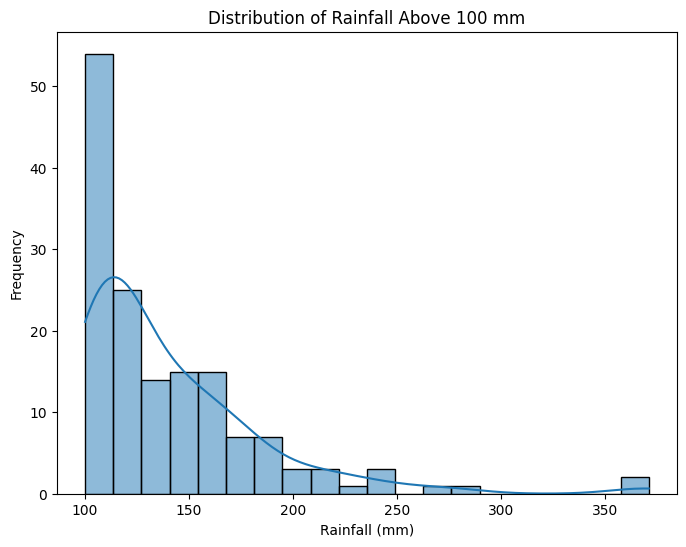

In [ ]:
# Filter for rainfall greater than 100mm
rainfall_above_100= df[df['Rainfall'] > 100]

# Check the distribution statistics for rainfall > 100mm
rainfall_above_100_distribution = rainfall_above_100['Rainfall'].describe()
print("Distribution of Rainfall > 100 mm:\n", rainfall_above_100_distribution)

# Plot histogram to visualize the distribution
plt.figure(figsize=(8,6))
sns.histplot(rainfall_above_100['Rainfall'], bins=20, kde=True)
plt.title('Distribution of Rainfall Above 100 mm')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()

Rainfall greater than 50mm

Distribution of Rainfall > 50 mm:
 count    799.000000
mean      80.849061
std       36.844812
min       50.200000
25%       57.400000
50%       69.200000
75%       89.100000
max      371.000000
Name: Rainfall, dtype: float64


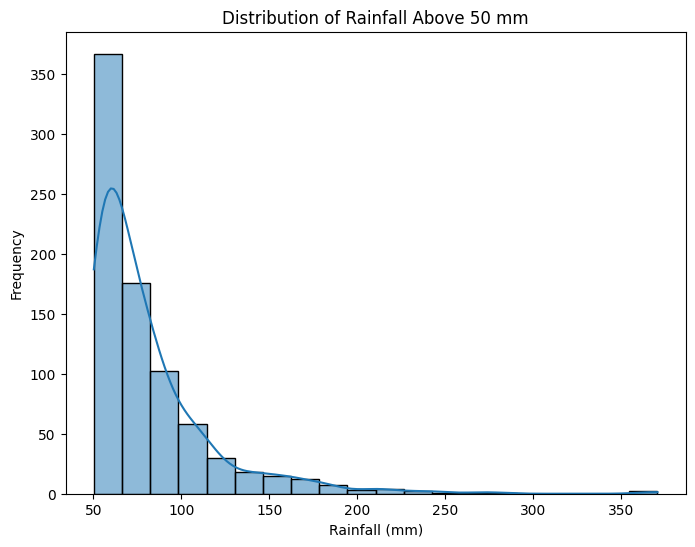

In [ ]:
# Filter for rainfall greater than 50mm
rainfall_above_50= df[df['Rainfall'] > 50]

# Check the distribution statistics for rainfall > 50mm
rainfall_above_50_distribution = rainfall_above_50['Rainfall'].describe()
print("Distribution of Rainfall > 50 mm:\n", rainfall_above_50_distribution)

# Plot histogram to visualize the distribution
plt.figure(figsize=(8,6))
sns.histplot(rainfall_above_50['Rainfall'], bins=20, kde=True)
plt.title('Distribution of Rainfall Above 50 mm')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()

# Multivariate Analysis

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
# Assuming df is already loaded
df_encoded = df.copy()  # Create a copy of the original DataFrame

# Drop 'RainToday' and 'RainTomorrow' columns
df_encoded.drop(['RainToday', 'RainTomorrow'], axis=1, inplace=True)



Rainfall Category Distribution:
 Rainfall_Category
No Rain            125638
Light Rain           7106
Moderate Rain        5372
Heavy Rain           3275
Very Heavy Rain       808
Name: count, dtype: int64
Rainfall Category Proportions (%):
 Rainfall_Category
No Rain            88.353645
Light Rain          4.997222
Moderate Rain       3.777804
Heavy Rain          2.303110
Very Heavy Rain     0.568218
Name: proportion, dtype: float64


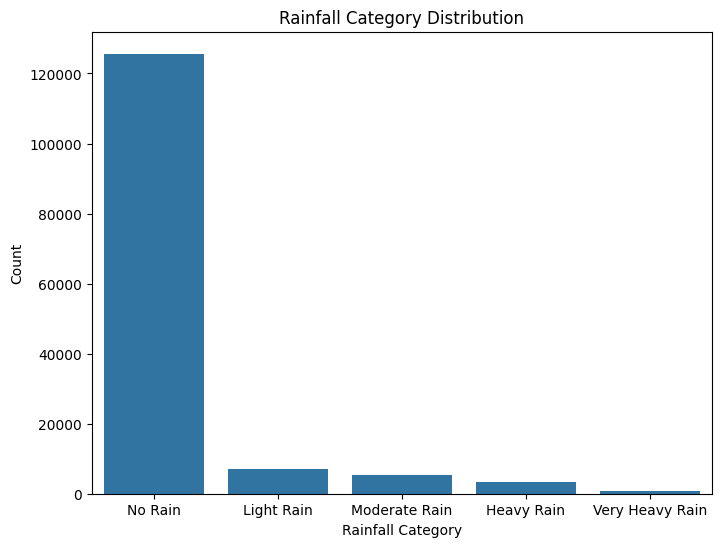

Rainfall Category Distribution:
 Rainfall_Category
No Rain            125638
Light Rain           7106
Moderate Rain        5372
Heavy Rain           3275
Very Heavy Rain       808
Name: count, dtype: int64
Rainfall Category Proportions (%):
 Rainfall_Category
No Rain            88.353645
Light Rain          4.997222
Moderate Rain       3.777804
Heavy Rain          2.303110
Very Heavy Rain     0.568218
Name: proportion, dtype: float64
Number of NaN values in 'Rainfall_Category': 3261


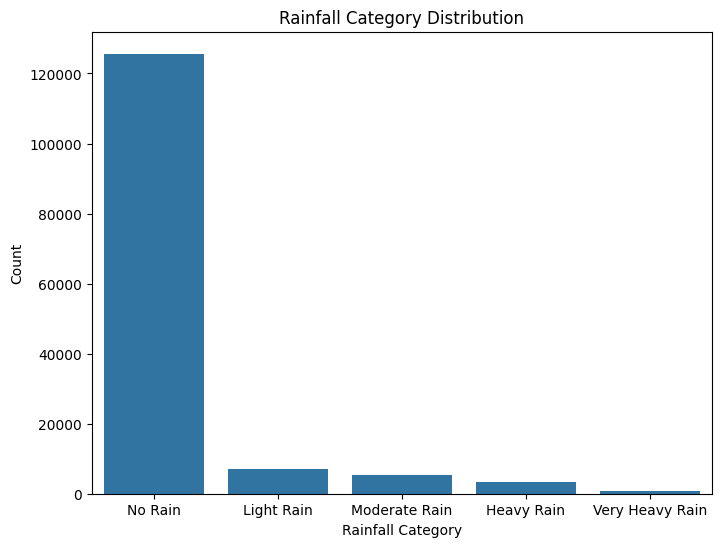

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define updated bins and labels
bins = [0, 5, 10, 20, 50, float('inf')] # the last bin to include all rainfall > 50mm
labels = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']
# Add a new column to df with binned categories
df_encoded['Rainfall_Category'] = pd.cut(df_encoded['Rainfall'], bins=bins, labels=labels, right=False)

# Check the distribution of each category
rainfall_category_counts = df_encoded['Rainfall_Category'].value_counts()
print("Rainfall Category Distribution:\n", rainfall_category_counts)
# Calculate proportions of each category
rainfall_category_proportions = df_encoded['Rainfall_Category'].value_counts(normalize=True) * 100
print("Rainfall Category Proportions (%):\n", rainfall_category_proportions)
# Bar plot to visualize the proportion of each rainfall category
plt.figure(figsize=(8,6))
sns.countplot(x='Rainfall_Category', data=df_encoded, order=labels)
plt.title('Rainfall Category Distribution')
plt.xlabel('Rainfall Category')
plt.ylabel('Count')
plt.show()

# Define updated bins and labels
bins = [0, 5, 10, 20, 50, float('inf')] # the last bin to include all rainfall > 50mm
labels = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']

# Add a new column to df with binned categories
df_encoded['Rainfall_Category'] = pd.cut(df_encoded['Rainfall'], bins=bins, labels=labels, right=False)

# Check the distribution of each category
rainfall_category_counts = df_encoded['Rainfall_Category'].value_counts()
print("Rainfall Category Distribution:\n", rainfall_category_counts)

# Calculate proportions of each category
rainfall_category_proportions = df_encoded['Rainfall_Category'].value_counts(normalize=True) * 100
print("Rainfall Category Proportions (%):\n", rainfall_category_proportions)

# Check for NaN values in 'Rainfall_Category'
nan_count = df_encoded['Rainfall_Category'].isna().sum()
print("Number of NaN values in 'Rainfall_Category':", nan_count)

# Bar plot to visualize the proportion of each rainfall category
plt.figure(figsize=(8,6))
sns.countplot(x='Rainfall_Category', data=df_encoded, order=labels)
plt.title('Rainfall Category Distribution')
plt.xlabel('Rainfall Category')
plt.ylabel('Count')
plt.show()

df_encoded.dropna(subset=['Rainfall'], inplace=True)


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# One-Hot Encode the 'Rainfall_Category' column without dropping any category
one_hot_encoder = OneHotEncoder(sparse_output=False)  # Use `sparse_output=False` instead of `sparse=False`
encoded_columns = one_hot_encoder.fit_transform(df_encoded[['Rainfall_Category']])
encoded_df = pd.DataFrame(encoded_columns, columns=one_hot_encoder.get_feature_names_out(['Rainfall_Category']))
df_encoded = pd.concat([df_encoded.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)


In [ ]:
#ENCODING
directions = {'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
              'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5, 'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5}
# Manual Target Encoding for Location
location_means = df_encoded.groupby('Location')['Rainfall'].mean()
df_encoded['Location_Target_Encoded'] = df_encoded['Location'].map(location_means)
df_encoded.drop('Location', axis=1, inplace=True)
# Cyclic Encoding for Wind Direction features
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    df_encoded[f'{col}_sin'] = df_encoded[col].map(directions).apply(lambda x: np.sin(np.radians(x)) if not pd.isna(x) else np.nan)
    df_encoded[f'{col}_cos'] = df_encoded[col].map(directions).apply(lambda x: np.cos(np.radians(x)) if not pd.isna(x) else np.nan)
    df_encoded.drop(col, axis=1, inplace=True)

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142199 entries, 0 to 142198
Data columns (total 32 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   MinTemp                            141712 non-null  float64 
 1   MaxTemp                            141729 non-null  float64 
 2   Rainfall                           142199 non-null  float64 
 3   Evaporation                        81711 non-null   float64 
 4   Sunshine                           74379 non-null   float64 
 5   WindGustSpeed                      132534 non-null  float64 
 6   WindSpeed9am                       141108 non-null  float64 
 7   WindSpeed3pm                       139552 non-null  float64 
 8   Humidity9am                        140645 non-null  float64 
 9   Humidity3pm                        138569 non-null  float64 
 10  Pressure9am                        128259 non-null  float64 
 11  Pressure3pm               

In [ ]:
# prompt: drop  Rainfall_Category
df_encoded.drop('Rainfall_Category', axis=1, inplace=True)

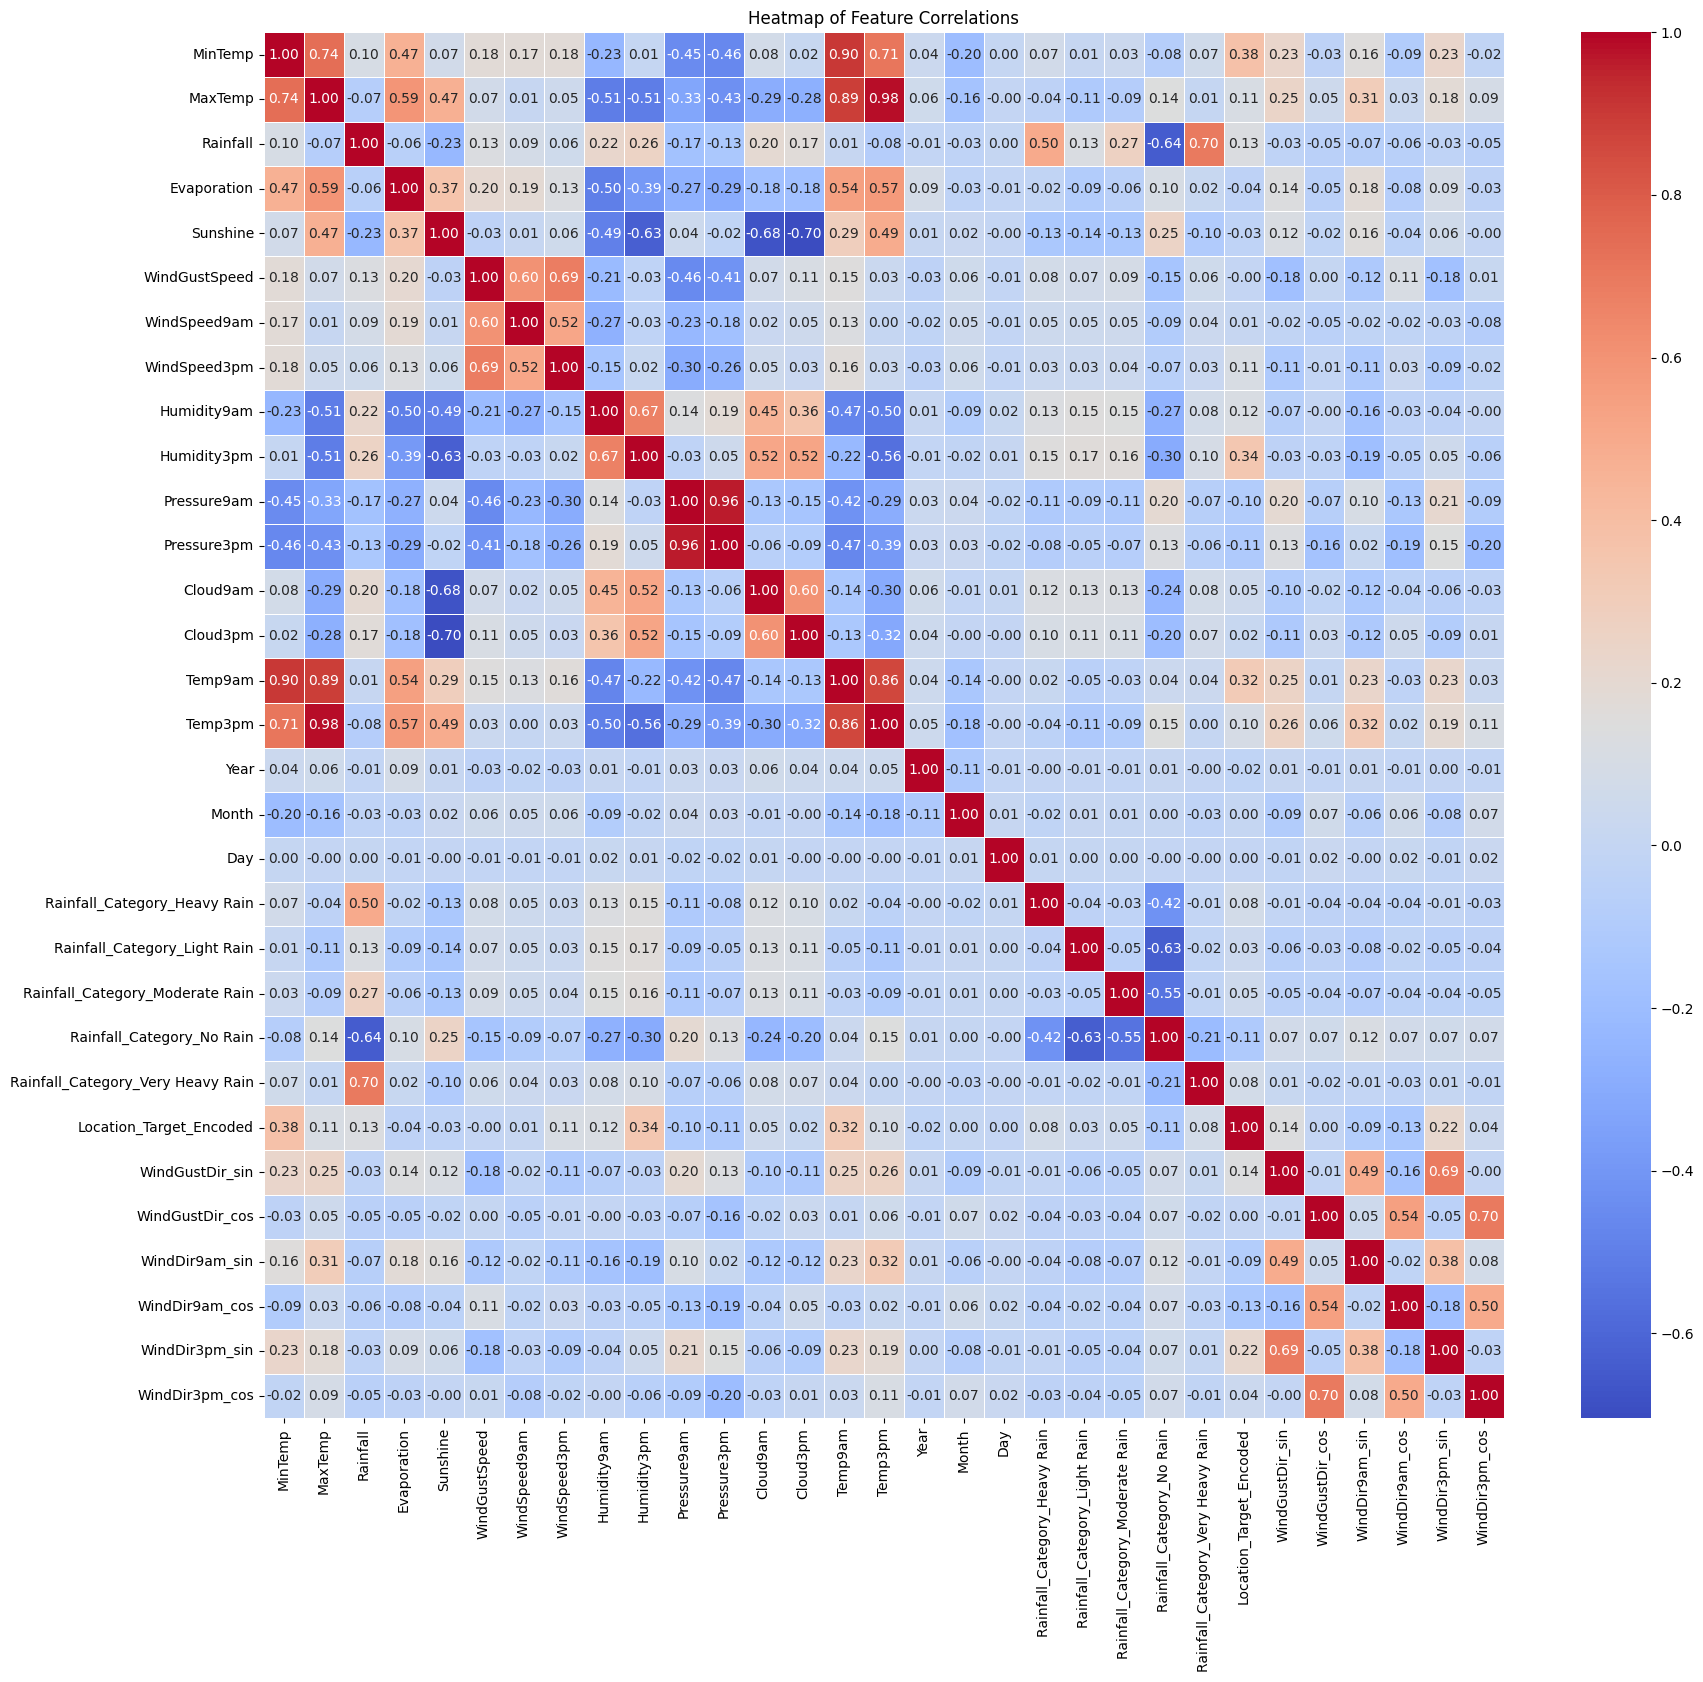

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap of Feature Correlations')
plt.show()


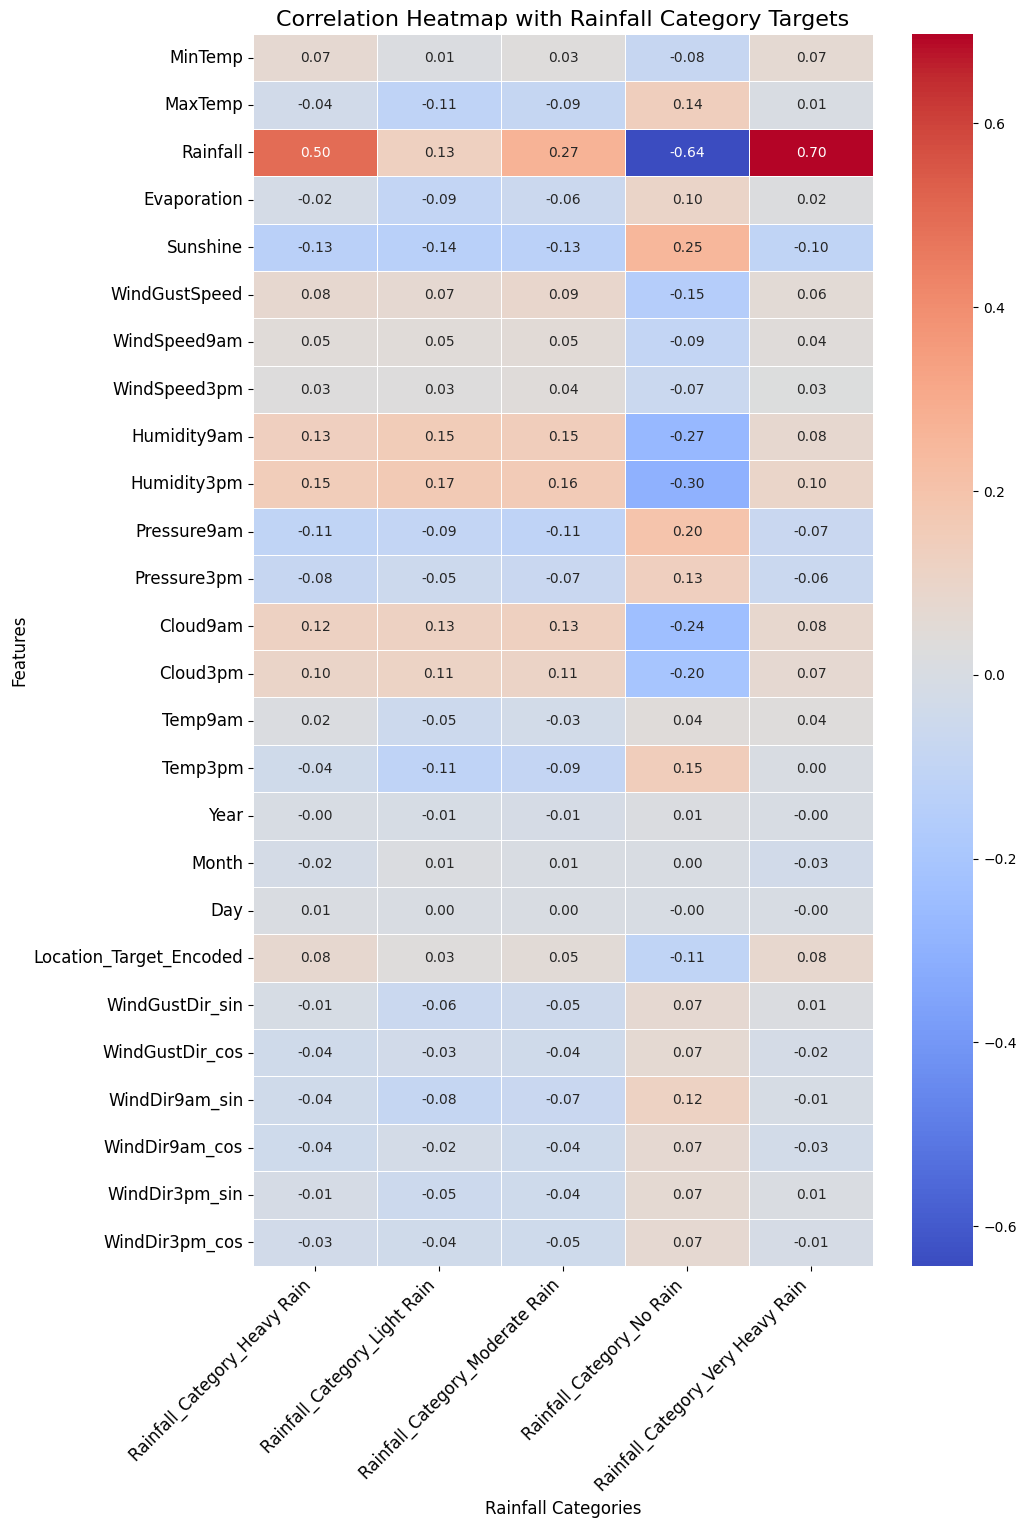

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the target columns
target_columns = [
    'Rainfall_Category_Heavy Rain',
    'Rainfall_Category_Light Rain',
    'Rainfall_Category_Moderate Rain',
    'Rainfall_Category_No Rain',
    'Rainfall_Category_Very Heavy Rain'
]

# Calculate the correlation matrix
correlation = df_encoded.corr()

# Extract correlations with each target category
target_correlations = correlation[target_columns].drop(target_columns)

# Plotting the correlation heatmap for the target categories
plt.figure(figsize=(10, 16))
plt.title('Correlation Heatmap with Rainfall Category Targets', fontsize=16)
ax = sns.heatmap(target_correlations, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='white', cbar=True)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.xlabel('Rainfall Categories', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()


In [ ]:
import pandas as pd
from tabulate import tabulate

# Define the target columns
target_columns = [
    'Rainfall_Category_Light Rain',
    'Rainfall_Category_Moderate Rain',
    'Rainfall_Category_No Rain',
    'Rainfall_Category_Very Heavy Rain'
]

# Calculate the correlation matrix
correlation = df_encoded.corr()

# Create an empty DataFrame to store importance rankings for each target category
importance_rankings = pd.DataFrame()

# Loop through each target column to calculate and rank feature correlations
for target_column in target_columns:
    # Get correlations with the target variable and drop self-correlation
    target_correlations = correlation[target_column].drop(target_column)

    # Sort features by absolute correlation with the current target
    sorted_correlations = target_correlations.abs().sort_values(ascending=False)

    # Create a temporary DataFrame for the current target category
    temp_df = pd.DataFrame({
        'Feature': sorted_correlations.index,
        f'Correlation with {target_column}': sorted_correlations.values
    })

    # Merge into the main importance rankings DataFrame
    if importance_rankings.empty:
        importance_rankings = temp_df
    else:
        importance_rankings = importance_rankings.merge(temp_df, on='Feature', how='outer')

# Display the feature importance rankings
print("Feature Importance Ranking based on Correlation with Each Rainfall Category:")
print(importance_rankings)

# Display the ranking in tabular form for better presentation
print("\nFeature Importance Ranking in Tabular Format:")
print(tabulate(importance_rankings, headers='keys', tablefmt='pretty'))


Feature Importance Ranking based on Correlation with Each Rainfall Category:
                              Feature  \
0                            Cloud3pm   
1                            Cloud9am   
2                                 Day   
3                         Evaporation   
4                         Humidity3pm   
5                         Humidity9am   
6             Location_Target_Encoded   
7                             MaxTemp   
8                             MinTemp   
9                               Month   
10                        Pressure3pm   
11                        Pressure9am   
12                           Rainfall   
13       Rainfall_Category_Heavy Rain   
14       Rainfall_Category_Light Rain   
15    Rainfall_Category_Moderate Rain   
16          Rainfall_Category_No Rain   
17  Rainfall_Category_Very Heavy Rain   
18                           Sunshine   
19                            Temp3pm   
20                            Temp9am   
21                   

## RF

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# Define the feature set (X) and the multi-class target variable (y)
X = df_encoded.drop(columns=[
    'Rainfall_Category_Light Rain',
    'Rainfall_Category_Moderate Rain',
    'Rainfall_Category_No Rain',
    'Rainfall_Category_Heavy Rain',
    'Rainfall_Category_Very Heavy Rain'
])

# Define the target variable as the highest probability class
y = df_encoded[['Rainfall_Category_Light Rain', 'Rainfall_Category_Moderate Rain',
                'Rainfall_Category_No Rain', 'Rainfall_Category_Heavy Rain',
                'Rainfall_Category_Very Heavy Rain']].idxmax(axis=1)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a DataFrame to display feature importance rankings
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Feature Importance Ranking based on Random Forest:")
print(feature_importance_df)


Feature Importance Ranking based on Random Forest:
                    Feature  Importance
0                  Rainfall    0.763631
1               Humidity9am    0.026947
2               Humidity3pm    0.021726
3               Pressure9am    0.016958
4                   MinTemp    0.013456
5               Pressure3pm    0.011242
6             WindGustSpeed    0.010985
7                   MaxTemp    0.010534
8                   Temp9am    0.010478
9                   Temp3pm    0.010452
10              Evaporation    0.009038
11                 Sunshine    0.008849
12  Location_Target_Encoded    0.008533
13             WindSpeed9am    0.007923
14                 Cloud9am    0.007839
15                      Day    0.007806
16             WindSpeed3pm    0.006837
17           WindDir9am_cos    0.006026
18                    Month    0.005520
19           WindDir9am_sin    0.005455
20          WindGustDir_cos    0.005232
21                     Year    0.005167
22           WindDir3pm_cos  

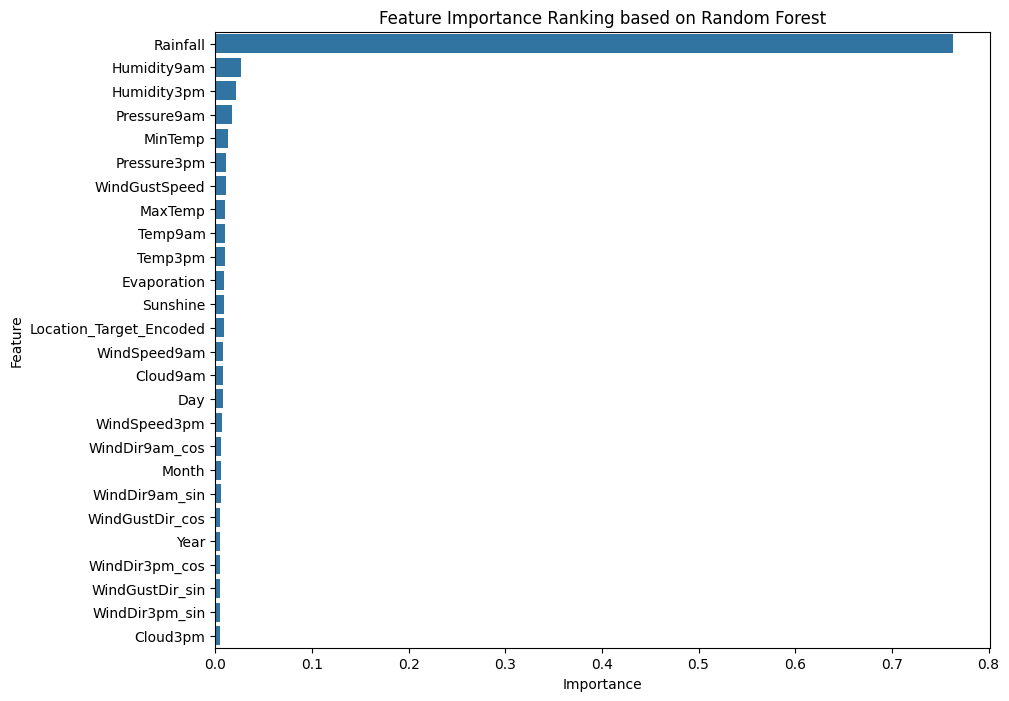

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot feature importances
plt.figure(figsize=(10, 8))
plt.title('Feature Importance Ranking based on Random Forest')
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


# Data Cleaning: Categorical Variables

## Remove Unnesscary column

In [ ]:
# Remove 'RainToday' and 'RainTomorrow' columns
df = df.drop(['RainToday', 'RainTomorrow'], axis=1)

In [ ]:
df.info() #summary of dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       145460 non-null  object 
 1   MinTemp        143975 non-null  float64
 2   MaxTemp        144199 non-null  float64
 3   Rainfall       142199 non-null  float64
 4   Evaporation    82670 non-null   float64
 5   Sunshine       75625 non-null   float64
 6   WindGustDir    135134 non-null  object 
 7   WindGustSpeed  135197 non-null  float64
 8   WindDir9am     134894 non-null  object 
 9   WindDir3pm     141232 non-null  object 
 10  WindSpeed9am   143693 non-null  float64
 11  WindSpeed3pm   142398 non-null  float64
 12  Humidity9am    142806 non-null  float64
 13  Humidity3pm    140953 non-null  float64
 14  Pressure9am    130395 non-null  float64
 15  Pressure3pm    130432 non-null  float64
 16  Cloud9am       89572 non-null   float64
 17  Cloud3pm       86102 non-null

## Missing data


In [ ]:
categorical1 = [var for var in df.columns if df[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical1)))

print('The categorical variables are :', categorical1)

There are 4 categorical variables

The categorical variables are : ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']


In [ ]:
df[categorical1].isnull().sum() # check missing values

,0
Location,0
WindGustDir,10326
WindDir9am,10566
WindDir3pm,4228


In [ ]:
# Calculate the percentage of missing values for each categorical variable
for var in categorical1:
  percentage_missing_cat = (df[var].isnull().sum() / len(df)) * 100
  print(f"Percentage of missing values in {var}: {percentage_missing_cat:.2f}%")

Percentage of missing values in Location: 0.00%
Percentage of missing values in WindGustDir: 7.10%
Percentage of missing values in WindDir9am: 7.26%
Percentage of missing values in WindDir3pm: 2.91%


In [ ]:
# Impute missing values in 'WindGustDir', 'WindDir9am', 'WindDir3pm' with the most frequent value
for variable in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
  most_frequent_value = df[variable].mode()[0]  # Get the most frequent value
  df[variable].fillna(most_frequent_value, inplace=True)


In [ ]:
df[categorical1].isnull().sum() # check missing values

,0
Location,0
WindGustDir,0
WindDir9am,0
WindDir3pm,0


##  Encoding

In [ ]:
!pip install category_encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 6.7 MB/s eta 0:00:00


In [ ]:


directions = {'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
              'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5, 'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5}

# Target Encoding for Location
location_means = df.groupby('Location')['Rainfall'].mean()
df['Location_Target_Encoded'] = df['Location'].map(location_means)
df.drop('Location', axis=1, inplace=True)

# Cyclic Encoding for Wind Direction features
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    df[f'{col}_sin'] = df[col].map(directions).apply(lambda x: np.sin(np.radians(x)) if not pd.isna(x) else np.nan)
    df[f'{col}_cos'] = df[col].map(directions).apply(lambda x: np.cos(np.radians(x)) if not pd.isna(x) else np.nan)
    df.drop(col, axis=1, inplace=True)

print(df.head())


   MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0     13.4     22.9       0.6          NaN       NaN           44.0   
1      7.4     25.1       0.0          NaN       NaN           44.0   
2     12.9     25.7       0.0          NaN       NaN           46.0   
3      9.2     28.0       0.0          NaN       NaN           24.0   
4     17.5     32.3       1.0          NaN       NaN           41.0   

   WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...  Year  Month  \
0          20.0          24.0         71.0         22.0  ...  2008     12   
1           4.0          22.0         44.0         25.0  ...  2008     12   
2          19.0          26.0         38.0         30.0  ...  2008     12   
3          11.0           9.0         45.0         16.0  ...  2008     12   
4           7.0          20.0         82.0         33.0  ...  2008     12   

   Day  Location_Target_Encoded  WindGustDir_sin  WindGustDir_cos  \
0    1                 1.914115        -1

In [ ]:
df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Year,Month,Day,Location_Target_Encoded,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,...,2008,12,1,1.914115,-1.000000,-1.836970e-16,-1.000000,-1.836970e-16,-0.923880,3.826834e-01
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,...,2008,12,2,1.914115,-0.923880,3.826834e-01,-0.382683,9.238795e-01,-0.923880,-3.826834e-01
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,...,2008,12,3,1.914115,-0.923880,-3.826834e-01,-1.000000,-1.836970e-16,-0.923880,-3.826834e-01
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,...,2008,12,4,1.914115,0.707107,7.071068e-01,0.707107,-7.071068e-01,1.000000,6.123234e-17
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,...,2008,12,5,1.914115,-1.000000,-1.836970e-16,0.923880,3.826834e-01,-0.707107,7.071068e-01


# Data Cleaning: Numerical Variables

In [ ]:
# Now you can print the number of numerical variables and their names
print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are:', list(numerical))

# find numerical variables
print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)

There are 19 numerical variables

The numerical variables are: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Year', 'Month', 'Day']
There are 19 numerical variables

The numerical variables are : ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Year', 'Month', 'Day']


## Missing data

To impute the missing values using median imputation because it is robust to outliers, and assume that the data are missing completely at random (MCAR).

To use the statistical measures used to fill missing values, the median,

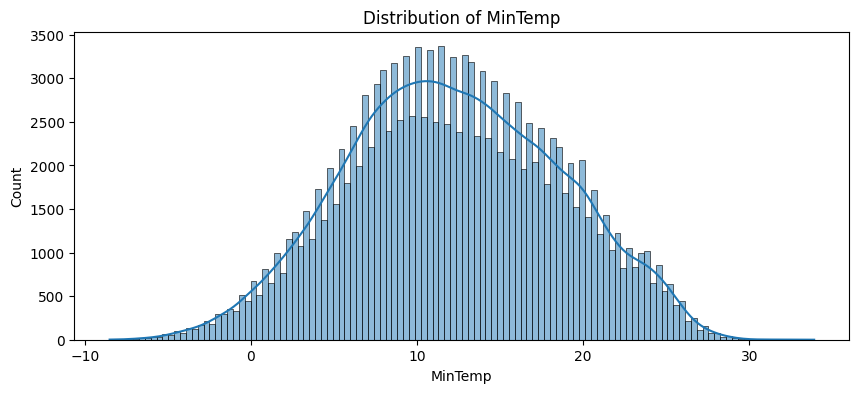

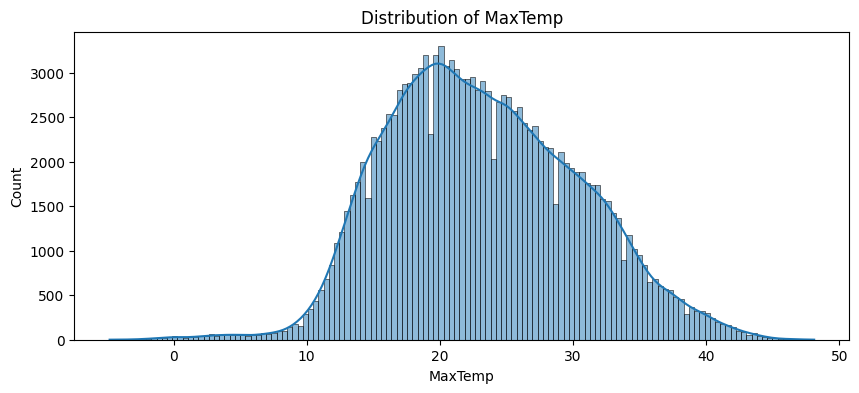

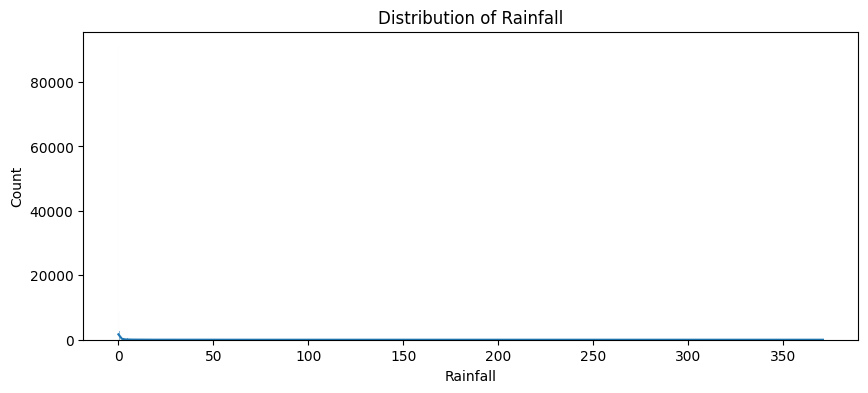

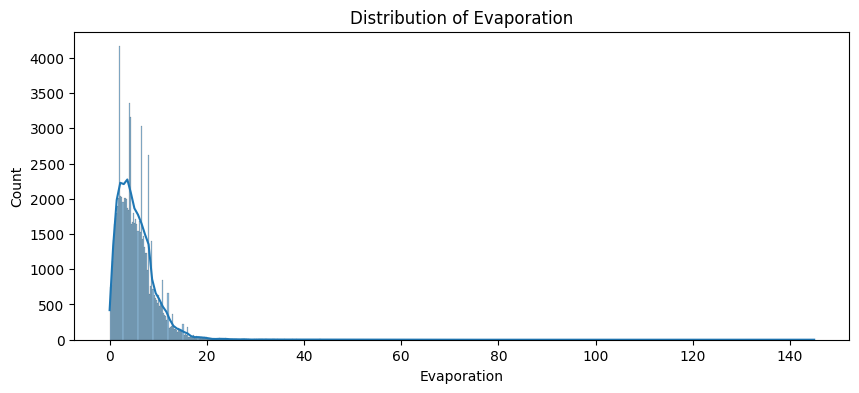

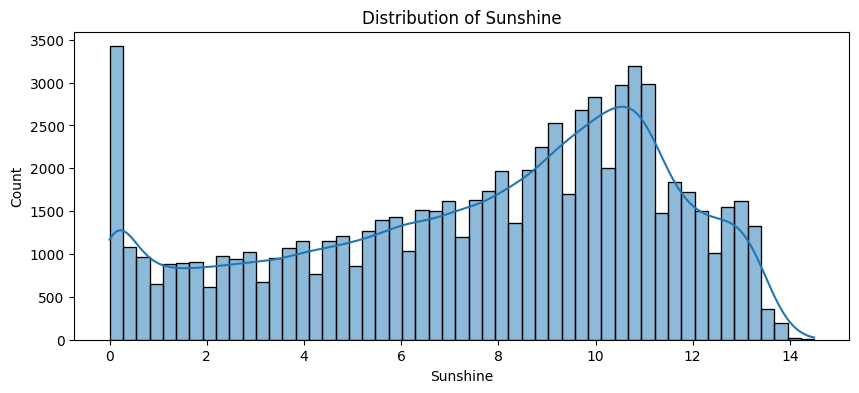

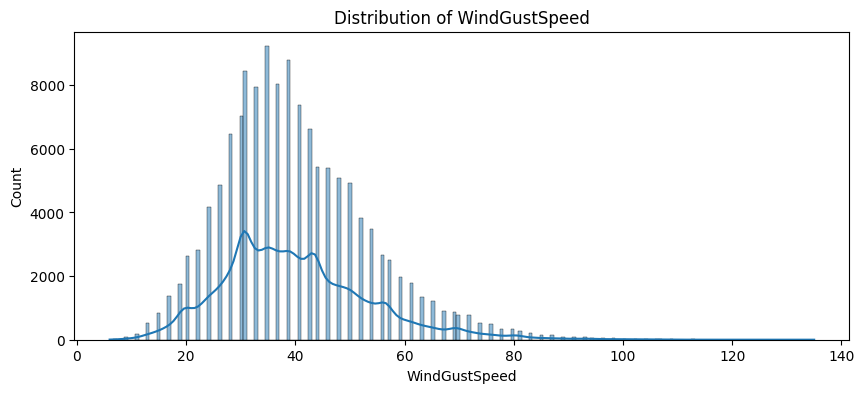

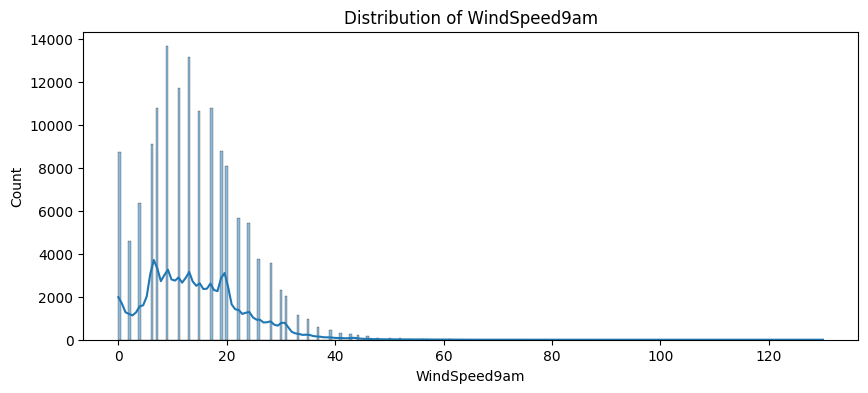

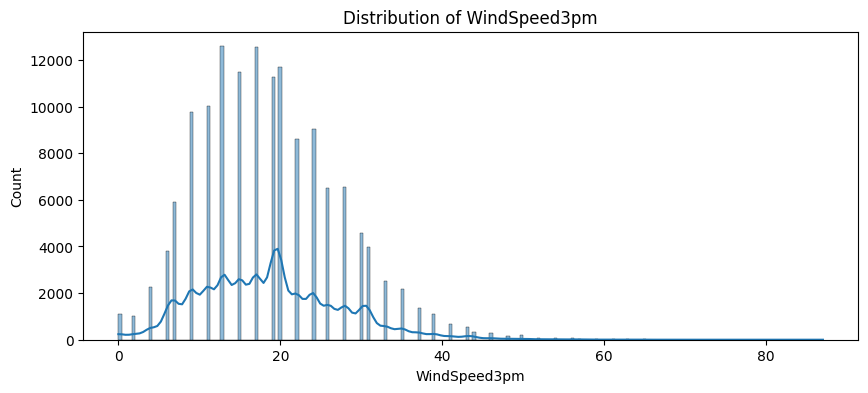

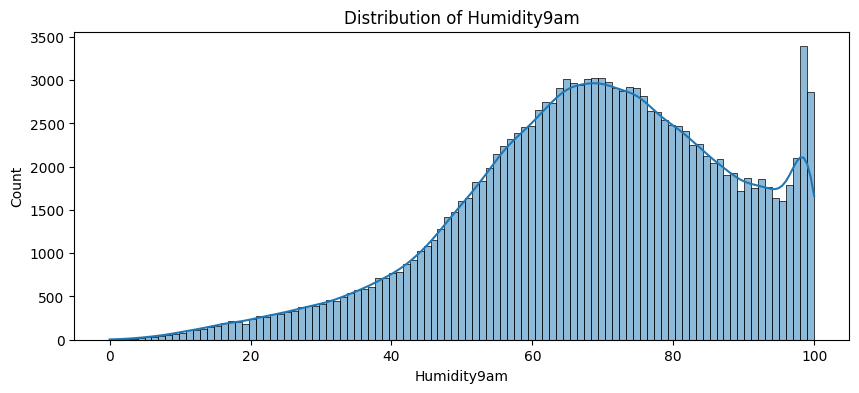

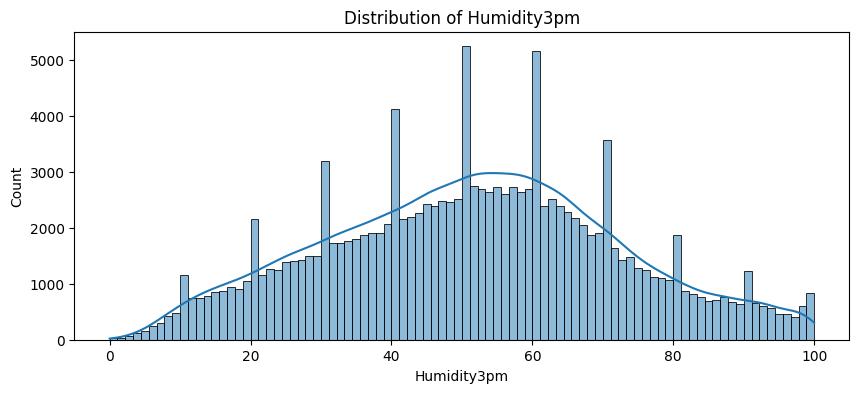

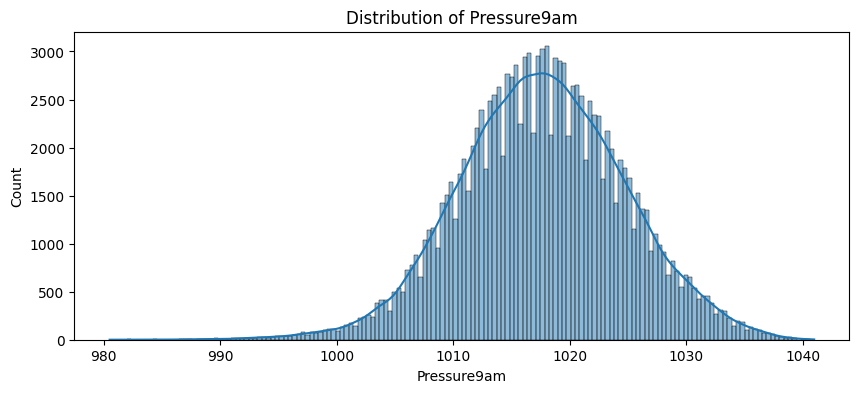

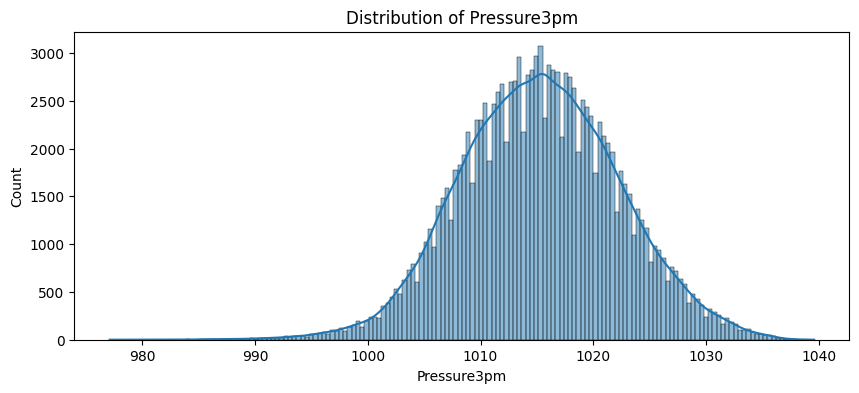

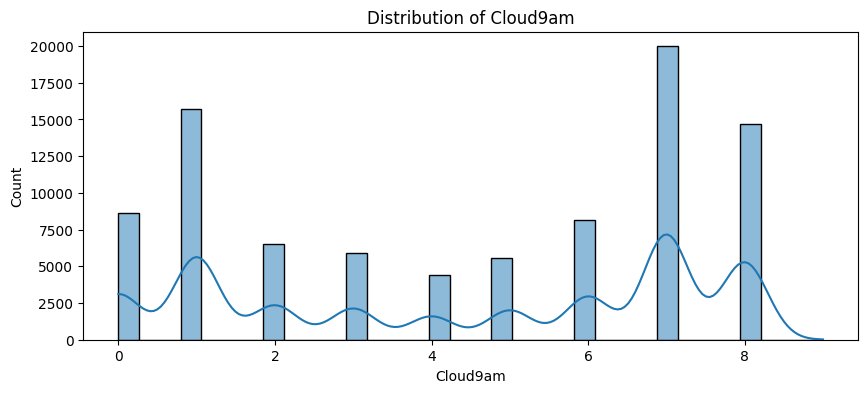

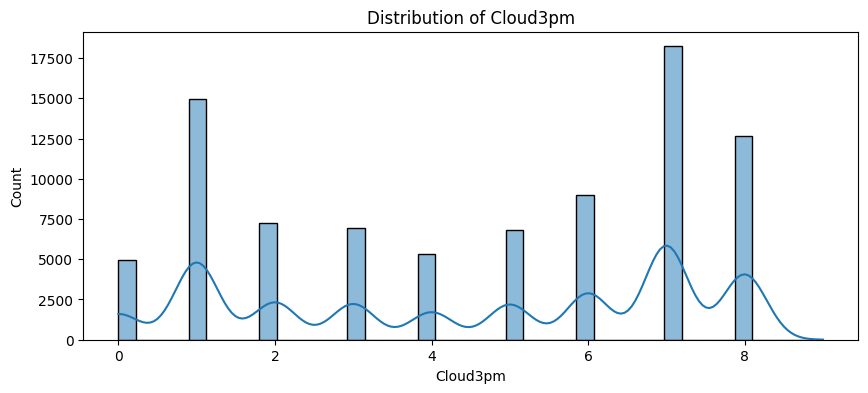

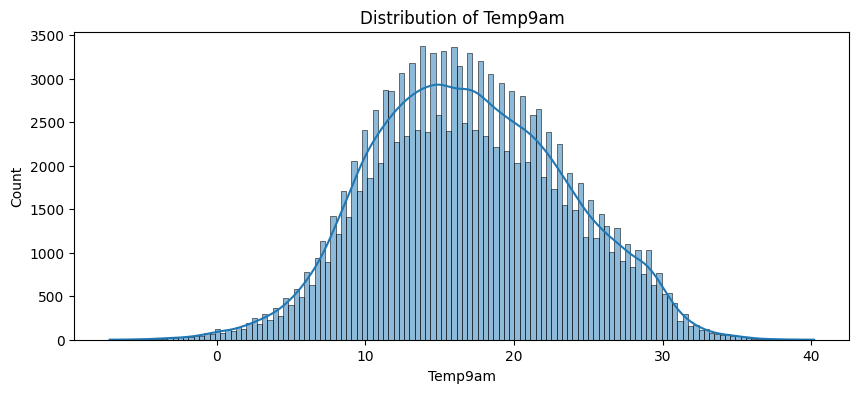

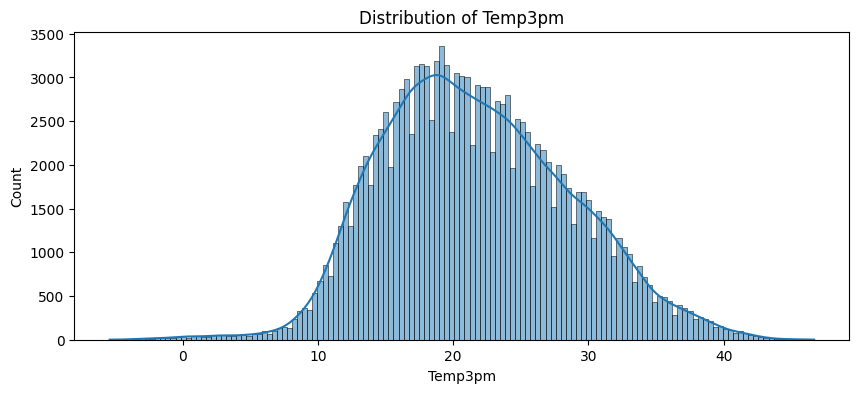

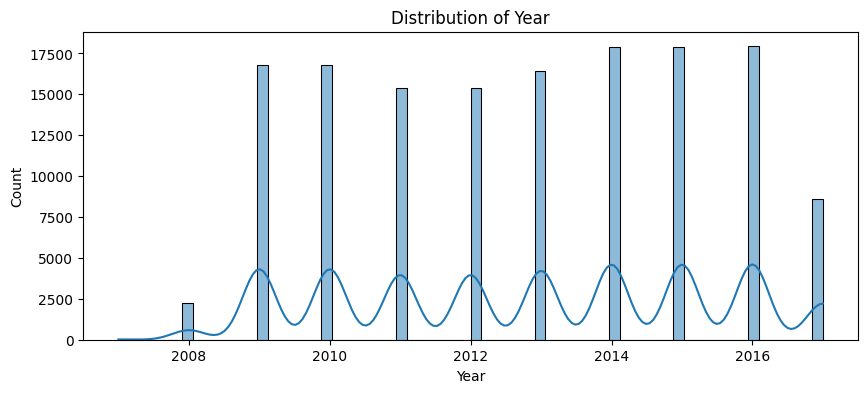

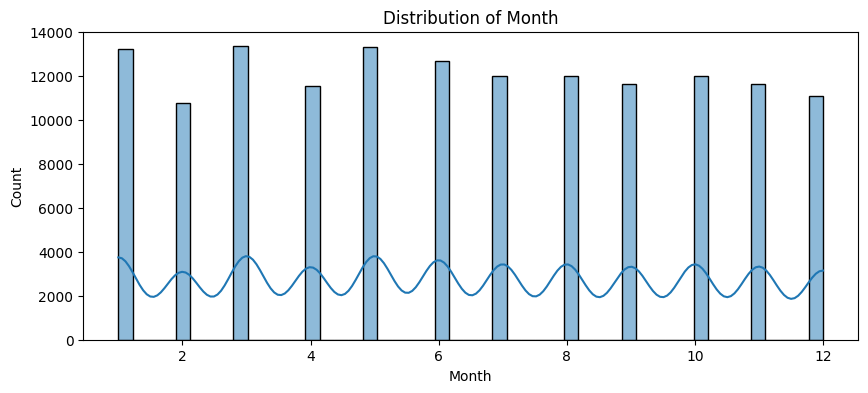

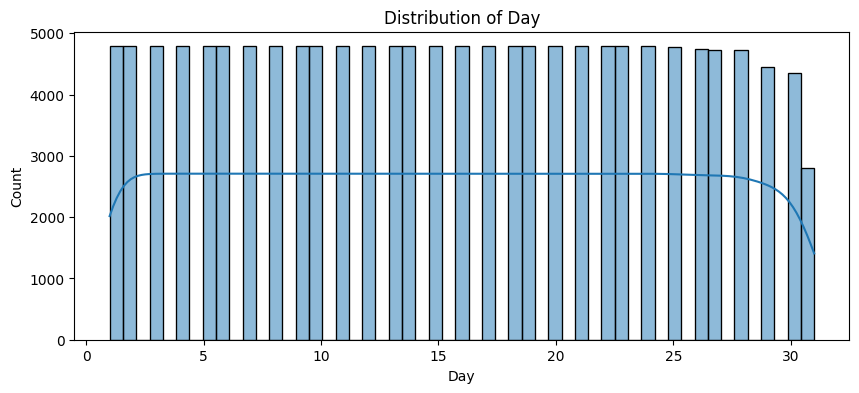

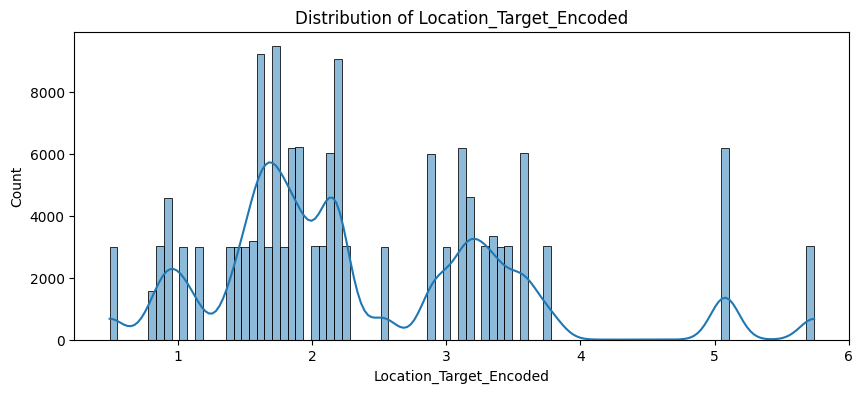

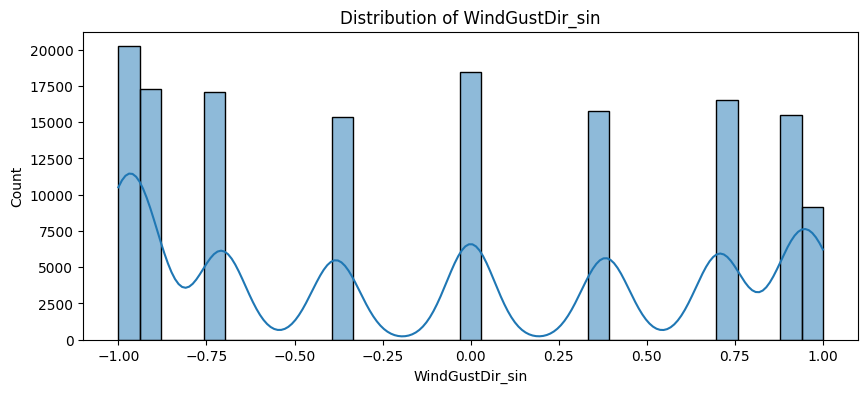

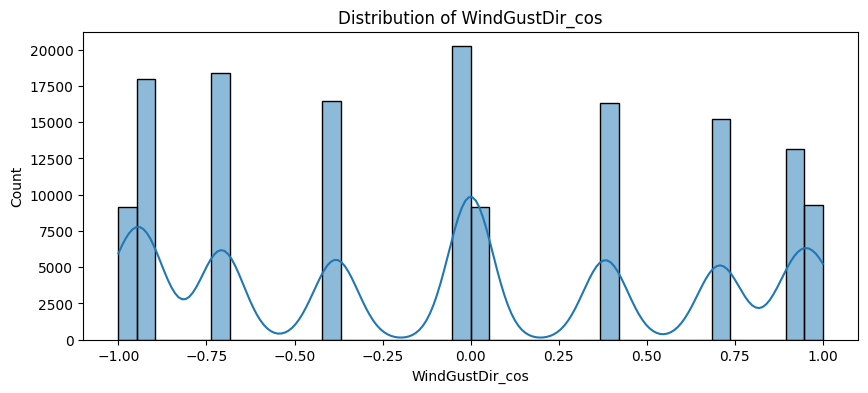

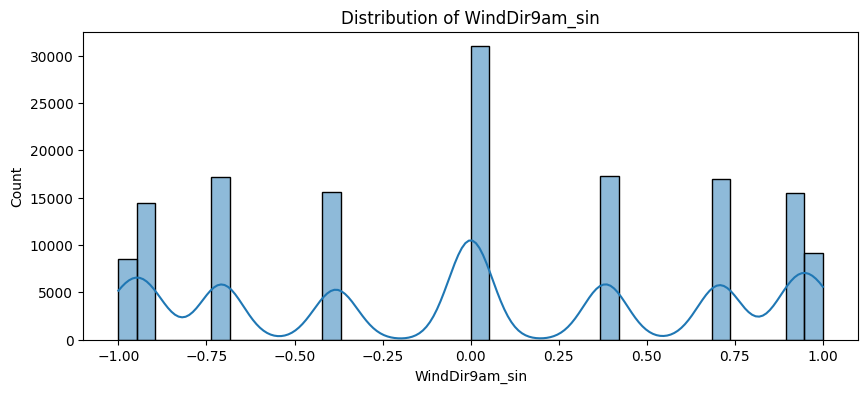

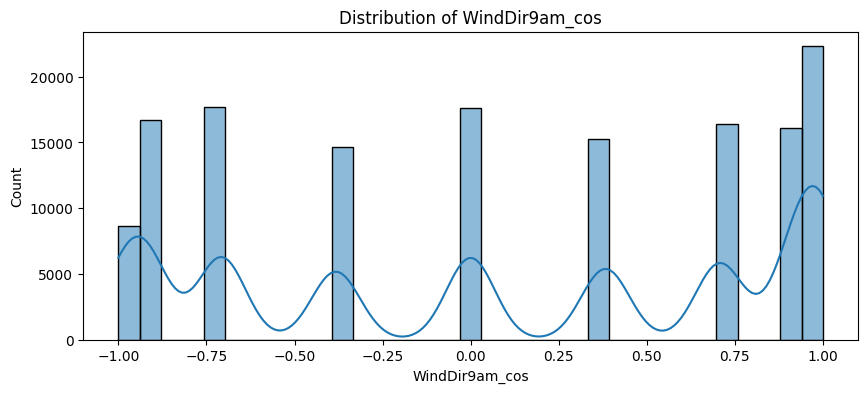

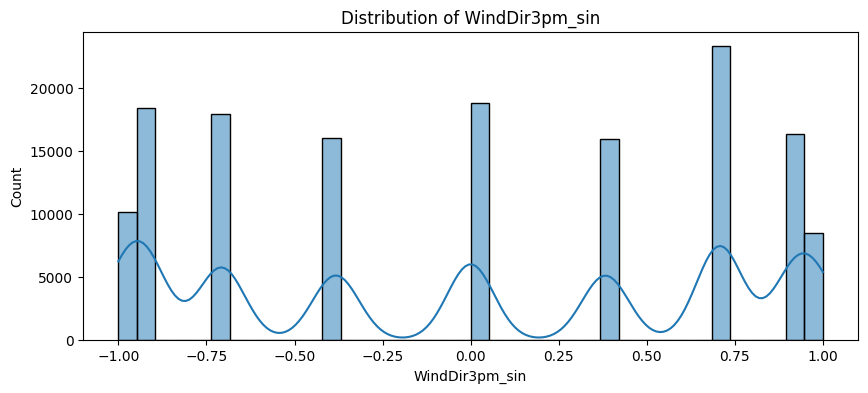

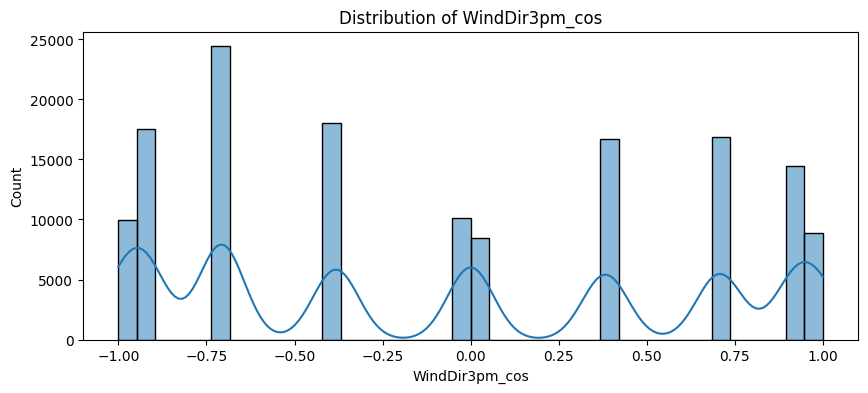

Skewness of numerical variables:
 MinTemp                    0.021188
MaxTemp                    0.220837
Rainfall                   9.836121
Evaporation                3.761218
Sunshine                  -0.496470
WindGustSpeed              0.874869
WindSpeed9am               0.777621
WindSpeed3pm               0.628209
Humidity9am               -0.483964
Humidity3pm                0.033614
Pressure9am               -0.095523
Pressure3pm               -0.045621
Cloud9am                  -0.229078
Cloud3pm                  -0.226380
Temp9am                    0.088539
Temp3pm                    0.237958
Year                      -0.049356
Month                      0.030343
Day                        0.009040
Location_Target_Encoded    0.974372
WindGustDir_sin            0.144901
WindGustDir_cos            0.093682
WindDir9am_sin            -0.030953
WindDir9am_cos            -0.130828
WindDir3pm_sin            -0.033396
WindDir3pm_cos             0.162799
dtype: float64
Shapiro-Wilk Te

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, shapiro


numerical_cols = df.select_dtypes(include=[np.number]).columns

# 1. Plot histograms and KDE
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()
# 2. Check skewness
skewness = df[numerical_cols].apply(lambda x: skew(x.dropna()))
print("Skewness of numerical variables:\n", skewness)
# 3. Use Shapiro-Wilk test for normality check
for col in numerical_cols:
    stat, p = shapiro(df[col].dropna())
    print(f'Shapiro-Wilk Test for {col}: p-value = {p}')
    if p > 0.05:
        print(f'{col} is likely normally distributed (p > 0.05)\n')
    else:
        print(f'{col} is likely skewed (p <= 0.05)\n')


In [ ]:
# Variables to impute using mean
mean_impute_cols = [ 'MinTemp', 'MaxTemp', 'Sunshine', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                    'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

# Variables to impute using median
median_impute_cols = ['Rainfall', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']

# Impute using mean
df[mean_impute_cols] = df[mean_impute_cols].fillna(df[mean_impute_cols].mean())

# Impute using median
df[median_impute_cols] = df[median_impute_cols].fillna(df[median_impute_cols].median())


In [ ]:
df[numerical].isnull().sum() # check missing values

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0


## Outliers

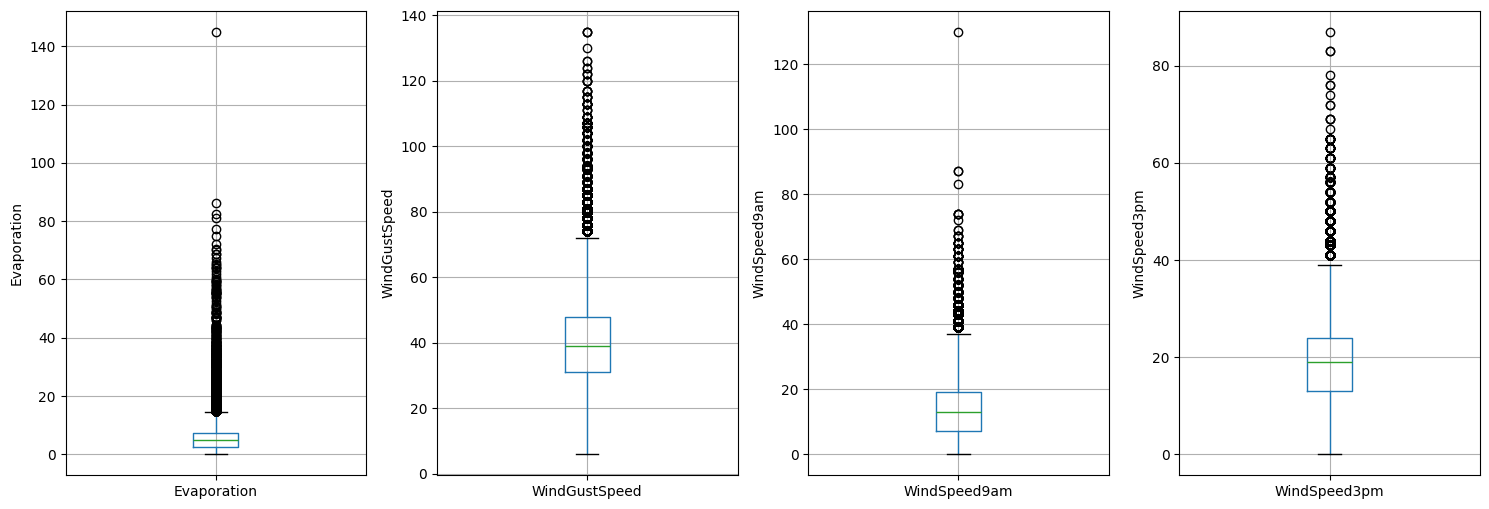

In [ ]:
plt.figure(figsize=(15,10))

# Plot for Evaporation
plt.subplot(2, 4, 1)
fig = df.boxplot(column='Evaporation')
fig.set_title('')
fig.set_ylabel('Evaporation')

# Plot for WindGustSpeed
plt.subplot(2, 4, 2)
fig = df.boxplot(column='WindGustSpeed')
fig.set_title('')
fig.set_ylabel('WindGustSpeed')

# Plot for WindSpeed9am
plt.subplot(2, 4, 3)
fig = df.boxplot(column='WindSpeed9am')
fig.set_title('')
fig.set_ylabel('WindSpeed9am')

# Plot for WindSpeed3pm
plt.subplot(2, 4, 4)
fig = df.boxplot(column='WindSpeed3pm')
fig.set_title('')
fig.set_ylabel('WindSpeed3pm')

# Adjust layout for spacing
plt.tight_layout()
plt.show()

In [ ]:
variables = ['Evaporation', 'WindGustSpeed','WindSpeed9am', 'WindSpeed3pm']

# Loop through each variable and calculate IQR, lower, and upper fences
for var in variables:
    IQR = df[var].quantile(0.75) - df[var].quantile(0.25)
    Lower_fence = df[var].quantile(0.25) - (IQR * 3)  # k = 3 for extreme outliers
    Upper_fence = df[var].quantile(0.75) + (IQR * 3)

    print(f'{var} outliers are values < {Lower_fence:.2f} or > {Upper_fence:.2f}')

Evaporation outliers are values < -11.80 or > 21.80
WindGustSpeed outliers are values < -20.00 or > 99.00
WindSpeed9am outliers are values < -29.00 or > 55.00
WindSpeed3pm outliers are values < -20.00 or > 57.00


In [ ]:
# Define the top-coding function
def top_code(df, col, upper_bound):
    # Cap values above upper_bound to upper_bound
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

# Apply top-coding to each variable based on the provided upper thresholds

df = top_code(df, 'Evaporation', 21.80)
df = top_code(df, 'WindGustSpeed', 99.00)
df = top_code(df, 'WindSpeed9am', 55.00)
df = top_code(df, 'WindSpeed3pm', 57.00)

# Display the updated dataframe summary to check the results
print(df[[ 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']].describe())


        Evaporation  WindGustSpeed   WindSpeed9am   WindSpeed3pm
count  82670.000000  135197.000000  143693.000000  142398.000000
mean       5.402322      40.026184      14.038819      18.658668
std        3.699553      13.562678       8.889041       8.789758
min        0.000000       6.000000       0.000000       0.000000
25%        2.600000      31.000000       7.000000      13.000000
50%        4.800000      39.000000      13.000000      19.000000
75%        7.400000      48.000000      19.000000      24.000000
max       21.800000      99.000000      55.000000      57.000000


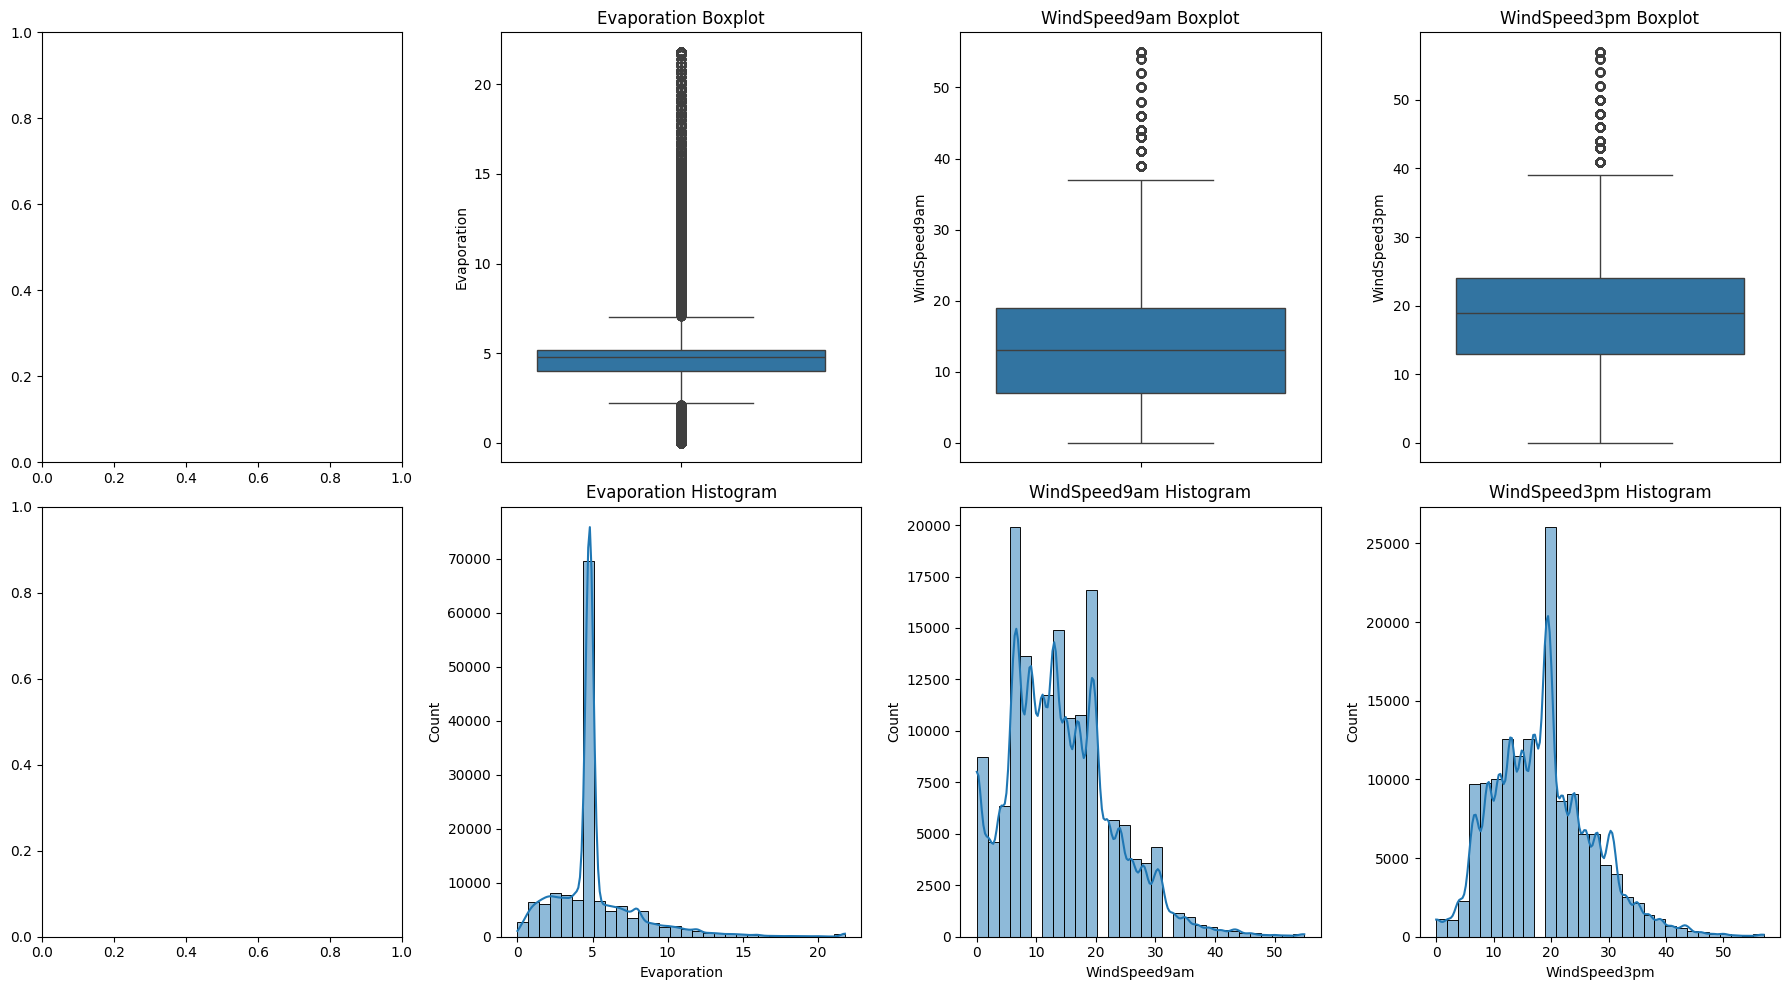

In [ ]:
# Set up the plotting area
fig, axs = plt.subplots(2, 4, figsize=(18, 10))

# Plot boxplot for each variable

sns.boxplot(y='Evaporation', data=df, ax=axs[0, 1])
sns.boxplot(y='WindSpeed9am', data=df, ax=axs[0, 2])
sns.boxplot(y='WindSpeed3pm', data=df, ax=axs[0, 3])

# Plot histogram for each variable

sns.histplot(df['Evaporation'], bins=30, kde=True, ax=axs[1, 1])
sns.histplot(df['WindSpeed9am'], bins=30, kde=True, ax=axs[1, 2])
sns.histplot(df['WindSpeed3pm'], bins=30, kde=True, ax=axs[1, 3])

# Set titles for each plot

axs[0, 1].set_title('Evaporation Boxplot')
axs[0, 2].set_title('WindSpeed9am Boxplot')
axs[0, 3].set_title('WindSpeed3pm Boxplot')


axs[1, 1].set_title('Evaporation Histogram')
axs[1, 2].set_title('WindSpeed9am Histogram')
axs[1, 3].set_title('WindSpeed3pm Histogram')

# Adjust layout
plt.tight_layout()
plt.show()


## Set 'Rainfall' into categorgy

In [ ]:
# Define updated bins and labels
bins = [0, 5, 20, 50, float('inf')] # the last bin to include all rainfall > 50mm
labels = ['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']

# Add a new column to df with binned categories
df['Rainfall_Category'] = pd.cut(df['Rainfall'], bins=bins, labels=labels, right=False)

# Check the distribution of each category
rainfall_category_counts = df['Rainfall_Category'].value_counts()
print("Rainfall Category Distribution:\n", rainfall_category_counts)

# Calculate proportions of each category
rainfall_category_proportions = df['Rainfall_Category'].value_counts(normalize=True) * 100
print("Rainfall Category Proportions (%):\n", rainfall_category_proportions)

Rainfall Category Distribution:
 Rainfall_Category
No Rain            128899
Moderate Rain       12478
Heavy Rain           3275
Very Heavy Rain       808
Name: count, dtype: int64
Rainfall Category Proportions (%):
 Rainfall_Category
No Rain            88.614739
Moderate Rain       8.578303
Heavy Rain          2.251478
Very Heavy Rain     0.555479
Name: proportion, dtype: float64


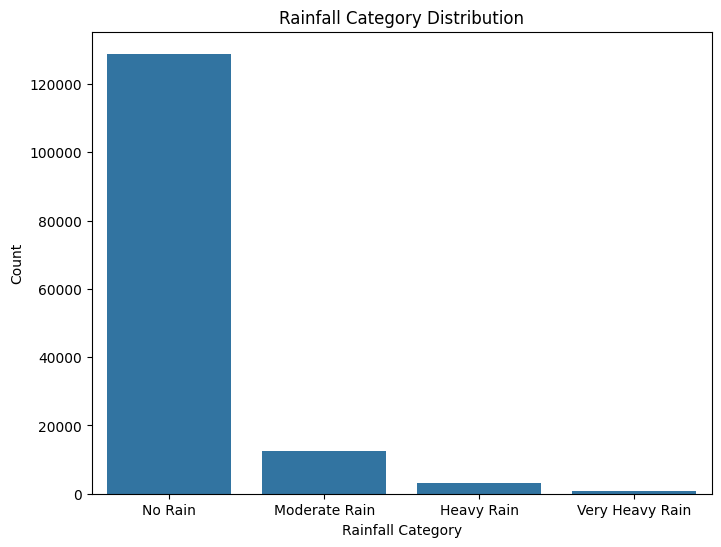

In [ ]:
# Bar plot to visualize the proportion of each rainfall category
plt.figure(figsize=(8,6))
sns.countplot(x='Rainfall_Category', data=df, order=labels)
plt.title('Rainfall Category Distribution')
plt.xlabel('Rainfall Category')
plt.ylabel('Count')
plt.show()

In [ ]:
# Ensure that y contains the categorical labels, not encoded as integers
X = df.drop(columns=['Rainfall_Category'])  # Drop only 'Rainfall_Category' if it's in df
y = df['Rainfall_Category']  # Use categorical labels directly for resampling

In [ ]:
# Check for NaN values in each column
nan_summary = X.isna().sum()

# Display only columns that contain NaN values
nan_columns = nan_summary[nan_summary > 0]
print("Columns with NaN values and their counts:\n", nan_columns)


Columns with NaN values and their counts:
 Series([], dtype: int64)


In [ ]:
# Display rows that contain any NaN values
rows_with_nan = X[X.isna().any(axis=1)]
print("Rows with NaN values:\n", rows_with_nan)


Rows with NaN values:
 Empty DataFrame
Columns: [MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, Year, Month, Day, Location_Target_Encoded, WindGustDir_sin, WindGustDir_cos, WindDir9am_sin, WindDir9am_cos, WindDir3pm_sin, WindDir3pm_cos]
Index: []

[0 rows x 26 columns]


In [ ]:
# Remove rows with NaN values
X_cleaned = X.dropna()
y_cleaned = y[X_cleaned.index]  # Ensure y is aligned with X after dropping rows

# Verify if there are any remaining NaN values
print("Remaining NaN values in X:", X_cleaned.isna().sum().sum())
print("Remaining NaN values in y:", y_cleaned.isna().sum().sum())


Remaining NaN values in X: 0
Remaining NaN values in y: 0


undersampling and SMOTE:

In [ ]:
#  Original class distribution
original_class_counts = Counter(y)
print("Original Class Distribution:", original_class_counts)

# Adjust sampling
undersample_strategy = {'No Rain': 13000}
oversample_strategy = {
    'Moderate Rain': max(13000, original_class_counts['Moderate Rain']),
    'Heavy Rain': max(13000, original_class_counts['Heavy Rain']),
    'Very Heavy Rain': max(13000, original_class_counts['Very Heavy Rain']),
}

# Define the pipeline
under_sampler = RandomUnderSampler(sampling_strategy=undersample_strategy, random_state=42)
smote = SMOTE(sampling_strategy=oversample_strategy, random_state=42)


Original Class Distribution: Counter({'No Rain': 128899, 'Moderate Rain': 12478, 'Heavy Rain': 3275, 'Very Heavy Rain': 808})


Resampled Class Distribution: Counter({'Heavy Rain': 13000, 'Moderate Rain': 13000, 'No Rain': 13000, 'Very Heavy Rain': 13000})


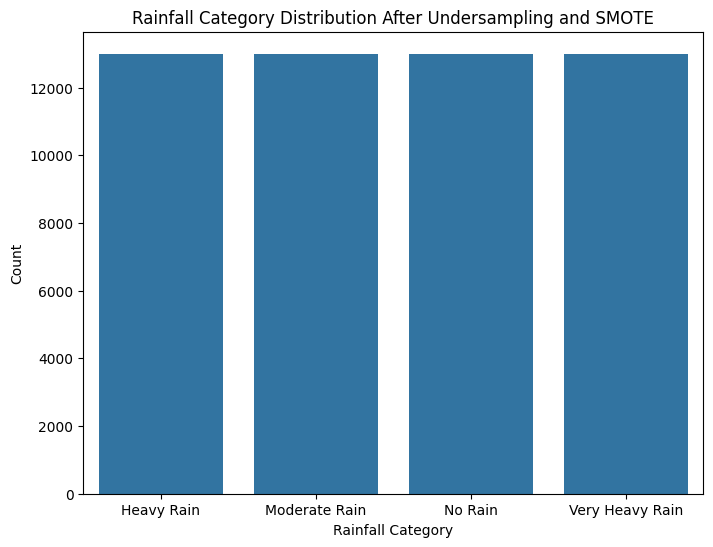

In [ ]:
pipeline = Pipeline(steps=[('under', under_sampler), ('smote', smote)])

# Apply the pipeline
X_resampled, y_resampled = pipeline.fit_resample(X, y)

# Combine resampled data into a new DataFrame
df_resampled = pd.DataFrame(X_resampled)  # Replace `X_resampled` with a DataFrame
df_resampled['Rainfall_Category'] = y_resampled  # Add the target column

# Check the new distribution
resampled_class_counts = Counter(y_resampled)
print("Resampled Class Distribution:", resampled_class_counts)

# Bar plot to visualize the new distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Rainfall_Category', data=df_resampled, order=sorted(df_resampled['Rainfall_Category'].unique()))
plt.title('Rainfall Category Distribution After Undersampling and SMOTE')
plt.xlabel('Rainfall Category')
plt.ylabel('Count')
plt.show()


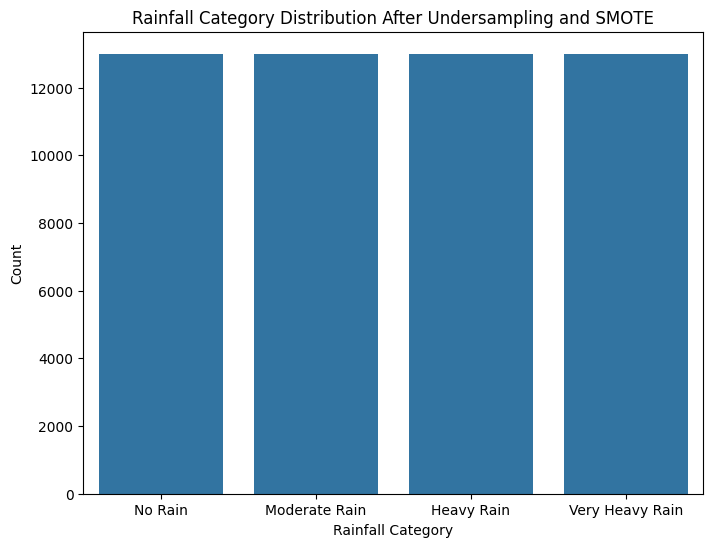

In [ ]:
# Define the desired order for the x-axis
desired_order = ['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']

# Bar plot to visualize the new distribution
plt.figure(figsize=(8, 6))
sns.countplot(
    x='Rainfall_Category',
    data=df_resampled,
    order=desired_order  # Use the desired order
)
plt.title('Rainfall Category Distribution After Undersampling and SMOTE')
plt.xlabel('Rainfall Category')
plt.ylabel('Count')
plt.show()


One hot encoding

In [ ]:
# Original class distribution
original_class_counts = Counter(y)
print("Original Class Distribution:", original_class_counts)

# sampling strategies
undersample_strategy = {'No Rain': 13000}  # Reduce 'No Rain' to 10,000 samples
oversample_strategy = {
    'Moderate Rain': max(13000, original_class_counts['Moderate Rain']),  # Ensure >= original count
    'Heavy Rain': max(13000, original_class_counts['Heavy Rain']),
    'Very Heavy Rain': max(13000, original_class_counts['Very Heavy Rain']),
}

# Define the pipeline
under_sampler = RandomUnderSampler(sampling_strategy=undersample_strategy, random_state=42)
smote = SMOTE(sampling_strategy=oversample_strategy, random_state=42)
pipeline = Pipeline(steps=[('under', under_sampler), ('smote', smote)])
# Apply the pipeline
X_resampled, y_resampled = pipeline.fit_resample(X, y)
# Combine resampled data into a new DataFrame
df_resampled = pd.DataFrame(X_resampled)  # Replace `X_resampled` with a DataFrame
df_resampled['Rainfall_Category'] = y_resampled  # Add the target column

# Check the new distribution
resampled_class_counts = Counter(y_resampled)
print("Resampled Class Distribution:", resampled_class_counts)


# One-Hot Encode the 'Rainfall_Category'
one_hot_encoder = OneHotEncoder(sparse_output=False, drop=None)
encoded_columns = one_hot_encoder.fit_transform(df_resampled[['Rainfall_Category']])
encoded_df = pd.DataFrame(encoded_columns, columns=one_hot_encoder.get_feature_names_out(['Rainfall_Category']))
# Concatenate the encoded columns with the resampled DataFrame
df_resampled = pd.concat([df_resampled.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
# Drop the original 'Rainfall_Category' column
df_resampled.drop('Rainfall_Category', axis=1, inplace=True)

In [ ]:

# One-Hot Encode the 'Rainfall_Category' column in the resampled DataFrame
one_hot_encoder = OneHotEncoder(sparse_output=False, drop=None)
encoded_columns = one_hot_encoder.fit_transform(df_resampled[['Rainfall_Category']])
encoded_df = pd.DataFrame(encoded_columns, columns=one_hot_encoder.get_feature_names_out(['Rainfall_Category']))

# Concatenate the encoded columns with the resampled DataFrame
df_resampled = pd.concat([df_resampled.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

In [ ]:
# Drop the original 'Rainfall_Category' column
df_resampled.drop('Rainfall_Category', axis=1, inplace=True)


   MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0     12.9     15.8      20.0          4.8  7.611178           70.0   
1      8.6     12.9      21.0          4.8  7.611178           63.0   
2      9.3     16.8      28.8          4.8  7.611178           56.0   
3     18.3     28.3      25.8          4.8  7.611178           61.0   
4     18.8     30.3      20.6          4.8  7.611178           39.0   

   WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...  WindGustDir_sin  \
0          19.0          15.0         83.0         89.0  ...        -1.000000   
1          26.0          31.0         77.0         62.0  ...        -0.382683   
2          26.0          30.0         82.0         54.0  ...        -1.000000   
3           0.0          46.0         98.0         67.0  ...        -0.382683   
4           9.0           7.0         87.0         48.0  ...        -0.923880   

   WindGustDir_cos  WindDir9am_sin  WindDir9am_cos  WindDir3pm_sin  \
0    -1.836970e-

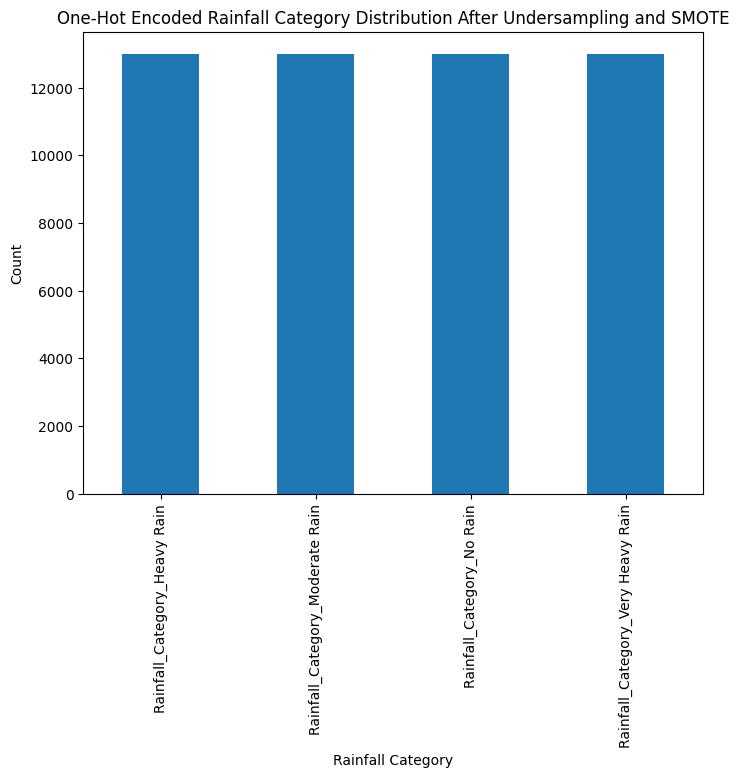

In [ ]:
# Display the first few rows of the resampled and encoded DataFrame
print(df_resampled.head())

# Check the distribution of one-hot encoded columns to confirm balance
encoded_category_distribution = df_resampled[one_hot_encoder.get_feature_names_out(['Rainfall_Category'])].sum()
print("\nOne-Hot Encoded Rainfall Category Distribution After Resampling:\n", encoded_category_distribution)

# Plot the distribution of the one-hot encoded categories
plt.figure(figsize=(8,6))
encoded_category_distribution.plot(kind='bar')
plt.title('One-Hot Encoded Rainfall Category Distribution After Undersampling and SMOTE')
plt.xlabel('Rainfall Category')
plt.ylabel('Count')
plt.show()

In [ ]:
# Drop the Rainfall column from df_resampled
df_resampled = df_resampled.drop(columns=['Rainfall'])

# Verify that the column is removed
print("Columns after dropping 'Rainfall':\n", df_resampled.columns)


Columns after dropping 'Rainfall':
 Index(['MinTemp', 'MaxTemp', 'Evaporation', 'Sunshine', 'WindGustSpeed',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'Year', 'Month', 'Day', 'Location_Target_Encoded',
       'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin',
       'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos',
       'Rainfall_Category_Heavy Rain', 'Rainfall_Category_Moderate Rain',
       'Rainfall_Category_No Rain', 'Rainfall_Category_Very Heavy Rain'],
      dtype='object')


# Feature analysis

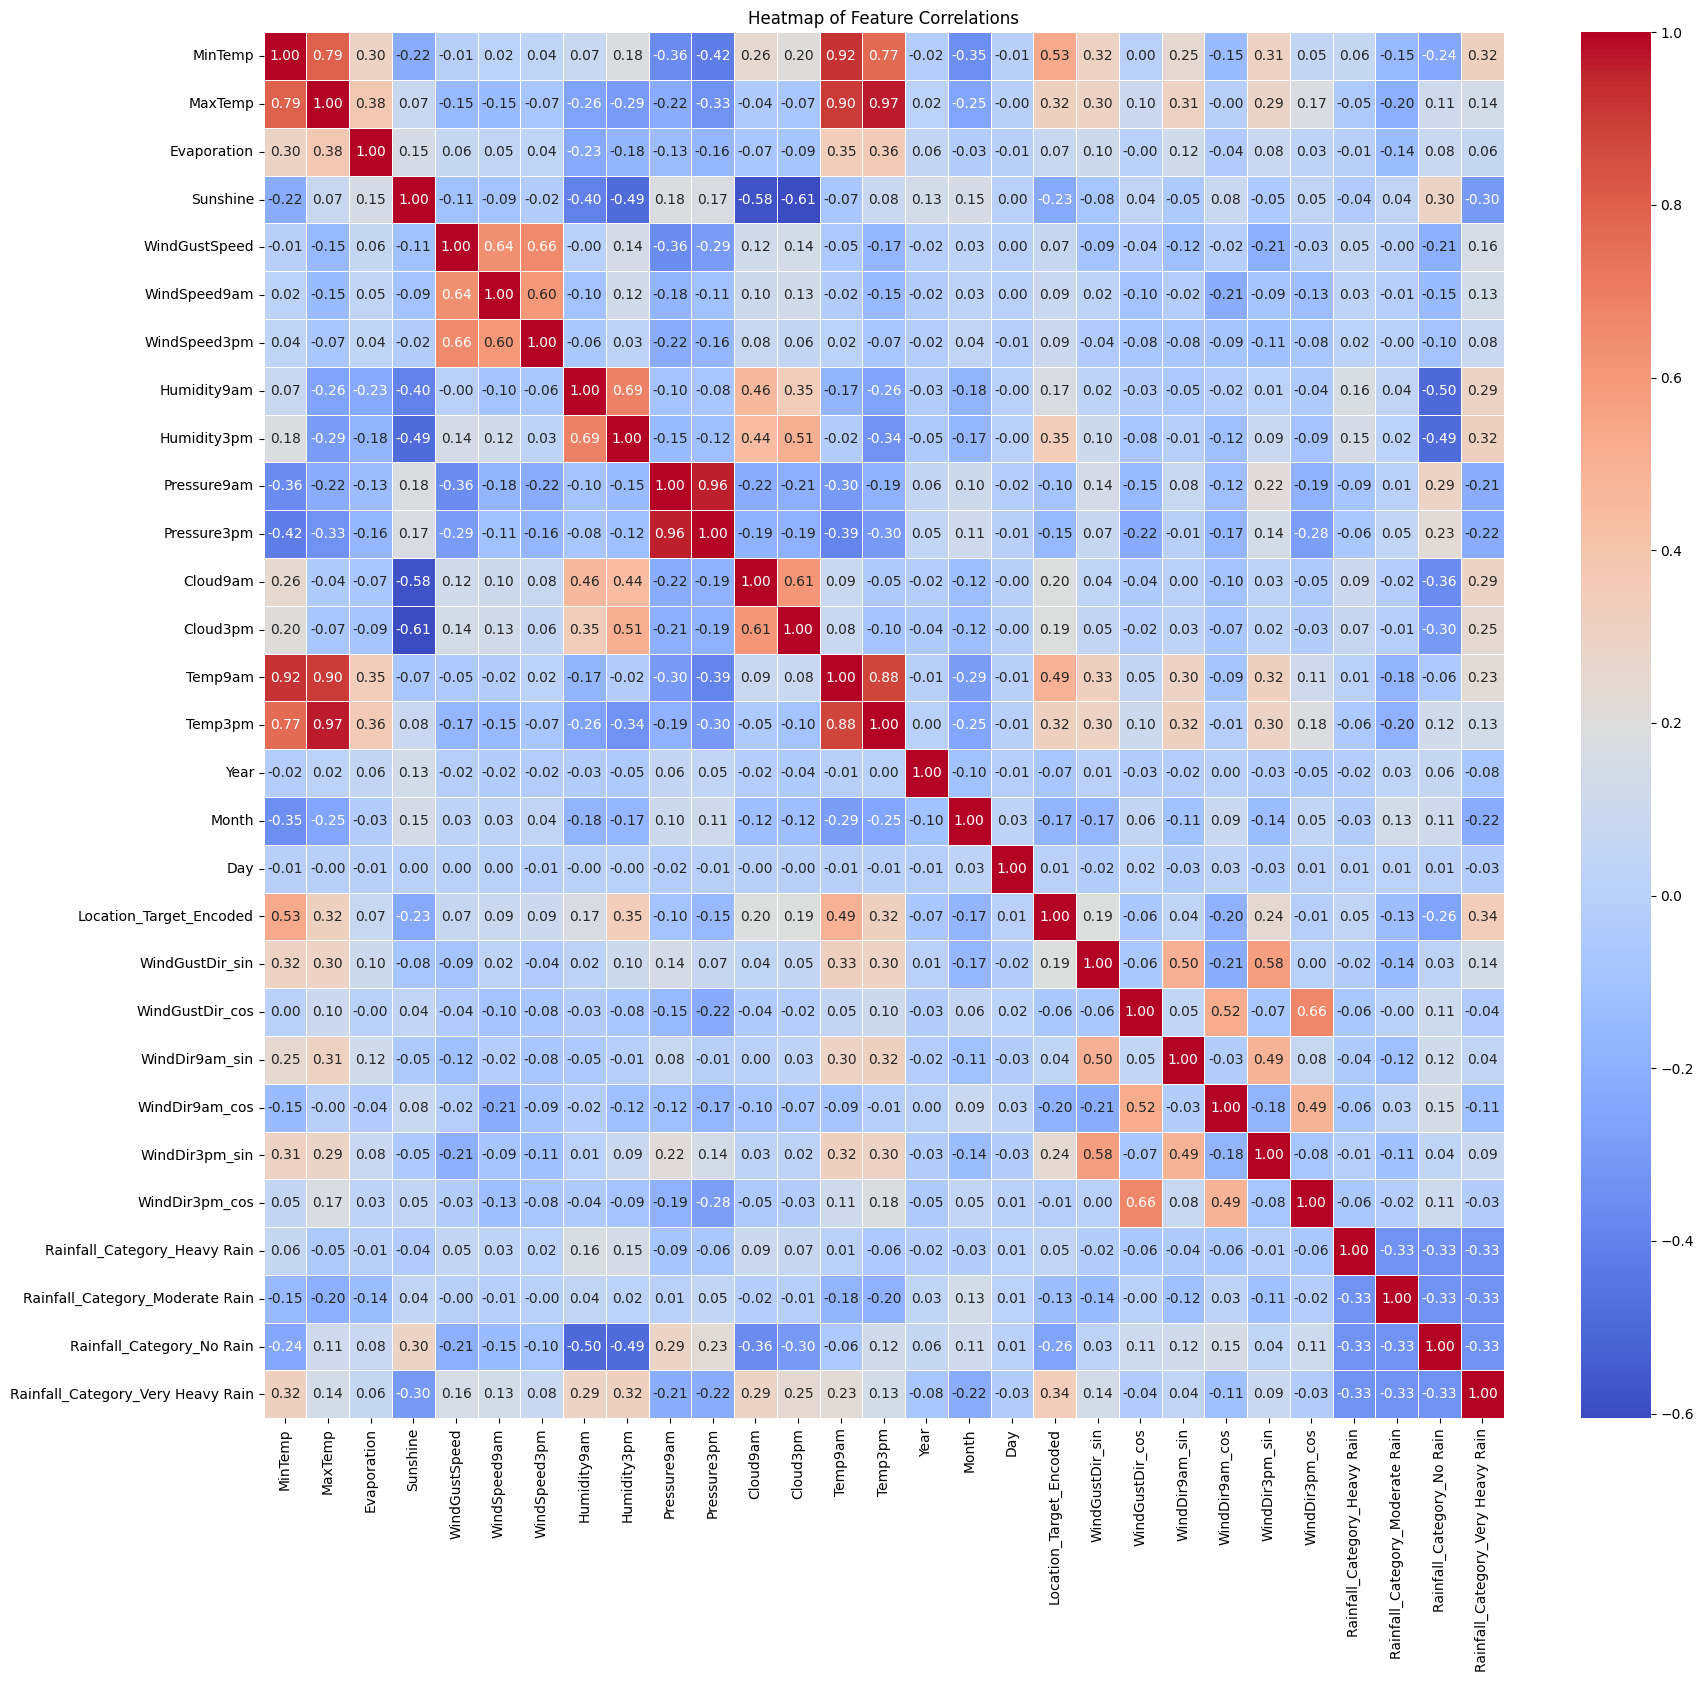

In [ ]:
# Step 1: Calculate and Plot Correlation Matrix
correlation_matrix = df_resampled.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap of Feature Correlations')
plt.show()

In [ ]:
# Step 2: Feature Importance Analysis with Random Forest
# Define features and target
X = df_resampled.drop(columns=one_hot_encoder.get_feature_names_out(['Rainfall_Category']).tolist())
y = df_resampled[one_hot_encoder.get_feature_names_out(['Rainfall_Category'])[0]]  # Example target column


In [ ]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Get feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)


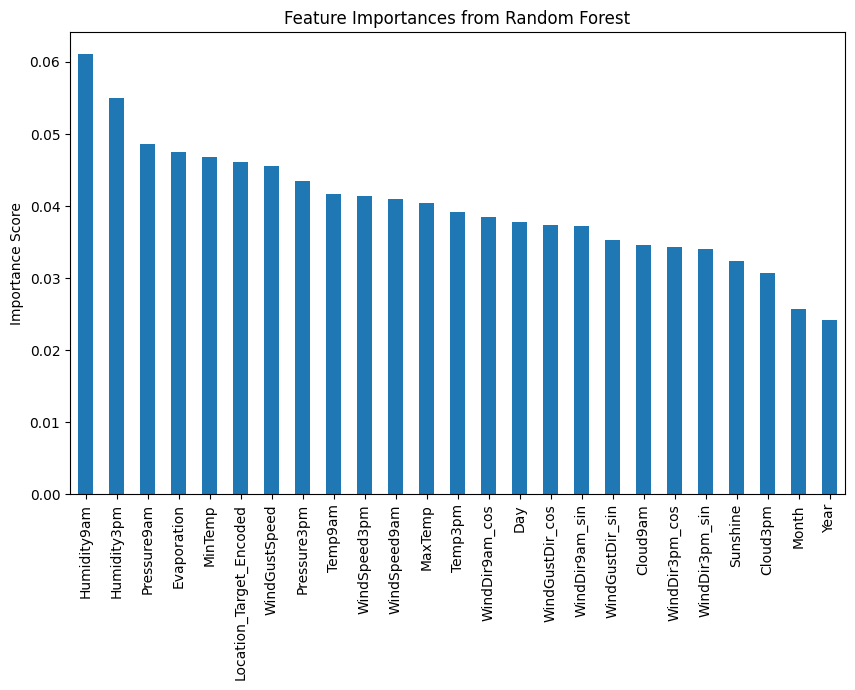

In [ ]:
# Sort and plot the feature importances
feature_importances = feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importances from Random Forest')
plt.ylabel('Importance Score')
plt.show()


** top correlated features for each rainfall category:**

In [ ]:

# Calculate the correlation matrix
correlation_matrix = df_resampled.corr()

# Define the rainfall categories
rainfall_categories = [
    'Rainfall_Category_Heavy Rain',
    'Rainfall_Category_Moderate Rain',
    'Rainfall_Category_No Rain',
    'Rainfall_Category_Very Heavy Rain'
]

# Find and display the top 5 correlated features for each rainfall category
top_correlations = {}
for category in rainfall_categories:
    # Sort the correlation values for each category in descending order
    sorted_correlations = correlation_matrix[category].sort_values(ascending=False)
    # Exclude the first entry (correlation of the category with itself, which is 1)
    top_correlations[category] = sorted_correlations[1:6]  # Top 5 most correlated features

# Display the top correlated features for each rainfall category
for category, correlations in top_correlations.items():
    print(f"Top correlated features for {category}:\n{correlations}\n")


Top correlated features for Rainfall_Category_Heavy Rain:
Humidity9am    0.160337
Humidity3pm    0.151867
Cloud9am       0.092591
Cloud3pm       0.065773
MinTemp        0.063533
Name: Rainfall_Category_Heavy Rain, dtype: float64

Top correlated features for Rainfall_Category_Moderate Rain:
Month          0.132912
Pressure3pm    0.051571
Humidity9am    0.044163
Sunshine       0.041396
Year           0.034992
Name: Rainfall_Category_Moderate Rain, dtype: float64

Top correlated features for Rainfall_Category_No Rain:
Sunshine          0.297505
Pressure9am       0.293172
Pressure3pm       0.230137
WindDir9am_cos    0.147435
WindDir9am_sin    0.121552
Name: Rainfall_Category_No Rain, dtype: float64

Top correlated features for Rainfall_Category_Very Heavy Rain:
Location_Target_Encoded    0.344510
MinTemp                    0.323059
Humidity3pm                0.316837
Cloud9am                   0.292495
Humidity9am                0.292177
Name: Rainfall_Category_Very Heavy Rain, dtype: floa

In [ ]:
#Save the modified DataFrame to a new CSV file
#df.to_csv('cleaned_rainfall_data(newencode).csv', index=False)

#print("The cleaned DataFrame with the 'Rainfall_Category' column has been saved as 'cleaned_rainfall_data.csv'.")


# new feature engneering

In [ ]:
# Temperature and Humidity Combinations
df_resampled['DewPointEstimate'] = df_resampled['MinTemp'] * (df_resampled['Humidity9am'] / 100)  # Rough estimate of dew point based on min temp and humidity
df_resampled['AvgHumidity'] = (df_resampled['Humidity9am'] + df_resampled['Humidity3pm']) / 2
df_resampled['AvgTemperature'] = (df_resampled['MinTemp'] + df_resampled['MaxTemp']) / 2

# Temperature and Sunshine Interactions
df_resampled['TempRange'] = df_resampled['MaxTemp'] - df_resampled['MinTemp']
df_resampled['TempSunshineInteraction'] = df_resampled['MaxTemp'] * df_resampled['Sunshine']

#  Time-Based Features
def get_season(month):
    if month in [6, 7, 8]:
        return 'Winter'
    elif month in [9, 10, 11]:
        return 'Spring'
    elif month in [12, 1, 2]:
        return 'Summer'
    else:
        return 'Fall'

df_resampled['Season'] = df_resampled['Month'].apply(get_season)
# Encoding the Season feature using one-hot encoding
df_resampled = pd.get_dummies(df_resampled, columns=['Season'], drop_first=True)

# Pressure Differences
df_resampled['PressureDifference'] = df_resampled['Pressure3pm'] - df_resampled['Pressure9am']
# Cloud Differences
df_resampled['CloudDifference'] = df_resampled['Cloud3pm'] - df_resampled['Cloud9am']
# Temp Differences
df_resampled['TempDifference'] = df_resampled['Temp3pm'] - df_resampled['Temp9am']

# Print the first few rows of the DataFrame to see the new features
print(df_resampled.head())


   MinTemp  MaxTemp  Evaporation  Sunshine  WindGustSpeed  WindSpeed9am  \
0     12.9     15.8          4.8  7.611178           70.0          19.0   
1      8.6     12.9          4.8  7.611178           63.0          26.0   
2      9.3     16.8          4.8  7.611178           56.0          26.0   
3     18.3     28.3          4.8  7.611178           61.0           0.0   
4     18.8     30.3          4.8  7.611178           39.0           9.0   

   WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  ...  AvgTemperature  \
0          15.0         83.0         89.0       1004.8  ...           14.35   
1          31.0         77.0         62.0       1004.0  ...           10.75   
2          30.0         82.0         54.0        997.8  ...           13.05   
3          46.0         98.0         67.0       1003.7  ...           23.30   
4           7.0         87.0         48.0       1010.0  ...           24.55   

   TempRange  TempSunshineInteraction  Season_Spring  Season_Summer  \
0  

In [ ]:
df_resampled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   MinTemp                            52000 non-null  float64
 1   MaxTemp                            52000 non-null  float64
 2   Evaporation                        52000 non-null  float64
 3   Sunshine                           52000 non-null  float64
 4   WindGustSpeed                      52000 non-null  float64
 5   WindSpeed9am                       52000 non-null  float64
 6   WindSpeed3pm                       52000 non-null  float64
 7   Humidity9am                        52000 non-null  float64
 8   Humidity3pm                        52000 non-null  float64
 9   Pressure9am                        52000 non-null  float64
 10  Pressure3pm                        52000 non-null  float64
 11  Cloud9am                           52000 non-null  flo

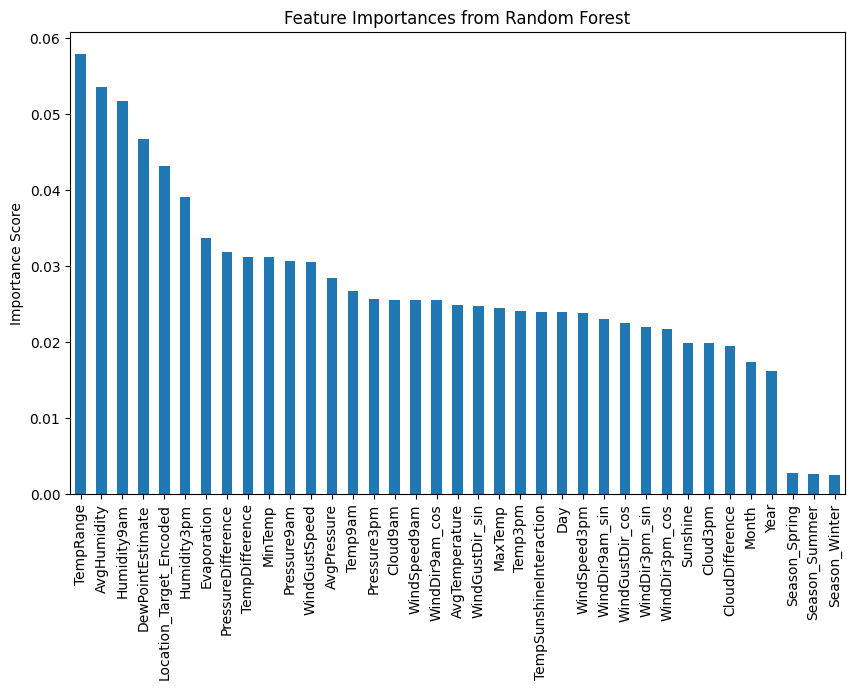

In [ ]:
# Define features and labels for model training
X = df_resampled.drop(columns=one_hot_encoder.get_feature_names_out(['Rainfall_Category']).tolist())

# Define the target variable as the class with the highest probability
y = df_resampled[one_hot_encoder.get_feature_names_out(['Rainfall_Category']).tolist()].idxmax(axis=1)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Get feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort and plot the feature importances
feature_importances = feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importances from Random Forest')
plt.ylabel('Importance Score')
plt.show()




Reasons to Keep Month
Seasonal Influence: If rainfall patterns are seasonal in your region, with distinct wet and dry months, Month could provide predictive value.
Capturing Cyclic Patterns: Month might help the model recognize cyclical trends, as certain months may consistently have more or less rainfall.
Domain Knowledge: In some regions, climate patterns are closely tied to specific months, and Month could serve as a useful proxy for these patterns.

## Drop more

In [ ]:
# Drop low-importance features
features_to_drop = ['Clouddifference', 'Season'.....]

 3   Sunshine
 11  Cloud9am
 12  Cloud3pm
 15  Year
 19  WindGustDir_sin
 20  WindGustDir_cos
 21  WindDir9am_sin
 22  WindDir9am_cos
 23  WindDir3pm_sin
 34  Season_Spring
 35  Season_Summer
 36  Season_Winter
 38  AvgPressure
 39  CloudDifference


Remaining columns in df_resampled:
 Index(['MinTemp', 'MaxTemp', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Temp9am', 'Temp3pm', 'Month', 'Day',
       'Location_Target_Encoded', 'Rainfall_Category_Heavy Rain',
       'Rainfall_Category_Moderate Rain', 'Rainfall_Category_No Rain',
       'Rainfall_Category_Very Heavy Rain', 'DewPointEstimate', 'AvgHumidity',
       'AvgTemperature', 'TempRange', 'TempSunshineInteraction',
       'PressureDifference', 'TempDifference'],
      dtype='object')


In [ ]:
df_resampled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 26 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   MinTemp                            52000 non-null  float64
 1   MaxTemp                            52000 non-null  float64
 2   Evaporation                        52000 non-null  float64
 3   WindGustSpeed                      52000 non-null  float64
 4   WindSpeed9am                       52000 non-null  float64
 5   WindSpeed3pm                       52000 non-null  float64
 6   Humidity9am                        52000 non-null  float64
 7   Humidity3pm                        52000 non-null  float64
 8   Pressure9am                        52000 non-null  float64
 9   Pressure3pm                        52000 non-null  float64
 10  Temp9am                            52000 non-null  float64
 11  Temp3pm                            52000 non-null  flo

In [ ]:
existing_features_to_drop = [col for col in features_to_drop if col in df_resampled.columns]
print("Columns that exist in df_resampled and were attempted to be dropped:", existing_features_to_drop)


Columns that exist in df_resampled and were attempted to be dropped: []


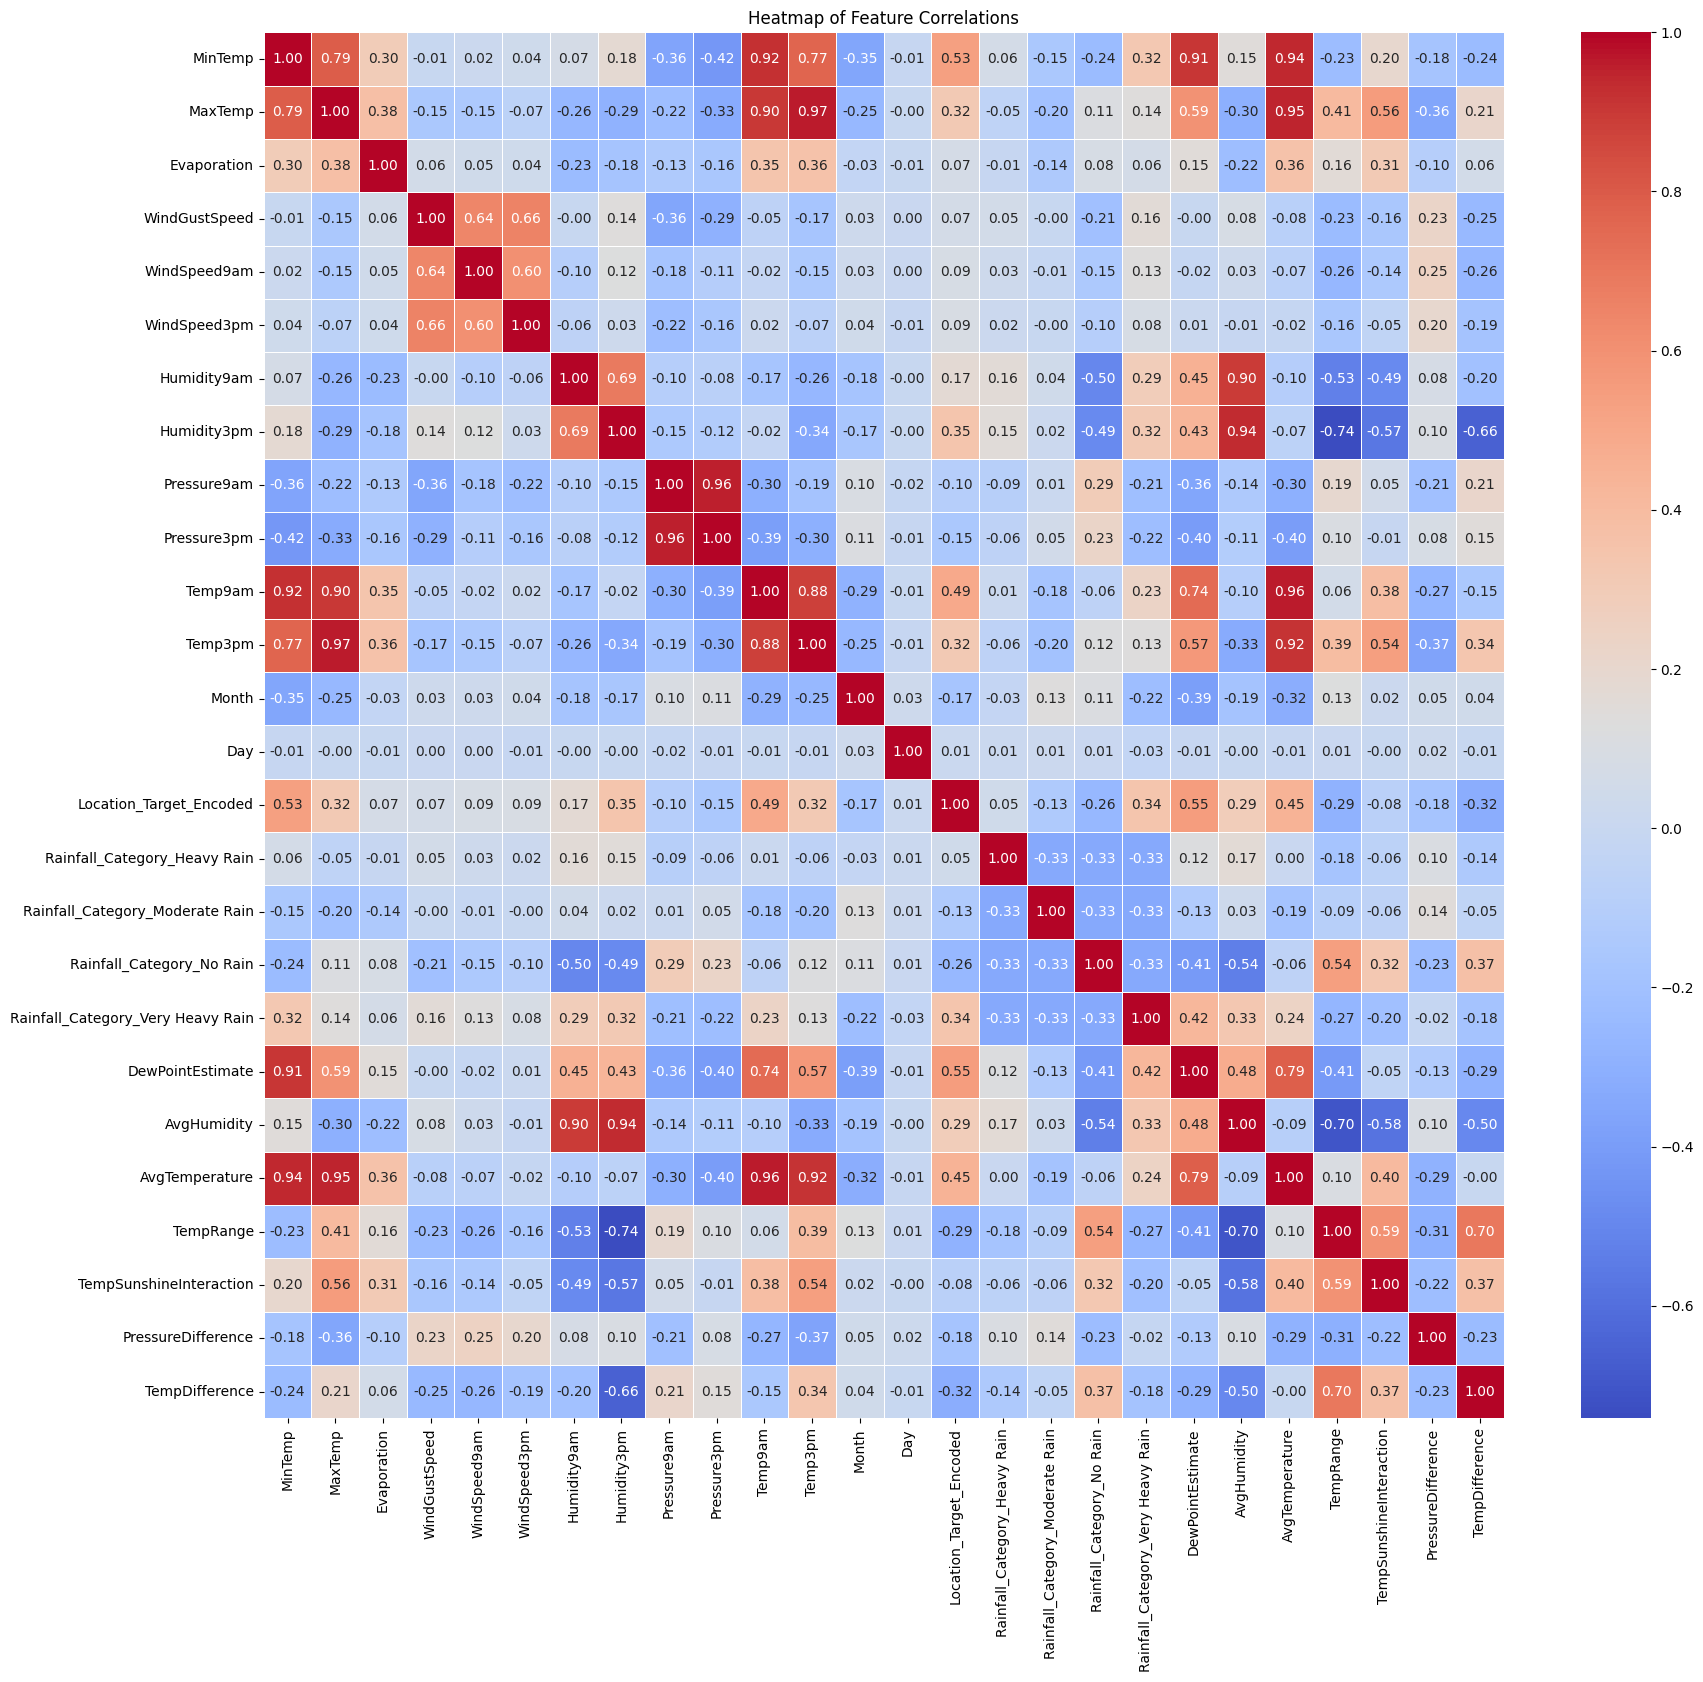

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df_resampled.corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap of Feature Correlations')
plt.show()

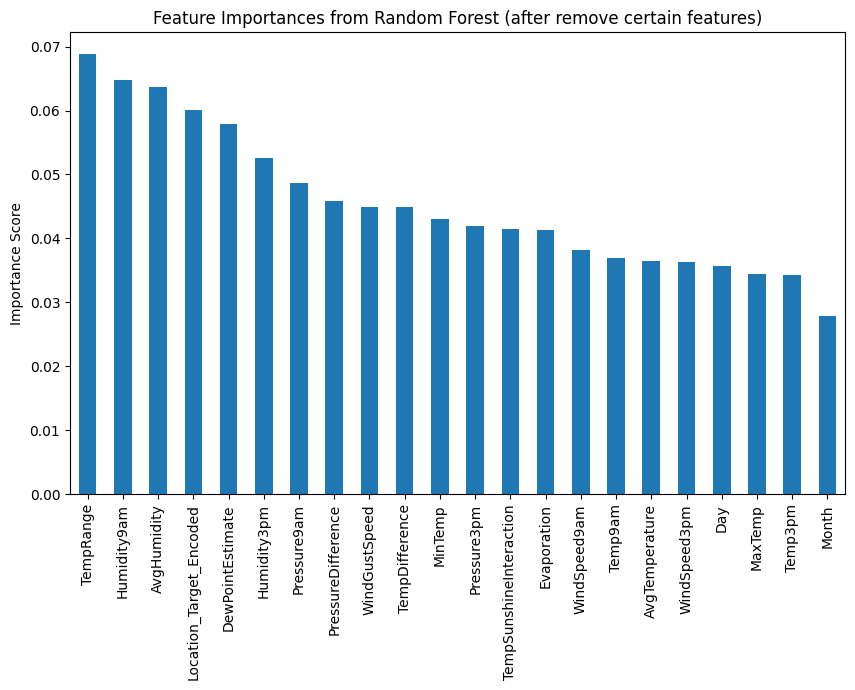

In [ ]:
# Define features and labels for model training
X = df_resampled.drop(columns=one_hot_encoder.get_feature_names_out(['Rainfall_Category']).tolist())

# Define the target variable as the class with the highest probability
y = df_resampled[one_hot_encoder.get_feature_names_out(['Rainfall_Category']).tolist()].idxmax(axis=1)

# Train Random Forest model
rf_model1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model1.fit(X, y)

# Get feature importances
feature_importances = pd.Series(rf_model1.feature_importances_, index=X.columns)

# Sort and plot the feature importances
feature_importances = feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importances from Random Forest (after remove certain features)')
plt.ylabel('Importance Score')
plt.show()




# Save


In [ ]:
#Save the modified DataFrame to a new CSV file
df_resampled.to_csv('4CATSMOTEcleaned_rainfall_data(6).csv', index=False)

#print("The cleaned DataFrame with the 'Rainfall_Category' column has been saved as 'cleaned_rainfall_data5.csv'.")


# 2.0 check


In [ ]:
df = df_resampled.copy()


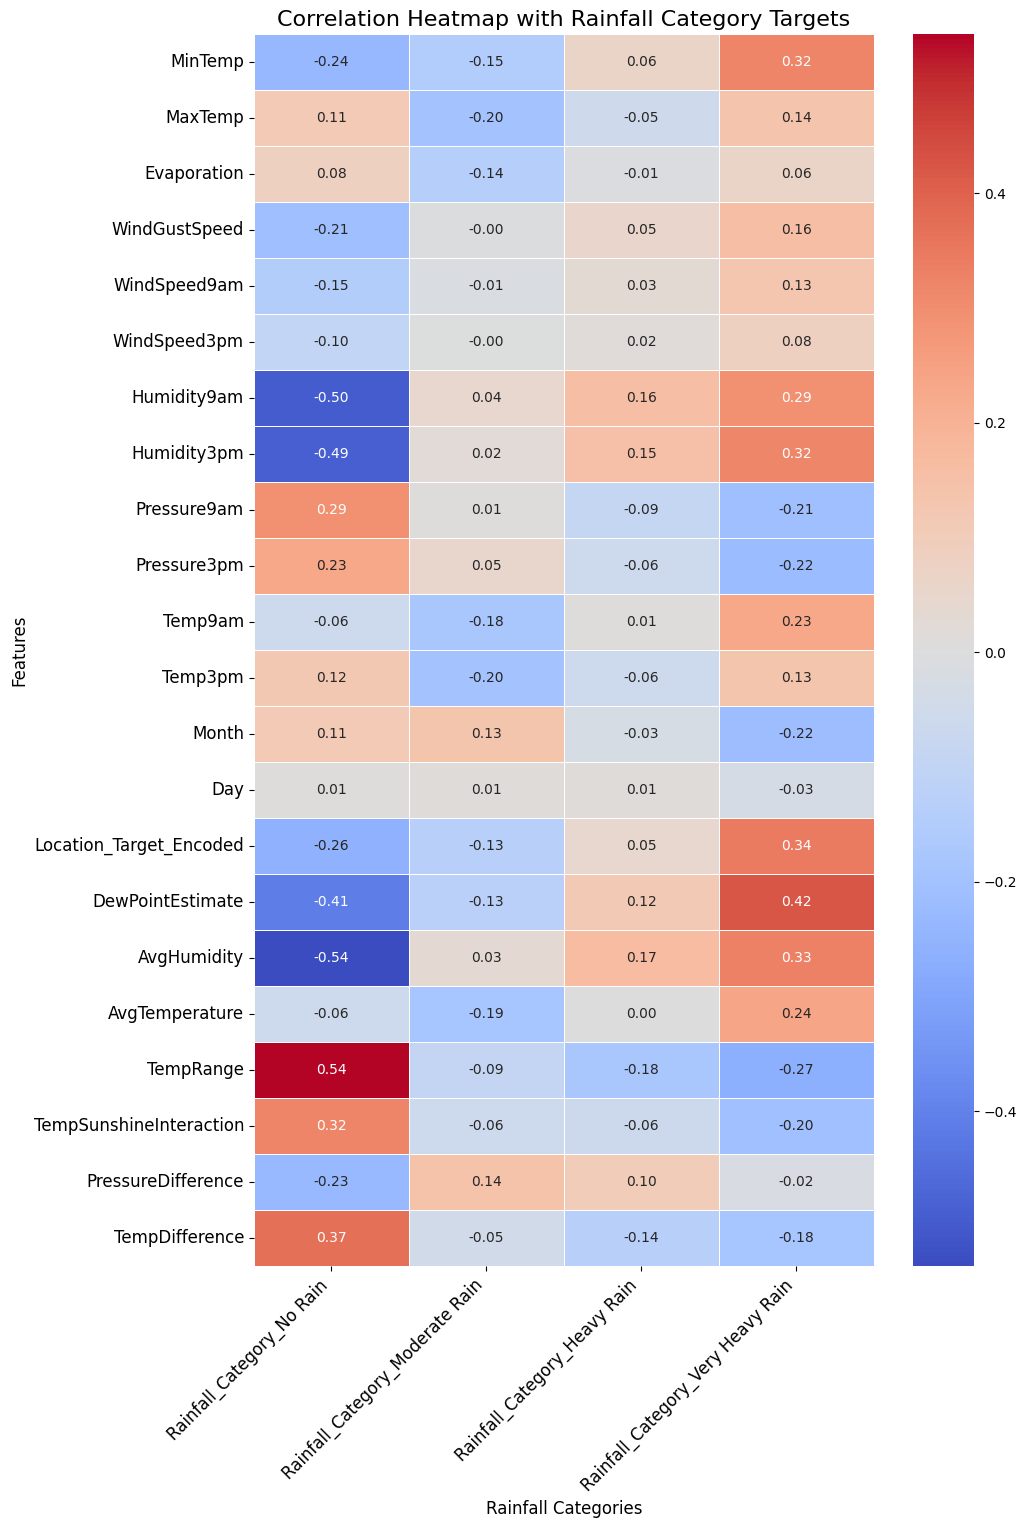

In [ ]:
# Define the target columns
target_columns = [
    'Rainfall_Category_No Rain',
    'Rainfall_Category_Moderate Rain',
    'Rainfall_Category_Heavy Rain',
    'Rainfall_Category_Very Heavy Rain'
]

# Calculate the correlation matrix
correlation = df.corr()

# Extract correlations with each target category
target_correlations = correlation[target_columns].drop(target_columns)

# Plotting the correlation heatmap for the target categories
plt.figure(figsize=(10, 16))
plt.title('Correlation Heatmap with Rainfall Category Targets', fontsize=16)
ax = sns.heatmap(target_correlations, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='white', cbar=True)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.xlabel('Rainfall Categories', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()


In [ ]:
print(df.columns.tolist())

['MinTemp', 'MaxTemp', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Month', 'Day', 'Location_Target_Encoded', 'Rainfall_Category_Heavy Rain', 'Rainfall_Category_Moderate Rain', 'Rainfall_Category_No Rain', 'Rainfall_Category_Very Heavy Rain', 'DewPointEstimate', 'AvgHumidity', 'AvgTemperature', 'TempRange', 'TempSunshineInteraction', 'PressureDifference', 'TempDifference']


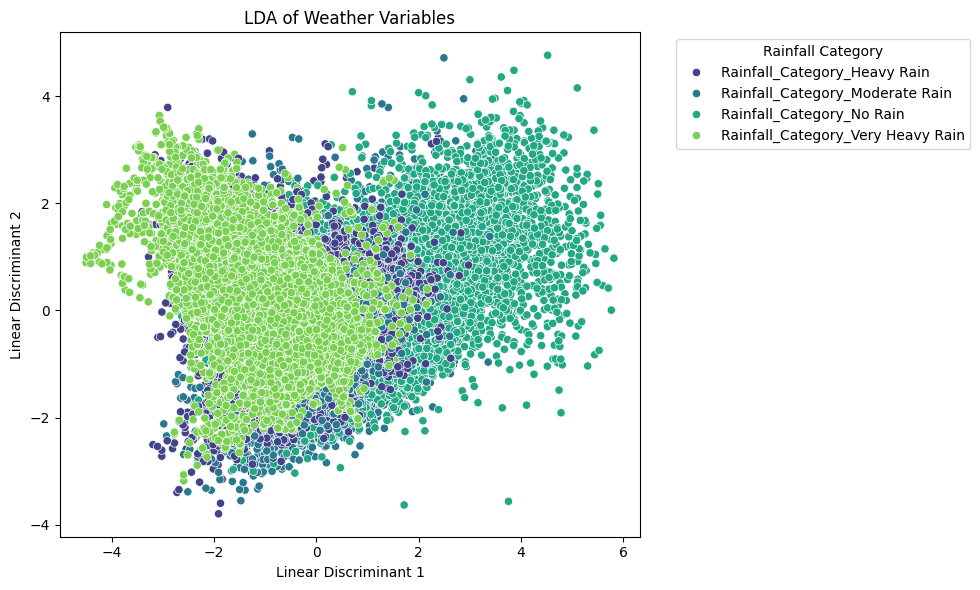

In [ ]:

# Select numerical columns
numerical_data = df[['MinTemp', 'MaxTemp', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Month', 'Day', 'Location_Target_Encoded',
'DewPointEstimate', 'AvgHumidity', 'AvgTemperature', 'TempRange', 'TempSunshineInteraction', 'PressureDifference', 'TempDifference']]


# Check if Rainfall_Category exists as one-hot encoded
if 'Rainfall_Category' not in df.columns:
    df['Rainfall_Category'] = df[['Rainfall_Category_No Rain',
                                  'Rainfall_Category_Moderate Rain',
                                  'Rainfall_Category_Heavy Rain',
                                  'Rainfall_Category_Very Heavy Rain']].idxmax(axis=1)

# Ensure Rainfall_Category matches numerical_data indices
#numerical_data = numerical_data.loc[df.index]  # Align indices

# Perform LDA
lda = LinearDiscriminantAnalysis(n_components=2)
lda_components = lda.fit_transform(numerical_data, df['Rainfall_Category'])

# Create a DataFrame for the LDA results
lda_df = pd.DataFrame(lda_components, columns=['LD1', 'LD2'])
lda_df['Rainfall_Category'] = df['Rainfall_Category'].values

# Scatter plot of LDA components
plt.figure(figsize=(10, 6))
sns.scatterplot(x='LD1', y='LD2', hue='Rainfall_Category', data=lda_df, palette='viridis')
plt.title('LDA of Weather Variables')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.legend(title='Rainfall Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

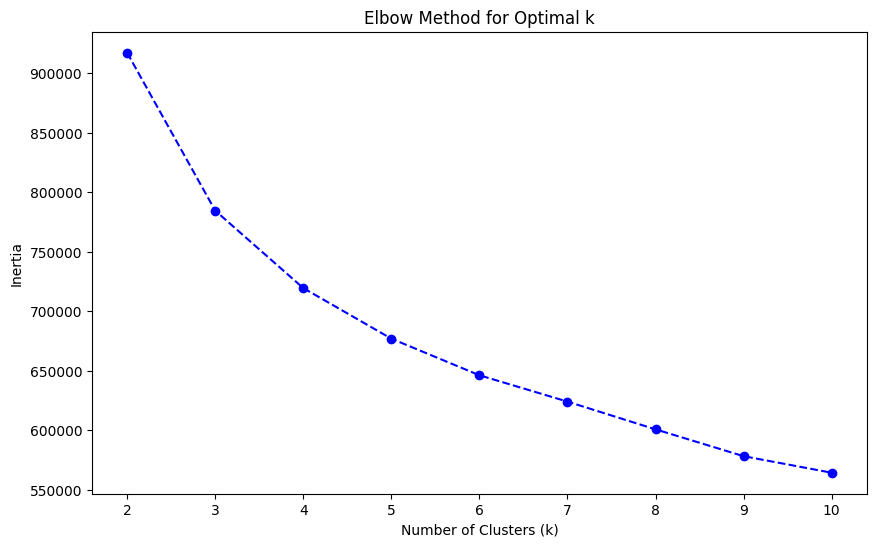

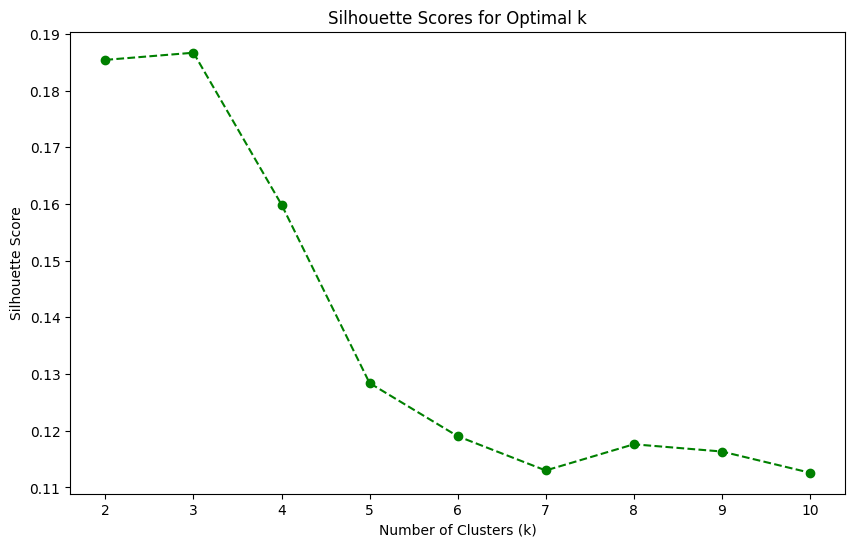

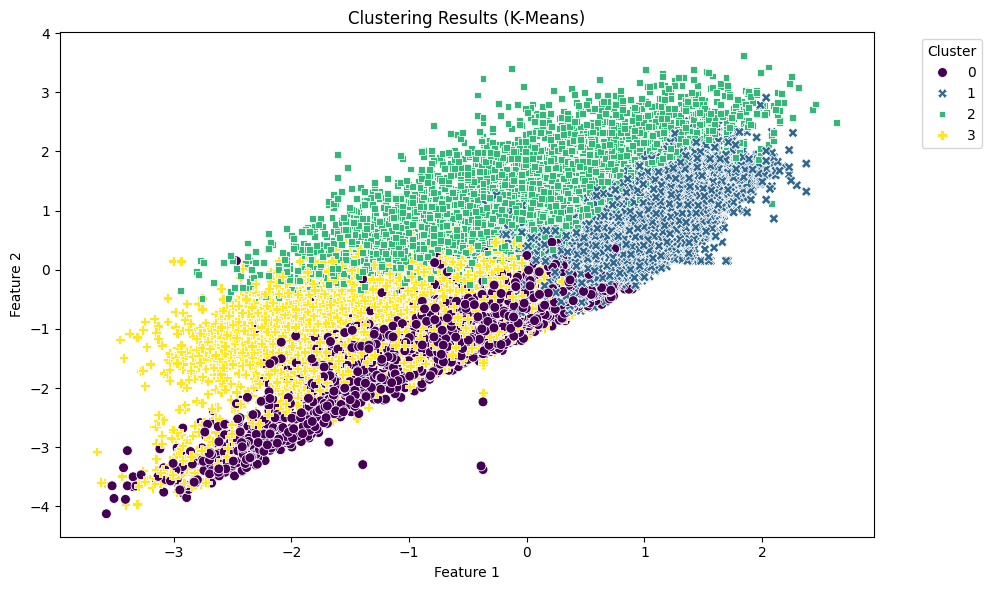

Cluster Centers:
    MinTemp   MaxTemp  Evaporation  WindGustSpeed  WindSpeed9am  WindSpeed3pm  \
0 -0.520427 -0.849812    -0.196373       0.967450      0.854508      0.794813   
1  1.007922  0.725632     0.175068      -0.111633     -0.109517     -0.070235   
2  0.057164  1.001249     0.712754      -0.199502     -0.207383     -0.122129   
3 -0.805264 -0.687154    -0.426717      -0.590189     -0.491280     -0.533397   

   Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  ...     Month  \
0     0.158037     0.347937    -0.465923    -0.253086  ...  0.293549   
1     0.398047     0.484926    -0.396930    -0.474213  ... -0.539790   
2    -1.358854    -1.467185     0.102630    -0.063430  ...  0.245967   
3     0.112132    -0.098464     0.827383     0.827217  ...  0.269695   

        Day  Location_Target_Encoded  DewPointEstimate  AvgHumidity  \
0  0.033903                -0.264150         -0.413772     0.287063   
1 -0.033691                 0.742249          1.082694     0.485529   
2 -

In [ ]:

# Select numerical columns
numerical_data = df[['MinTemp', 'MaxTemp', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Month', 'Day', 'Location_Target_Encoded',
'DewPointEstimate', 'AvgHumidity', 'AvgTemperature', 'TempRange', 'TempSunshineInteraction', 'PressureDifference', 'TempDifference']]

# Step 1: Preprocessing
# Ensure numerical_data is already defined or select your numerical columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_data)

# Step 2: Determine Optimal Number of Clusters
inertia = []
silhouette_scores = []
k_values = range(2, 11)  # Test for clusters between 2 and 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))

# Plot Inertia (Elbow Method)
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--', color='g')
plt.title('Silhouette Scores for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

# Step 3: Fit KMeans with Optimal k (Choose based on elbow or silhouette method)
optimal_k = 4  # Example: Replace with the chosen number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(scaled_data)

# Step 4: Add Cluster Labels to DataFrame
numerical_data['Cluster'] = kmeans.labels_

# Step 5: Visualize Clusters (Using first two principal components if PCA is applied or original features)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=scaled_data[:, 0],  # First feature (e.g., PC1 if PCA is applied)
    y=scaled_data[:, 1],  # Second feature (e.g., PC2 if PCA is applied)
    hue=numerical_data['Cluster'],
    palette='viridis',
    style=numerical_data['Cluster'],
    s=50
)
plt.title('Clustering Results (K-Means)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Step 6: Analyze Cluster Characteristics
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=numerical_data.columns[:-1])
print("Cluster Centers:")
print(cluster_centers)




1. Elbow Method (Inertia Plot)
The elbow point is where the reduction in inertia begins to slow down significantly, indicating diminishing returns for adding more clusters.
In your plot:
The most noticeable "bend" occurs at
𝑘
=
3
k=3.
After
𝑘
=
3
k=3, the slope becomes less steep, indicating smaller gains in reducing inertia.
2. Silhouette Scores
The silhouette score measures how well each data point fits within its cluster (cohesion) and how distinct it is from other clusters (separation).
In your plot:
The silhouette score peaks at
𝑘
=
2
k=2 and remains relatively high at
𝑘
=
3
k=3.
After
𝑘
=
3
k=3, the silhouette scores drop significantly, indicating poorer cluster quality for higher
𝑘
k.
Combining the Results
𝑘
=
3
k=3 appears to be the optimal number of clusters, as:
The elbow method shows a clear bend at
𝑘
=
3
k=3, balancing inertia reduction and simplicity.
The silhouette score is still relatively high at
𝑘
=
3
k=3, indicating good cluster quality.
𝑘
=
2
k=2 has a higher silhouette score but may oversimplify the data, especially if interpretability or domain knowledge suggests more clusters are meaningful.
Recommendation
Choose
𝑘
=
3
k=3 as the optimal number of clusters, balancing both compactness (inertia) and cluster quality (silhouette score).

overlap cluster

In [ ]:
if 'Rainfall_Category' not in df.columns:
    df['Rainfall_Category'] = df[['Rainfall_Category_No Rain',
                                  'Rainfall_Category_Moderate Rain',
                                  'Rainfall_Category_Heavy Rain',
                                  'Rainfall_Category_Very Heavy Rain']].idxmax(axis=1)

Rainfall_Category  Rainfall_Category_Heavy Rain  \
Cluster                                           
0                                          4045   
1                                          4882   
2                                           945   
3                                          3128   

Rainfall_Category  Rainfall_Category_Moderate Rain  Rainfall_Category_No Rain  \
Cluster                                                                         
0                                             4029                       1082   
1                                             3023                       1508   
2                                             1135                       5331   
3                                             4813                       5079   

Rainfall_Category  Rainfall_Category_Very Heavy Rain  
Cluster                                               
0                                               3229  
1                                        

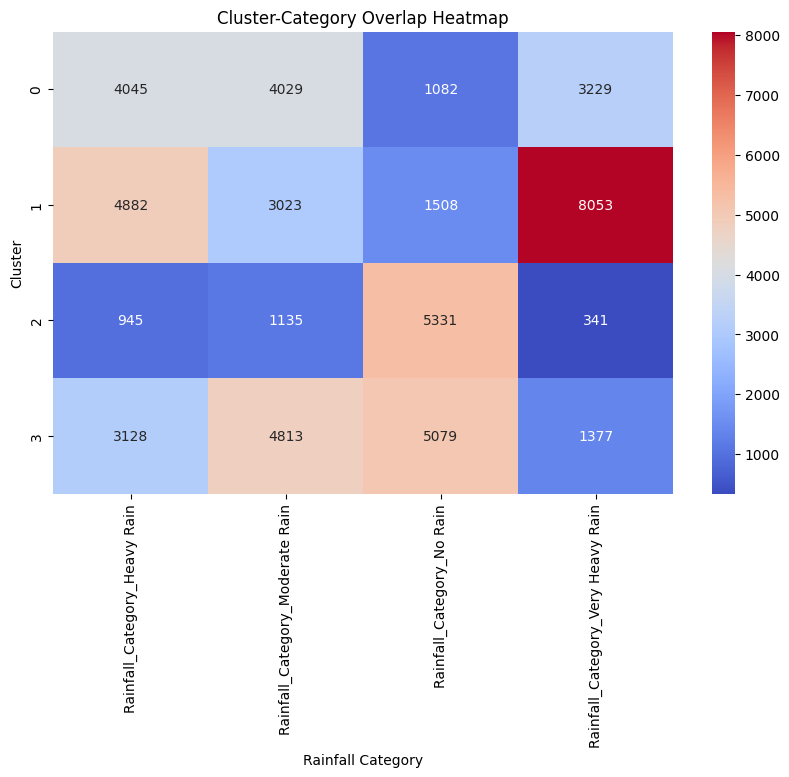

In [ ]:
# Add the cluster labels to the DataFrame if not already present
if 'Cluster' not in df.columns:
    df['Cluster'] = kmeans.labels_

# Cross-tabulation of clusters and rainfall categories
cluster_category_overlap = pd.crosstab(df['Cluster'], df['Rainfall_Category'])
print(cluster_category_overlap)

# Visualize the overlap with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_category_overlap, annot=True, fmt='d', cmap='coolwarm')
plt.title('Cluster-Category Overlap Heatmap')
plt.xlabel('Rainfall Category')
plt.ylabel('Cluster')
plt.show()


Rainfall_Category  Rainfall_Category_Heavy Rain  \
Cluster                                           
0                                      0.326605   
1                                      0.279514   
2                                      0.121904   
3                                      0.217267   

Rainfall_Category  Rainfall_Category_Moderate Rain  Rainfall_Category_No Rain  \
Cluster                                                                         
0                                         0.325313                   0.087364   
1                                         0.173079                   0.086339   
2                                         0.146414                   0.687693   
3                                         0.334306                   0.352782   

Rainfall_Category  Rainfall_Category_Very Heavy Rain  
Cluster                                               
0                                           0.260719  
1                                        

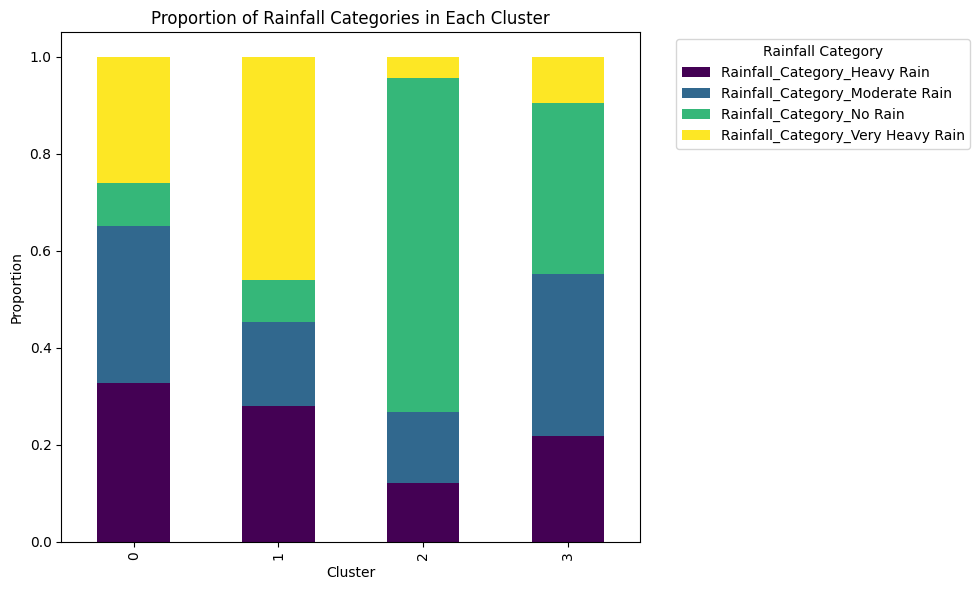

In [ ]:
# Calculate the proportion of each rainfall category within each cluster
cluster_proportions = cluster_category_overlap.div(cluster_category_overlap.sum(axis=1), axis=0)
print(cluster_proportions)

# Visualize proportions with a stacked bar chart
cluster_proportions.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Proportion of Rainfall Categories in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.legend(title='Rainfall Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


                                             MinTemp    MaxTemp  Evaporation  \
Cluster Rainfall_Category                                                      
0       Rainfall_Category_Heavy Rain       11.224769  16.337439     4.393607   
        Rainfall_Category_Moderate Rain    10.183661  15.818907     3.989751   
        Rainfall_Category_No Rain          10.673888  17.179284     4.525139   
        Rainfall_Category_Very Heavy Rain  12.947084  17.962184     4.832931   
1       Rainfall_Category_Heavy Rain       20.542484  26.992130     5.284923   
        Rainfall_Category_Moderate Rain    20.337564  26.941997     4.996161   
        Rainfall_Category_No Rain          20.557150  27.684482     5.619695   
        Rainfall_Category_Very Heavy Rain  20.927128  26.878637     5.293504   
2       Rainfall_Category_Heavy Rain       16.920884  28.747692     6.432845   
        Rainfall_Category_Moderate Rain    16.005347  28.297510     6.114307   
        Rainfall_Category_No Rain       

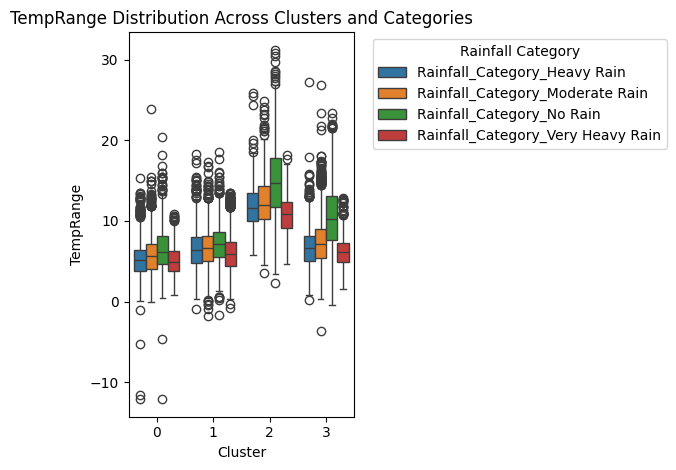

In [ ]:
# Group data by cluster and rainfall category to compute feature statistics
feature_stats = df.groupby(['Cluster', 'Rainfall_Category']).mean()
print(feature_stats)

# Example: Compare 'TempRange' across clusters and categories
sns.boxplot(x='Cluster', y='TempRange', hue='Rainfall_Category', data=df)
plt.title('TempRange Distribution Across Clusters and Categories')
plt.xlabel('Cluster')
plt.ylabel('TempRange')
plt.legend(title='Rainfall Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Cluster Centroids:
 [[-0.52042675 -0.84981208 -0.19637349  0.96745046  0.85450786  0.7948133
   0.15803711  0.347937   -0.4659227  -0.25308589 -0.66369011 -0.87856679
   0.29354859  0.03390283 -0.2641498  -0.41377166  0.28706317 -0.72878142
  -0.5789554  -0.49930255  0.74454224 -0.51136889]
 [ 1.00792215  0.72563156  0.17506784 -0.11163329 -0.10951687 -0.07023467
   0.39804671  0.48492593 -0.39692966 -0.47421325  0.90372473  0.69014506
  -0.53979001 -0.03369142  0.74224914  1.08269409  0.4855289   0.91030406
  -0.35286422 -0.02177382 -0.23401911 -0.35661159]
 [ 0.05716394  1.00124871  0.71275392 -0.19950192 -0.20738259 -0.12212888
  -1.3588535  -1.46718509  0.1026296  -0.06342961  0.50289498  1.02786916
   0.24596679 -0.00849697 -0.55540193 -0.5207294  -1.54327532  0.57448708
   1.51800712  1.32908703 -0.56416156  1.14082875]
 [-0.80526427 -0.68715389 -0.42671664 -0.5901892  -0.49127969 -0.53339686
   0.11213174 -0.09846441  0.82738267  0.82721734 -0.79532039 -0.63367468
   0.26969545 

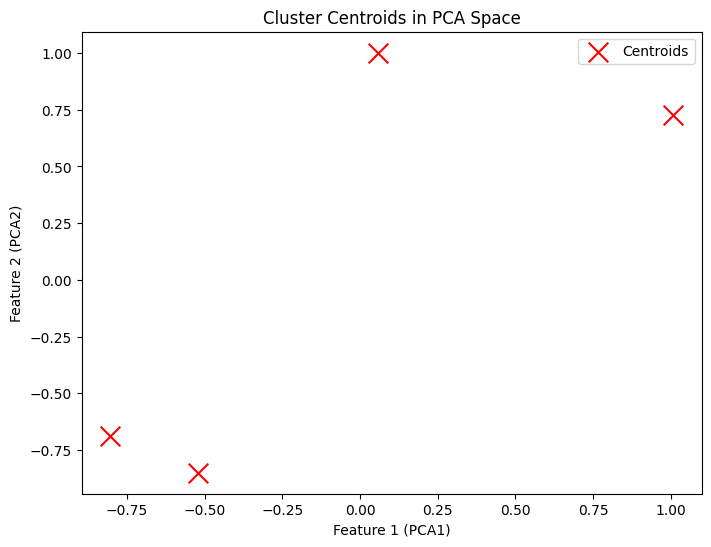

In [ ]:
# Retrieve centroids of clusters
centroids = kmeans.cluster_centers_
print("Cluster Centroids:\n", centroids)

# Plot the centroids in 2D space (e.g., using the first two PCA components)
plt.figure(figsize=(8, 6))
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='x', label='Centroids')
plt.title('Cluster Centroids in PCA Space')
plt.xlabel('Feature 1 (PCA1)')
plt.ylabel('Feature 2 (PCA2)')
plt.legend()
plt.show()


# EDA 2.0

In [ ]:
df = pd.read_csv('/content/1-4CATSMOTEcleaned_rainfall_data(6).csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 26 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   MinTemp                            52000 non-null  float64
 1   MaxTemp                            52000 non-null  float64
 2   Evaporation                        52000 non-null  float64
 3   WindGustSpeed                      52000 non-null  float64
 4   WindSpeed9am                       52000 non-null  float64
 5   WindSpeed3pm                       52000 non-null  float64
 6   Humidity9am                        52000 non-null  float64
 7   Humidity3pm                        52000 non-null  float64
 8   Pressure9am                        52000 non-null  float64
 9   Pressure3pm                        52000 non-null  float64
 10  Temp9am                            52000 non-null  float64
 11  Temp3pm                            52000 non-null  flo

In [ ]:
# Combine one-hot encoded columns back into a single 'Rainfall_Category' column
df['Rainfall_Category'] = df[['Rainfall_Category_Heavy Rain',
                              'Rainfall_Category_Moderate Rain',
                              'Rainfall_Category_No Rain',
                              'Rainfall_Category_Very Heavy Rain']].idxmax(axis=1)

# Remove the 'Rainfall_Category_' prefix
df['Rainfall_Category'] = df['Rainfall_Category'].str.replace('Rainfall_Category_', '')

# Verify the result
print(df['Rainfall_Category'].value_counts())
# Example: Check the 'Rainfall_Category_Heavy Rain' column
print(df['Rainfall_Category_Heavy Rain'].head())
print(df.columns)

Rainfall_Category
Heavy Rain         13000
Moderate Rain      13000
No Rain            13000
Very Heavy Rain    13000
Name: count, dtype: int64
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: Rainfall_Category_Heavy Rain, dtype: float64
Index(['MinTemp', 'MaxTemp', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Temp9am', 'Temp3pm', 'Month', 'Day',
       'Location_Target_Encoded', 'Rainfall_Category_Heavy Rain',
       'Rainfall_Category_Moderate Rain', 'Rainfall_Category_No Rain',
       'Rainfall_Category_Very Heavy Rain', 'DewPointEstimate', 'AvgHumidity',
       'AvgTemperature', 'TempRange', 'TempSunshineInteraction',
       'PressureDifference', 'TempDifference', 'Rainfall_Category'],
      dtype='object')


Pair Plot (Scatterplot Matrix)
Purpose: Examine pairwise relationships between features and their correlation with rainfall categories.

Benefit: Identify non-linear relationships and patterns among features.

KeyboardInterrupt: 

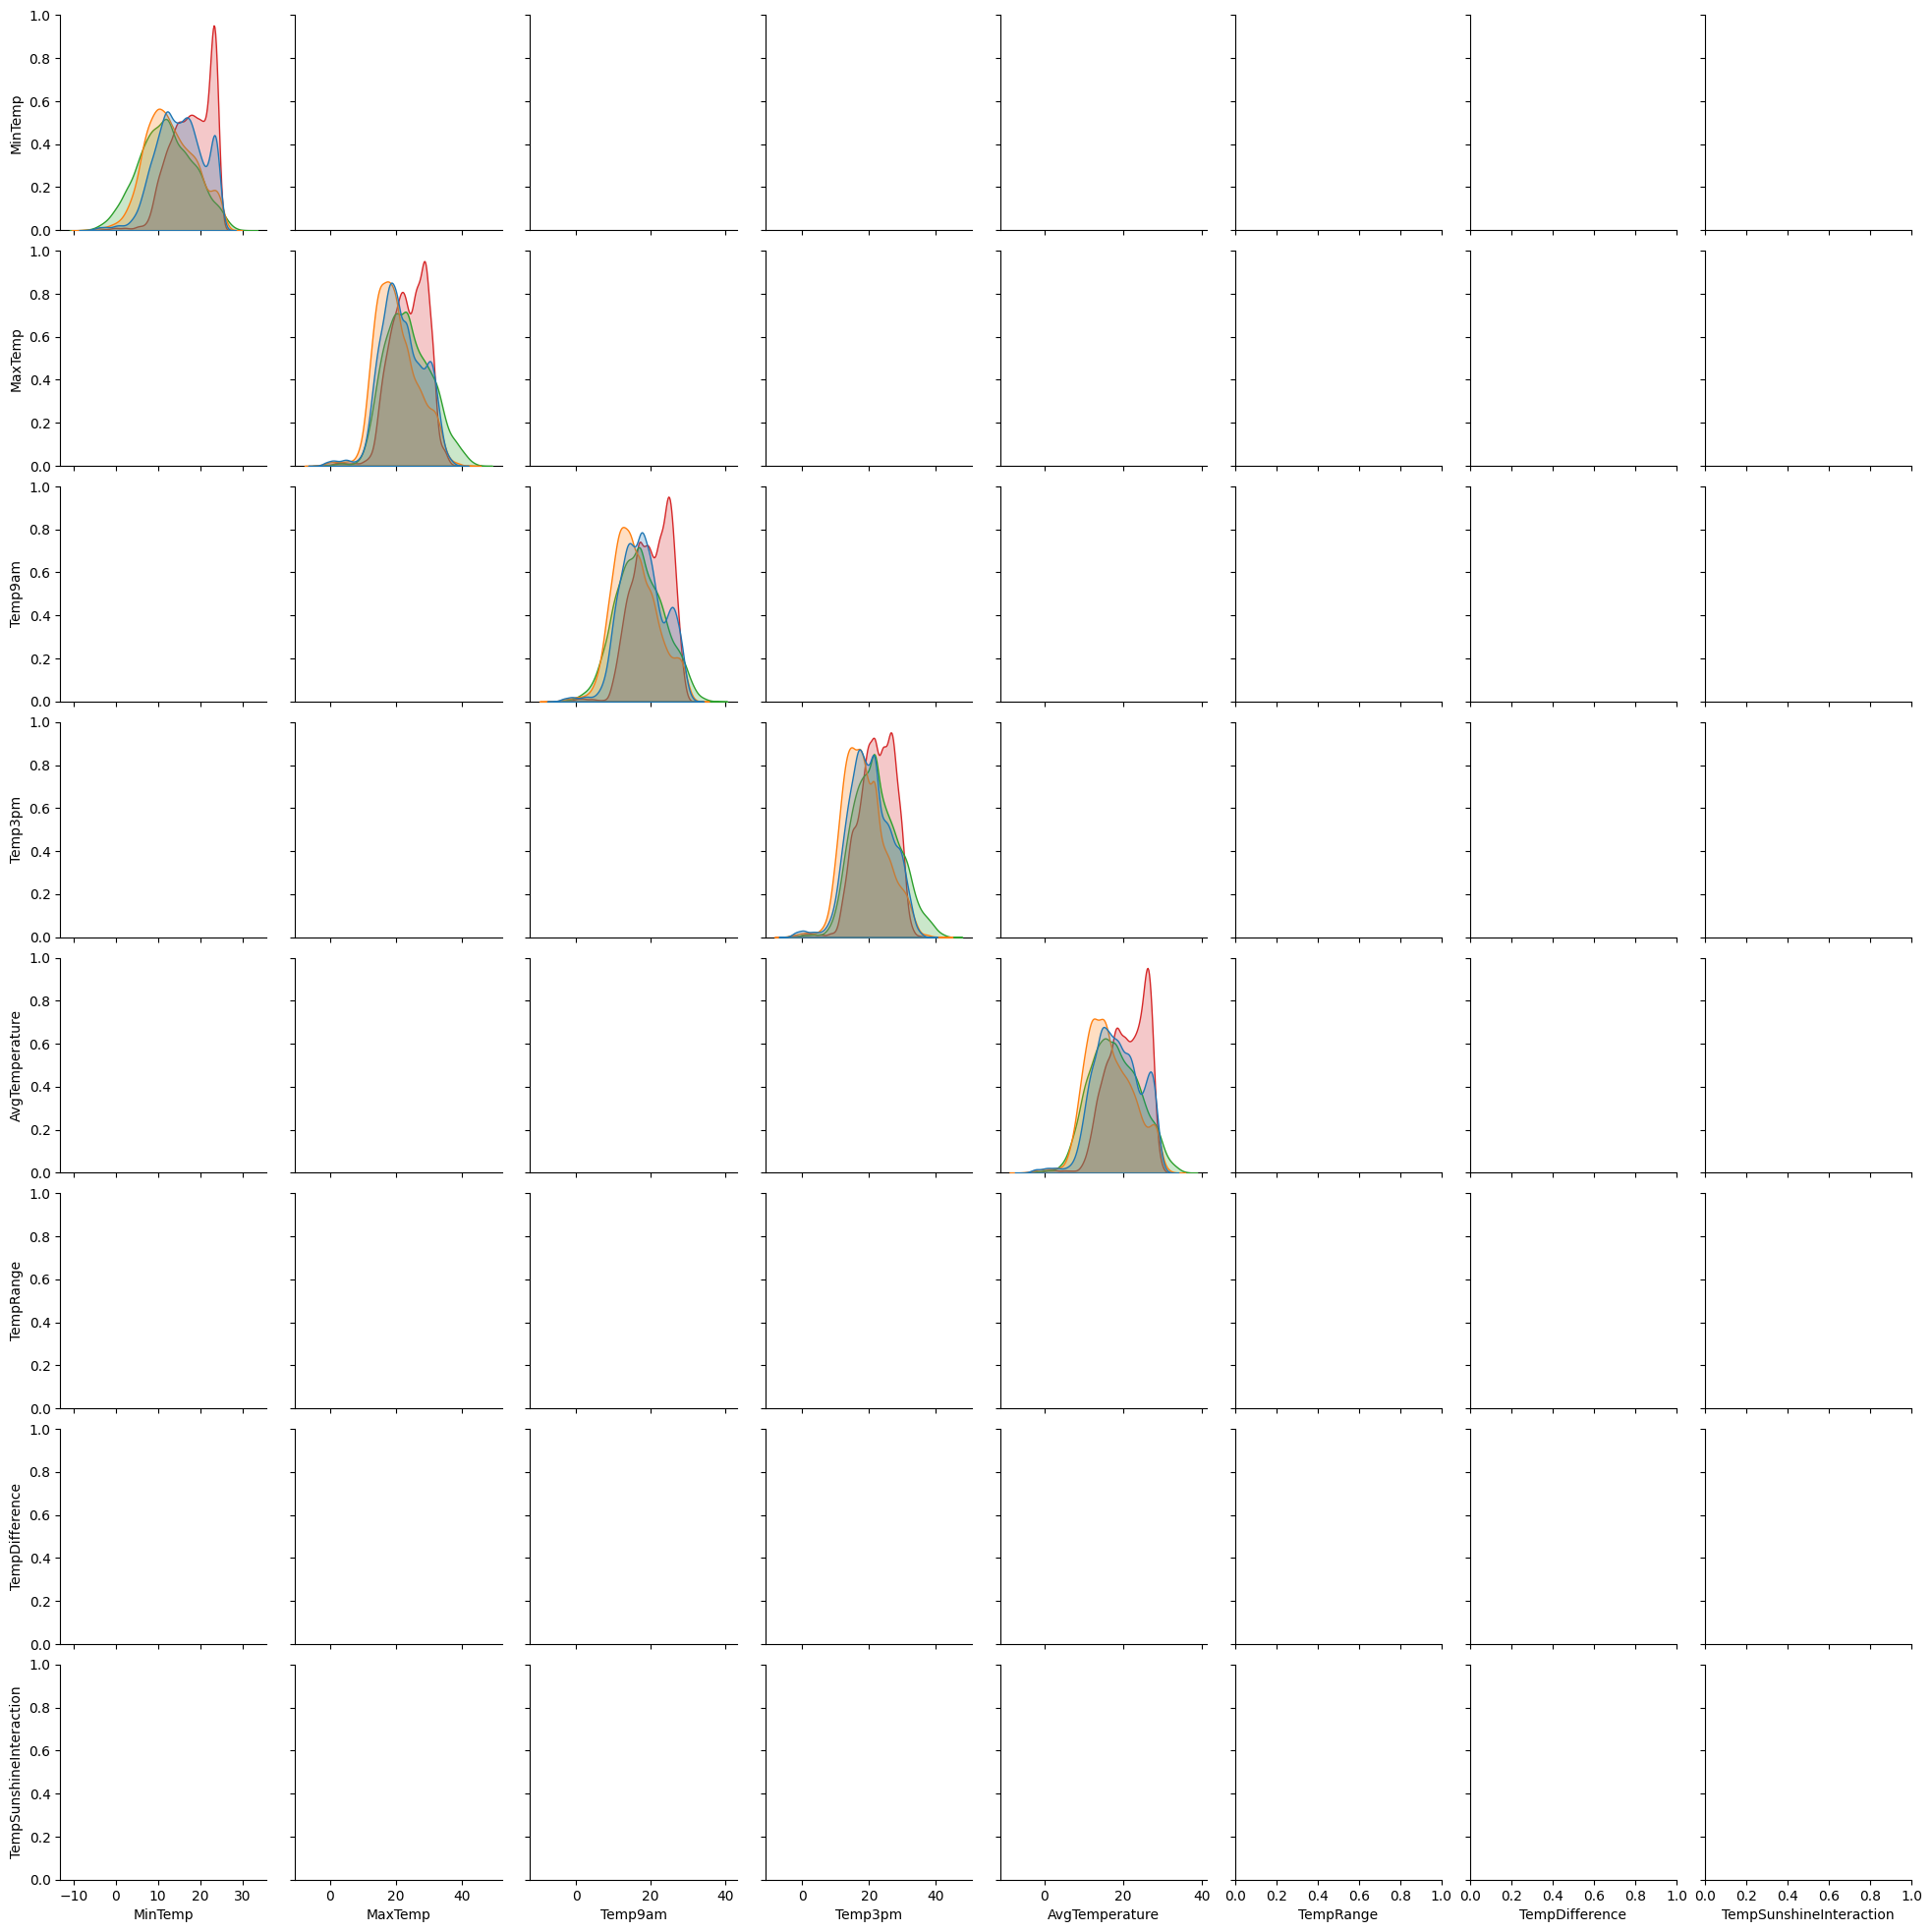

In [ ]:

sns.pairplot(df, hue='Rainfall_Category', vars=['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm','AvgTemperature', 'TempRange', 'TempDifference', 'TempSunshineInteraction'])
plt.show()



In [ ]:
sns.pairplot(df, hue='Rainfall_Category', vars=['Evaporation', 'DewPointEstimate','WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm'])
plt.show()

In [ ]:
sns.pairplot(df, hue='Rainfall_Category', vars=['Humidity9am', 'Humidity3pm', 'AvgHumidity','Pressure9am', 'Pressure3pm', 'PressureDifference'])
plt.show()

# Feature Importance using Tree-based Models
Purpose: Rank the importance of meteorological features for predicting rainfall using machine learning models like Random Forest or XGBoost.
Benefit: Provides an interpretable ranking of features contributing most to rainfall prediction.

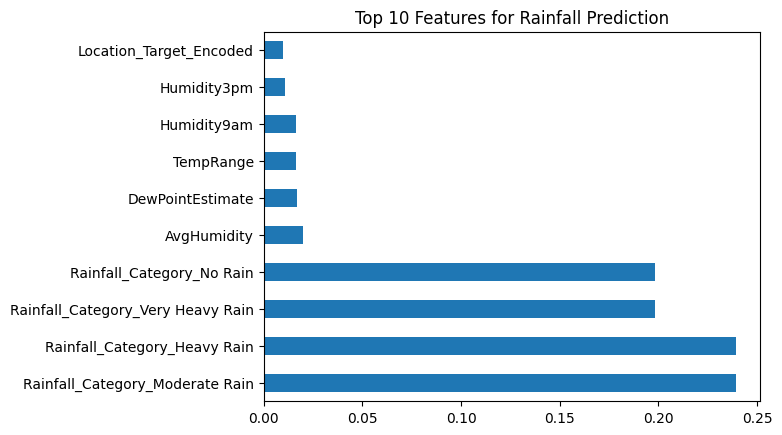

In [ ]:

# Train Random Forest
X = df.drop('Rainfall_Category', axis=1)
y = df['Rainfall_Category']
model = RandomForestClassifier()
model.fit(X, y)

# Plot feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', title='Top 10 Features for Rainfall Prediction')
plt.show()


#  Mutual Information Scores
Purpose: Measure the dependency between each meteorological feature and the target rainfall category.
Method: Use mutual_info_classif from sklearn to compute mutual information scores.
Benefit: Rank features based on their information contribution to predicting rainfall.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   MinTemp                            52000 non-null  float64
 1   MaxTemp                            52000 non-null  float64
 2   Evaporation                        52000 non-null  float64
 3   WindGustSpeed                      52000 non-null  float64
 4   WindSpeed9am                       52000 non-null  float64
 5   WindSpeed3pm                       52000 non-null  float64
 6   Humidity9am                        52000 non-null  float64
 7   Humidity3pm                        52000 non-null  float64
 8   Pressure9am                        52000 non-null  float64
 9   Pressure3pm                        52000 non-null  float64
 10  Temp9am                            52000 non-null  float64
 11  Temp3pm                            52000 non-null  flo

In [ ]:


# Specify the columns to drop
columns_to_drop = ['Rainfall_Category_Heavy Rain', 'Rainfall_Category_Moderate Rain', 'Rainfall_Category_No Rain', 'Rainfall_Category_Very Heavy Rain']

# Check if the columns exist before dropping them
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if columns_to_drop:
    df = df.drop(columns=columns_to_drop)
    print(f"Columns {columns_to_drop} dropped successfully.")
else:
    print("Columns to drop not found in the DataFrame.")

print(df.head())

Columns ['Rainfall_Category_Heavy Rain', 'Rainfall_Category_Moderate Rain', 'Rainfall_Category_No Rain', 'Rainfall_Category_Very Heavy Rain'] dropped successfully.
   MinTemp  MaxTemp  Evaporation  WindGustSpeed  WindSpeed9am  WindSpeed3pm  \
0     12.9     15.8          4.8           70.0          19.0          15.0   
1      8.6     12.9          4.8           63.0          26.0          31.0   
2      9.3     16.8          4.8           56.0          26.0          30.0   
3     18.3     28.3          4.8           61.0           0.0          46.0   
4     18.8     30.3          4.8           39.0           9.0           7.0   

   Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  ...  Day  \
0         83.0         89.0       1004.8       1000.9  ...   25   
1         77.0         62.0       1004.0       1003.3  ...   26   
2         82.0         54.0        997.8       1003.8  ...   23   
3         98.0         67.0       1003.7       1003.5  ...   22   
4         87.0         48.

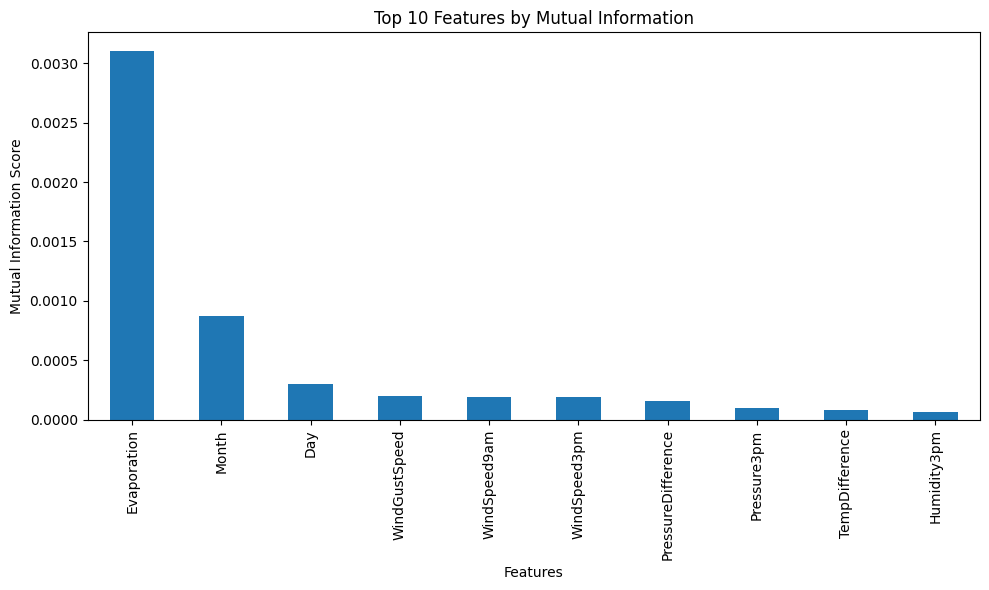

In [ ]:
# Drop target columns from features X
target_columns = ['Rainfall_Category']
X = df.drop(columns=target_columns)

# Combine one-hot encoded target into a single target column
y_combined = df[target_columns].idxmax(axis=1)  # Combine to single column based on max value

# Encode target labels as integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_combined)

# Compute mutual information scores
mi = mutual_info_classif(X, y_encoded, random_state=42)
mi_scores = pd.Series(mi, index=X.columns)

# Plot the top 10 features by mutual information
plt.figure(figsize=(10, 6))
mi_scores.nlargest(10).plot(kind='bar', title='Top 10 Features by Mutual Information')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.tight_layout()
plt.show()


# LDA

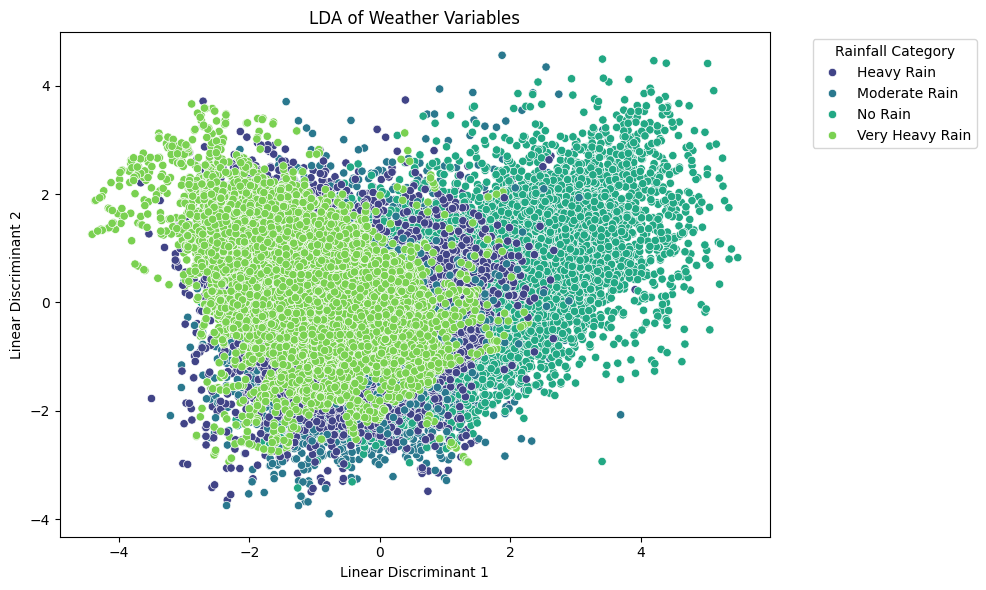

In [ ]:

# Select numerical columns
numerical_data = df[['MinTemp', 'MaxTemp', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                     'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'DewPointEstimate',
                     'AvgHumidity','AvgTemperature', 'TempRange', 'TempSunshineInteraction','PressureDifference', 'TempDifference']]

# Check if Rainfall_Category exists as one-hot encoded
if 'Rainfall_Category' not in df.columns:
    df['Rainfall_Category'] = df[['Rainfall_Category_No Rain',
                                  'Rainfall_Category_Moderate Rain',
                                  'Rainfall_Category_Heavy Rain',
                                  'Rainfall_Category_Very Heavy Rain']].idxmax(axis=1)

# Ensure Rainfall_Category matches numerical_data indices
#numerical_data = numerical_data.loc[df.index]  # Align indices

# Perform LDA
lda = LinearDiscriminantAnalysis(n_components=2)
lda_components = lda.fit_transform(numerical_data, df['Rainfall_Category'])

# Create a DataFrame for the LDA results
lda_df = pd.DataFrame(lda_components, columns=['LD1', 'LD2'])
lda_df['Rainfall_Category'] = df['Rainfall_Category'].values

# Scatter plot of LDA components
plt.figure(figsize=(10, 6))
sns.scatterplot(x='LD1', y='LD2', hue='Rainfall_Category', data=lda_df, palette='viridis')
plt.title('LDA of Weather Variables')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.legend(title='Rainfall Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()